# Intelligent Customer Review Analysis — McDonald's Reviews

Objectif (pour le moment) :
- Exploration et préparation des données
- Analyse statistique des données
- Visualisation des distributions
- Gestion de la normalisation / standardisation / données manquantes
- Graphe comparatif : avant vs après prétraitement
- Séparation en jeux train / validation / test

Le CSV contient : `reviewer_id`, `store_name`, `category`, `store_address`, `latitude`, `longitude`, `rating_count`, `review_time`, `review`, `rating`.

## 1) Import & configuration
Chargement des librairies et réglages d'affichage (pandas / seaborn).

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

# Configuration de la colonne target pour les modèles ML
TARGET_COL = 'sentiment'  # peut être 'rating' ou 'sentiment'

## 2) Chargement des données
Lecture du fichier CSV et premier aperçu (shape + head).

In [2]:
DATA_PATH = Path('McDonald_s_Reviews.csv')
assert DATA_PATH.exists(), f'CSV introuvable: {DATA_PATH.resolve()}'

df_raw = pd.read_csv(DATA_PATH)
print('Shape:', df_raw.shape)
display(df_raw.head(5))

Shape: (33396, 10)


,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was �����������...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star


## 3) Exploration rapide
Types de colonnes, valeurs manquantes, et doublons.

In [3]:
display(df_raw.info())

missing = (df_raw.isna().mean() * 100).sort_values(ascending=False)
display(missing.to_frame('missing_%').head(20))

dup_count = df_raw.duplicated().sum()
print('Duplicates:', dup_count)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reviewer_id    33396 non-null  int64  
 1   store_name     33396 non-null  object 
 2   category       33396 non-null  object 
 3   store_address  33396 non-null  object 
 4   latitude       32736 non-null  float64
 5   longitude      32736 non-null  float64
 6   rating_count   33396 non-null  object 
 7   review_time    33396 non-null  object 
 8   review         33396 non-null  object 
 9   rating         33396 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 2.5+ MB


None

,missing_%
latitude,1.976285
longitude,1.976285
store_name,0.000000
reviewer_id,0.000000
store_address,0.000000
category,0.000000
rating_count,0.000000
review_time,0.000000
review,0.000000
rating,0.000000


Duplicates: 0


## 4) Analyse statistique
Statistiques descriptives et agrégats.

In [4]:
print('='*80)
print('  ANALYSE STATISTIQUE APPROFONDIE')
print('='*80)

# Créer une copie pour le parsing temporaire
df_analysis = df_raw.copy()

# Parser temporairement le rating pour l'analyse
def parse_rating_temp(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    m = re.search(r'(\d+)', s)
    return float(m.group(1)) if m else np.nan

# Parser temporairement rating_count pour l'analyse
def parse_rating_count_temp(x):
    if pd.isna(x):
        return np.nan
    s = str(x).replace(',', '').strip()
    m = re.search(r'(\d+)', s)
    return float(m.group(1)) if m else np.nan

if 'rating' in df_analysis.columns:
    df_analysis['rating'] = df_analysis['rating'].apply(parse_rating_temp)

if 'rating_count' in df_analysis.columns:
    df_analysis['rating_count'] = df_analysis['rating_count'].apply(parse_rating_count_temp)

# ============================================================================
# 1) ANALYSE GLOBALE DES RATINGS
# ============================================================================
if 'rating' in df_analysis.columns:
    print('\n1️⃣  STATISTIQUES GLOBALES DES RATINGS')
    print('-'*80)
    
    rating_stats = df_analysis['rating'].describe()
    display(rating_stats)
    
    # Interprétations
    mean_rating = rating_stats['mean']
    median_rating = rating_stats['50%']
    std_rating = rating_stats['std']
    
    print(f'\n📊 Interprétation:')
    print(f'   • Moyenne: {mean_rating:.2f} / 5.0')
    print(f'   • Médiane: {median_rating:.2f} / 5.0')
    print(f'   • Écart-type: {std_rating:.2f}')
    
    if mean_rating > 4.0:
        print(f'   → Satisfaction globale ÉLEVÉE (moyenne > 4.0)')
    elif mean_rating > 3.0:
        print(f'   → Satisfaction globale MODÉRÉE (3.0 < moyenne ≤ 4.0)')
    else:
        print(f'   → Satisfaction globale FAIBLE (moyenne ≤ 3.0)')
    
    if abs(mean_rating - median_rating) < 0.1:
        print(f'   → Distribution relativement SYMÉTRIQUE (moyenne ≈ médiane)')
    elif mean_rating < median_rating:
        print(f'   → Distribution NÉGATIVEMENT asymétrique (tirée vers le bas)')
    else:
        print(f'   → Distribution POSITIVEMENT asymétrique (tirée vers le haut)')
    
    if std_rating < 0.5:
        print(f'   → Variabilité FAIBLE: les avis sont très homogènes')
    elif std_rating < 1.0:
        print(f'   → Variabilité MODÉRÉE: consensus relatif entre les clients')
    else:
        print(f'   → Variabilité ÉLEVÉE: opinions très divergentes')


# ============================================================================
# 2) ANALYSE PAR SENTIMENT (distribution)
# ============================================================================
if 'sentiment' in df_analysis.columns:
    print('\n\n2️⃣  DISTRIBUTION PAR SENTIMENT')
    print('-'*80)
    
    sentiment_counts = df_analysis['sentiment'].value_counts(dropna=False)
    sentiment_pct = df_analysis['sentiment'].value_counts(normalize=True, dropna=False) * 100
    
    sentiment_df = pd.DataFrame({
        'Nombre': sentiment_counts,
        'Pourcentage': sentiment_pct.apply(lambda x: f'{x:.2f}%')
    })
    display(sentiment_df)
    
    print(f'\n📊 Interprétation:')
    if 'positif' in sentiment_counts:
        pct_pos = sentiment_pct.get('positif', 0)
        pct_neg = sentiment_pct.get('négatif', 0)
        pct_neu = sentiment_pct.get('neutre', 0)
        
        print(f'   • Positif: {pct_pos:.1f}% des avis')
        print(f'   • Neutre: {pct_neu:.1f}% des avis')
        print(f'   • Négatif: {pct_neg:.1f}% des avis')
        
        # Ratio positif/négatif
        if pct_neg > 0:
            ratio = pct_pos / pct_neg
            print(f'   • Ratio Positif/Négatif: {ratio:.2f}:1')
            
            if ratio > 5:
                print(f'   → Image de marque TRÈS POSITIVE (ratio > 5:1)')
            elif ratio > 2:
                print(f'   → Image de marque POSITIVE (ratio > 2:1)')
            elif ratio > 1:
                print(f'   → Image de marque LÉGÈREMENT POSITIVE')
            else:
                print(f'   → Image de marque PROBLÉMATIQUE (plus de négatif que de positif)')

# ============================================================================
# 2) TOP & FLOP MAGASINS
# ============================================================================
if {'store_address', 'rating'}.issubset(df_analysis.columns):
    print('\n\n2️⃣  TOP & FLOP MAGASINS')
    print('-'*80)
    
    store_stats = df_analysis.groupby('store_address', dropna=False)['rating'].agg([
        ('Nb_avis', 'count'),
        ('Moyenne', 'mean')
    ]).round(2)
    
    # Filtrer les magasins avec au moins 5 avis pour avoir des stats fiables
    store_stats_filtered = store_stats[store_stats['Nb_avis'] >= 5]
    
    print(f'\n📈 TOP 5 MAGASINS (meilleure moyenne, min 5 avis):')
    top5 = store_stats_filtered.sort_values('Moyenne', ascending=False).head(5)
    display(top5)
    
    print(f'\n📉 FLOP 5 MAGASINS (moins bonne moyenne, min 5 avis):')
    flop5 = store_stats_filtered.sort_values('Moyenne', ascending=True).head(5)
    display(flop5)
    
    print(f'\n📊 Interprétation:')
    best_store_avg = top5['Moyenne'].iloc[0]
    worst_store_avg = flop5['Moyenne'].iloc[0]
    gap_stores = best_store_avg - worst_store_avg
    
    print(f'   • Écart meilleur/pire magasin: {gap_stores:.2f} points')
    
    if gap_stores > 2.0:
        print(f'   → Disparités TRÈS IMPORTANTES entre magasins (écart > 2.0)')
        print(f'   → Problème de standardisation de la qualité de service')
    elif gap_stores > 1.0:
        print(f'   → Disparités MODÉRÉES entre magasins (1.0 < écart ≤ 2.0)')
    else:
        print(f'   → Qualité HOMOGÈNE entre magasins (écart ≤ 1.0)')


# ============================================================================
# 3) ANALYSE DE LA LONGUEUR DES REVIEWS
# ============================================================================
if 'review_length' in df_analysis.columns and 'rating' in df_analysis.columns:
    print('\n\n3️⃣  RELATION LONGUEUR DES REVIEWS vs RATING')
    print('-'*80)
    
    # Grouper par rating et calculer la longueur moyenne
    length_by_rating = df_analysis.groupby('rating')['review_length'].agg([
        ('Nb_reviews', 'count'),
        ('Longueur_moyenne', 'mean'),
        ('Longueur_médiane', 'median')
    ]).round(0)
    
    display(length_by_rating)
    
    # Corrélation
    corr_length_rating = df_analysis[['review_length', 'rating']].corr().loc['review_length', 'rating']
    
    print(f'\n📊 Interprétation:')
    print(f'   • Corrélation longueur/rating: {corr_length_rating:.3f}')
    
    if abs(corr_length_rating) < 0.1:
        print(f'   → Corrélation NÉGLIGEABLE: la longueur n\'influence pas le rating')
    elif corr_length_rating > 0.3:
        print(f'   → Corrélation POSITIVE: les avis longs sont plus positifs')
    elif corr_length_rating < -0.3:
        print(f'   → Corrélation NÉGATIVE: les avis longs sont plus négatifs')
    else:
        print(f'   → Corrélation FAIBLE')
    
    # Comparer extrêmes
    len_rating_1 = length_by_rating.loc[1.0, 'Longueur_moyenne'] if 1.0 in length_by_rating.index else 0
    len_rating_5 = length_by_rating.loc[5.0, 'Longueur_moyenne'] if 5.0 in length_by_rating.index else 0
    
    if len_rating_1 > 0 and len_rating_5 > 0:
        if len_rating_1 > len_rating_5:
            pct_diff = ((len_rating_1 - len_rating_5) / len_rating_5) * 100
            print(f'   • Les avis 1★ sont {pct_diff:.0f}% plus longs que les avis 5★')
            print(f'   → Les clients mécontents s\'expriment plus longuement')
        else:
            pct_diff = ((len_rating_5 - len_rating_1) / len_rating_1) * 100
            print(f'   • Les avis 5★ sont {pct_diff:.0f}% plus longs que les avis 1★')
            print(f'   → Les clients satisfaits s\'expriment plus longuement')


# ============================================================================
# 4) ANALYSE TEMPORELLE (ancienneté des reviews)
# ============================================================================
if 'review_time_days' in df_analysis.columns and 'rating' in df_analysis.columns:
    print('\n\n4️⃣  ÉVOLUTION TEMPORELLE DES RATINGS')
    print('-'*80)
    
    # Créer des tranches temporelles
    df_analysis['tranche_temps'] = pd.cut(df_analysis['review_time_days'], 
                                   bins=[0, 30, 90, 180, 365, float('inf')],
                                   labels=['0-30j', '1-3 mois', '3-6 mois', '6-12 mois', '>1 an'])
    
    temporal_stats = df_analysis.groupby('tranche_temps', dropna=False)['rating'].agg([
        ('Nb_avis', 'count'),
        ('Moyenne', 'mean'),
        ('Médiane', 'median')
    ]).round(2)
    
    display(temporal_stats)
    
    print(f'\n📊 Interprétation:')
    
    # Comparer récent vs ancien
    recent_avg = temporal_stats.loc['0-30j', 'Moyenne'] if '0-30j' in temporal_stats.index else None
    old_avg = temporal_stats.loc['>1 an', 'Moyenne'] if '>1 an' in temporal_stats.index else None
    
    if recent_avg and old_avg:
        diff = recent_avg - old_avg
        print(f'   • Moyenne récente (0-30j): {recent_avg:.2f}')
        print(f'   • Moyenne ancienne (>1 an): {old_avg:.2f}')
        print(f'   • Différence: {diff:+.2f} points')
        
        if diff > 0.3:
            print(f'   → AMÉLIORATION de la satisfaction dans le temps')
        elif diff < -0.3:
            print(f'   → DÉGRADATION de la satisfaction dans le temps')
        else:
            print(f'   → Satisfaction STABLE dans le temps')


# ============================================================================
# 5) CORRÉLATION rating_count vs rating
# ============================================================================
if {'rating_count', 'rating'}.issubset(df_analysis.columns):
    print('\n\n5️⃣  CORRÉLATION: Volume d\'avis vs Rating')
    print('-'*80)
    
    # Vérifier que les deux colonnes ont des données numériques valides
    valid_data = df_analysis[['rating_count', 'rating']].dropna()
    
    if len(valid_data) > 0:
        corr_df = valid_data.corr(numeric_only=True)
        display(corr_df)
        
        corr_val = float(corr_df.loc['rating_count', 'rating'])
        
        print(f'\n📊 Interprétation:')
        print(f'   • Corrélation de Pearson: {corr_val:.3f}')
        
        if abs(corr_val) < 0.1:
            print(f'   → Relation linéaire TRÈS FAIBLE (quasi inexistante)')
            print(f'   → Le nombre total d\'avis d\'un magasin n\'influence PAS le rating donné')
        elif corr_val > 0.3:
            print(f'   → Corrélation POSITIVE: les magasins populaires ont de meilleurs ratings')
        elif corr_val < -0.3:
            print(f'   → Corrélation NÉGATIVE: les magasins populaires ont de moins bons ratings')
        else:
            print(f'   → Corrélation FAIBLE')


  ANALYSE STATISTIQUE APPROFONDIE

1️⃣  STATISTIQUES GLOBALES DES RATINGS
--------------------------------------------------------------------------------


count    33396.000000
mean         3.131363
std          1.615139
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64


📊 Interprétation:
   • Moyenne: 3.13 / 5.0
   • Médiane: 3.00 / 5.0
   • Écart-type: 1.62
   → Satisfaction globale MODÉRÉE (3.0 < moyenne ≤ 4.0)
   → Distribution POSITIVEMENT asymétrique (tirée vers le haut)
   → Variabilité ÉLEVÉE: opinions très divergentes


2️⃣  TOP & FLOP MAGASINS
--------------------------------------------------------------------------------

📈 TOP 5 MAGASINS (meilleure moyenne, min 5 avis):


,Nb_avis,Moyenne
store_address,,
"7010 Bradlick Shopping Center, Annandale, VA 22003, United States",602,3.70
"429 7th Ave, New York, NY 10001, United States",1140,3.69
"6875 Sand Lake Rd, Orlando, FL 32819, United States",490,3.69
"702-2 Haddonfield-Berlin Rd, Voorhees Township, NJ 08043, United States",943,3.62
"5920 Balboa Ave, San Diego, CA 92111, United States",550,3.60



📉 FLOP 5 MAGASINS (moins bonne moyenne, min 5 avis):


,Nb_avis,Moyenne
store_address,,
"151 West 34th Street (Macy's 7th Floor, New York, NY 10001, United States",60,1.92
"1650 Washington Ave, Miami Beach, FL 33139, United States",570,1.97
"501 W Imperial Hwy, Los Angeles, CA 90044, United States",481,2.49
"210 5th S, Salt Lake City, UT 84106, United States",890,2.53
"3501 Biscayne Blvd, Miami, FL 33137, United States",1570,2.56



📊 Interprétation:
   • Écart meilleur/pire magasin: 1.78 points
   → Disparités MODÉRÉES entre magasins (1.0 < écart ≤ 2.0)


5️⃣  CORRÉLATION: Volume d'avis vs Rating
--------------------------------------------------------------------------------


,rating_count,rating
rating_count,1.000000,-0.051163
rating,-0.051163,1.000000



📊 Interprétation:
   • Corrélation de Pearson: -0.051
   → Relation linéaire TRÈS FAIBLE (quasi inexistante)
   → Le nombre total d'avis d'un magasin n'influence PAS le rating donné


## 5) Préparation / nettoyage
Nettoyage des noms de colonnes, parsing des champs (rating, rating_count, review_time) et création de variables simples (review_length).

In [5]:
df = df_raw.copy()

# 1) Normaliser les noms de colonnes (trim espaces, snake-case léger)
df.columns = [c.strip() for c in df.columns]

# 2) Parsing `rating` (ex: '4 stars', '1 star') -> int (1..5)
def parse_rating(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    m = re.search(r'(\d+)', s)
    return float(m.group(1)) if m else np.nan

if 'rating' in df.columns:
    df['rating'] = df['rating'].apply(parse_rating)

# 2b) Classification sentiment (3 classes) à partir du rating
# Règle: 1-2 = négatif, 3 = neutre, 4-5 = positif
def rating_to_sentiment(r):
    if pd.isna(r):
        return np.nan
    try:
        r_int = int(float(r))
    except (TypeError, ValueError):
        return np.nan

    if r_int <= 2:
        return 'négatif'
    if r_int == 3:
        return 'neutre'
    return 'positif'

if 'rating' in df.columns:
    df['sentiment'] = df['rating'].apply(rating_to_sentiment)

# 3) Parsing `rating_count` (ex: '1,240') -> int
def parse_int_with_commas(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    # supprimer tout ce qui n'est pas chiffre
    s = re.sub(r'[^0-9]', '', s)
    return float(s) if s != '' else np.nan

if 'rating_count' in df.columns:
    df['rating_count'] = df['rating_count'].apply(parse_int_with_commas)

# 4) Cast latitude/longitude
for col in ['latitude', 'longitude']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 5) review_time -> approx jours (ex: '5 days ago', '3 months ago', 'a year ago')
def review_time_to_days(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'a day ago', '1 day ago'}:
        return 1.0
    if s in {'a week ago', '1 week ago'}:
        return 7.0
    if s in {'a month ago', '1 month ago'}:
        return 30.0
    if s in {'a year ago', '1 year ago'}:
        return 365.0

    m = re.search(r'(\d+)\s*(day|days|week|weeks|month|months|year|years)\s+ago', s)
    if not m:
        return np.nan
    n = float(m.group(1))
    unit = m.group(2)
    if unit.startswith('day'):
        return n
    if unit.startswith('week'):
        return n * 7.0
    if unit.startswith('month'):
        return n * 30.0
    if unit.startswith('year'):
        return n * 365.0
    return np.nan

if 'review_time' in df.columns:
    df['review_time_days'] = df['review_time'].apply(review_time_to_days)

# 6) Feature simple: longueur du texte
if 'review' in df.columns:
    df['review_length'] = df['review'].astype(str).str.len().replace({0: np.nan})

display(df.head(5))

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating,sentiment,review_time_days,review_length
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,3 months ago,Why does it look like someone spit on my food?...,1.0,négatif,90.0,260
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,5 days ago,It'd McDonalds. It is what it is as far as the...,4.0,positif,5.0,237
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,5 days ago,Made a mobile order got to the speaker and che...,1.0,négatif,5.0,364
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,a month ago,My mc. Crispy chicken sandwich was �����������...,5.0,positif,30.0,104
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240.0,2 months ago,"I repeat my order 3 times in the drive thru, a...",1.0,négatif,60.0,312


## 6) Visualisation des distributions
Histogrammes / countplots des variables clés (avant prétraitement) + aperçu des valeurs manquantes.

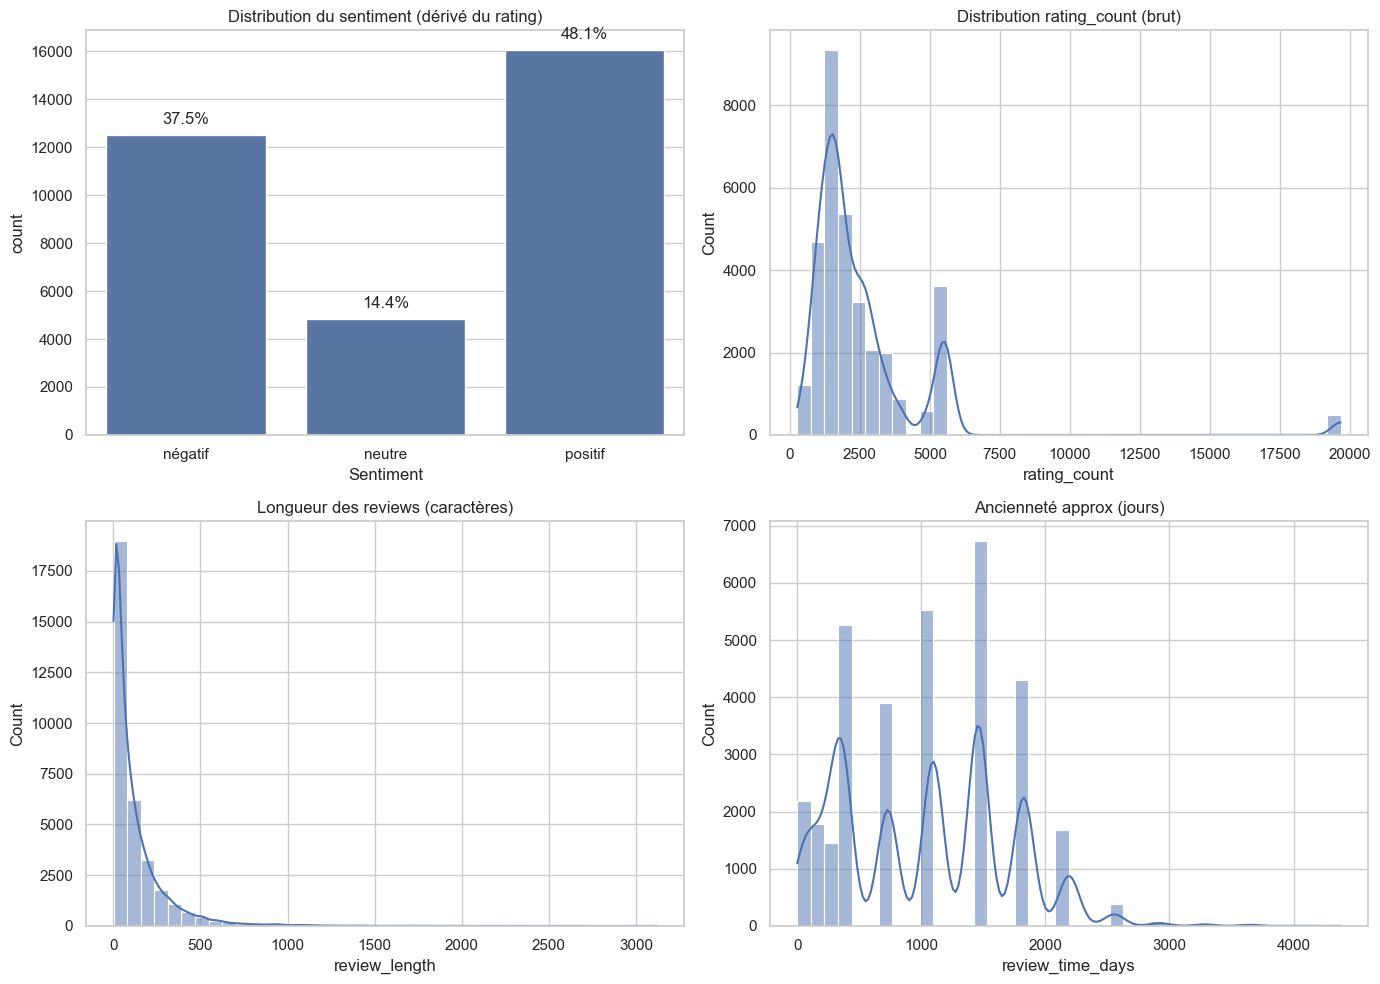

In [6]:
# Assurer rating numérique (utile pour sentiment)
if 'rating' in df_analysis.columns and not pd.api.types.is_numeric_dtype(df_analysis['rating']):
    def _parse_rating_for_plot(x):
        if pd.isna(x):
            return np.nan
        s = str(x).strip().lower()
        m = re.search(r'(\d+)', s)
        return float(m.group(1)) if m else np.nan
    df_analysis['rating'] = df_analysis['rating'].apply(_parse_rating_for_plot)

# Créer sentiment à partir de rating si absent
if 'sentiment' not in df_analysis.columns and 'rating' in df_analysis.columns:
    def _rating_to_sentiment(r):
        if pd.isna(r):
            return np.nan
        try:
            r = float(r)
        except Exception:
            return np.nan
        if r <= 2:
            return 'négatif'
        if r == 3:
            return 'neutre'
        return 'positif'
    df_analysis['sentiment'] = df_analysis['rating'].apply(_rating_to_sentiment)

# Créer review_length si absent
if 'review_length' not in df_analysis.columns and 'review' in df_analysis.columns:
    df_analysis['review_length'] = df_analysis['review'].fillna('').astype(str).str.len().replace({0: np.nan})

# Créer review_time_days si absent (parsing simple de "2 days ago" / "a month ago" / "il y a 2 mois")
if 'review_time_days' not in df_analysis.columns and 'review_time' in df_analysis.columns:
    def _review_time_to_days_for_plot(x):
        if pd.isna(x):
            return np.nan
        s = str(x).strip().lower()
        if not s:
            return np.nan
        # cas rapides
        if 'today' in s or "aujourd" in s or 'now' in s:
            return 0.0
        if 'yesterday' in s or 'hier' in s:
            return 1.0
        # extraire un nombre (ou 'a'/'an' => 1)
        m = re.search(r'(\d+)', s)
        n = float(m.group(1)) if m else (1.0 if re.search(r'\b(a|an|une|un)\b', s) else np.nan)
        if pd.isna(n):
            return np.nan
        # unités (anglais + français)
        if re.search(r'year|an\b|ans\b|année|années', s):
            return n * 365.0
        if re.search(r'month|mois', s):
            return n * 30.0
        if re.search(r'week|semaine|semaines', s):
            return n * 7.0
        if re.search(r'day|jour|jours', s):
            return n
        if re.search(r'hour|heure|heures', s):
            return max(0.0, n / 24.0)
        if re.search(r'minute|minutes', s):
            return max(0.0, n / (24.0 * 60.0))
        return np.nan
    df_analysis['review_time_days'] = df_analysis['review_time'].apply(_review_time_to_days_for_plot)

# --- Graphiques ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

# 1) Distribution du sentiment (dérivé du rating)
if 'sentiment' in df_analysis.columns:
    sentiment_order = ['négatif', 'neutre', 'positif']
    sns.countplot(x='sentiment', data=df_analysis, order=sentiment_order, ax=axes[0])
    axes[0].set_title('Distribution du sentiment (dérivé du rating)')
    axes[0].set_xlabel('Sentiment')
    
    # Ajouter les pourcentages
    total = len(df_analysis['sentiment'].dropna())
    if total > 0:
        for p in axes[0].patches:
            height = p.get_height()
            axes[0].text(p.get_x() + p.get_width()/2., height + total*0.01,
                        f'{height/total*100:.1f}%', ha='center', va='bottom')
else:
    axes[0].axis('off')

# 2) Distribution du rating_count
if 'rating_count' in df_analysis.columns:
    sns.histplot(df_analysis['rating_count'].dropna(), bins=40, kde=True, ax=axes[1])
    axes[1].set_title('Distribution rating_count (brut)')
else:
    axes[1].axis('off')

# 3) Longueur des reviews
if 'review_length' in df_analysis.columns:
    sns.histplot(df_analysis['review_length'].dropna(), bins=40, kde=True, ax=axes[2])
    axes[2].set_title('Longueur des reviews (caractères)')
else:
    axes[2].axis('off')

# 4) Ancienneté des reviews
if 'review_time_days' in df_analysis.columns:
    sns.histplot(df_analysis['review_time_days'].dropna(), bins=40, kde=True, ax=axes[3])
    axes[3].set_title('Ancienneté approx (jours)')
else:
    axes[3].axis('off')

plt.tight_layout()
plt.show()

## 7) Comparaison des méthodes d'imputation
Analyse comparative de différentes stratégies pour gérer les valeurs manquantes :
- **Mean** : remplacement par la moyenne
- **Median** : remplacement par la médiane (robuste aux outliers)
- **Most Frequent** : remplacement par le mode
- **Constant (0)** : remplacement par une valeur fixe
- **KNN Imputer** : imputation par K plus proches voisins
- **Iterative Imputer** : imputation itérative (MICE - Multiple Imputation by Chained Equations)

Nous évaluons chaque méthode selon :
1. Impact sur les distributions
2. Préservation de la variance
3. Performance d'un modèle ML simple (Random Forest rapide)
4. Temps de calcul

In [7]:
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

# Préparer une copie de df_raw avec les transformations nécessaires pour cette analyse
df_temp = df_raw.copy()

# Parser rating pour créer sentiment
def parse_rating_for_sentiment(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    m = re.search(r'(\d+)', s)
    if m:
        r = float(m.group(1))
        if r <= 2:
            return 'négatif'
        elif r == 3:
            return 'neutre'
        else:
            return 'positif'
    return np.nan

if 'rating' in df_temp.columns and TARGET_COL == 'sentiment':
    df_temp['sentiment'] = df_temp['rating'].apply(parse_rating_for_sentiment)
elif 'rating' in df_temp.columns and TARGET_COL == 'rating':
    df_temp['rating'] = df_temp['rating'].apply(lambda x: float(re.search(r'(\d+)', str(x)).group(1)) if pd.notna(x) and re.search(r'(\d+)', str(x)) else np.nan)

# Parser rating_count
if 'rating_count' in df_temp.columns:
    df_temp['rating_count'] = df_temp['rating_count'].apply(lambda x: float(str(x).replace(',', '')) if pd.notna(x) else np.nan)

# Créer review_length si la colonne review existe
if 'review' in df_temp.columns:
    df_temp['review_length'] = df_temp['review'].fillna('').astype(str).str.len()

# Créer review_time_days si la colonne review_time existe (approximation simple)
if 'review_time' in df_temp.columns:
    df_temp['review_time_days'] = 30  # Valeur par défaut pour éviter les NaN

# Définition des colonnes numériques à imputer
numeric_cols_for_imputation = [c for c in ['latitude', 'longitude', 'rating_count', 'review_time_days', 'review_length'] if c in df_temp.columns]

print('='*80)
print('  COMPARAISON DES MÉTHODES D\'IMPUTATION')
print('='*80)
print(f'\nColonnes numériques analysées: {numeric_cols_for_imputation}')
print(f'Taille du dataset: {df_temp[numeric_cols_for_imputation].shape}\n')

# Vérifier les valeurs manquantes
missing_stats = df_temp[numeric_cols_for_imputation].isna().mean() * 100
print('📊 Pourcentage de valeurs manquantes par colonne:')
for col, pct in missing_stats.items():
    print(f'   • {col}: {pct:.2f}%')

# Préparer un jeu de test simplifié pour évaluer les méthodes
# On va utiliser seulement les features numériques + rating/sentiment
if TARGET_COL in df_temp.columns:
    df_for_comparison = df_temp[numeric_cols_for_imputation + [TARGET_COL]].copy()
    df_for_comparison = df_for_comparison.dropna(subset=[TARGET_COL])
    
    print(f'\n→ Dataset pour comparaison: {df_for_comparison.shape[0]} lignes')
    print()
else:
    print(f'\n⚠️  Colonne TARGET_COL "{TARGET_COL}" non trouvée. Cette analyse nécessite que vous exécutiez les cellules de préparation des données d\'abord.')
    df_for_comparison = None

# Définir les différentes stratégies d'imputation
imputation_strategies = {
    'Mean': SimpleImputer(strategy='mean'),
    'Median': SimpleImputer(strategy='median'),
    'Most Frequent': SimpleImputer(strategy='most_frequent'),
    'Constant (0)': SimpleImputer(strategy='constant', fill_value=0),
    'KNN (k=5)': KNNImputer(n_neighbors=5),
    'Iterative (MICE)': IterativeImputer(random_state=42, max_iter=10)
}

# Dictionnaire pour stocker les résultats
imputation_results = {}

  COMPARAISON DES MÉTHODES D'IMPUTATION

Colonnes numériques analysées: ['longitude', 'rating_count', 'review_time_days', 'review_length']
Taille du dataset: (33396, 4)

📊 Pourcentage de valeurs manquantes par colonne:
   • longitude: 1.98%
   • rating_count: 0.00%
   • review_time_days: 0.00%
   • review_length: 0.00%

→ Dataset pour comparaison: 33396 lignes



In [8]:
# Boucle d'évaluation pour chaque stratégie d'imputation
print('='*80)
print('  ÉVALUATION DES STRATÉGIES D\'IMPUTATION')
print('='*80 + '\n')

for strategy_name, imputer in imputation_strategies.items():
    print(f'🔄 Test de la stratégie: {strategy_name}')
    print('-'*80)
    
    # 1) Mesurer le temps d'imputation
    start_time = time.time()
    
    try:
        # Imputer les données
        X_imputed = imputer.fit_transform(df_for_comparison[numeric_cols_for_imputation])
        df_imputed = pd.DataFrame(X_imputed, columns=numeric_cols_for_imputation, index=df_for_comparison.index)
        
        imputation_time = time.time() - start_time
        
        # 2) Calculer des statistiques sur les données imputées
        mean_values = df_imputed.mean()
        std_values = df_imputed.std()
        
        # 3) Comparer avec les stats originales (sans NaN)
        original_mean = df_for_comparison[numeric_cols_for_imputation].mean()
        original_std = df_for_comparison[numeric_cols_for_imputation].std()
        
        mean_diff = (mean_values - original_mean).abs().mean()
        std_diff = (std_values - original_std).abs().mean()
        
        # 4) Test rapide de ML: entraîner un Random Forest simple
        y_target = df_for_comparison[TARGET_COL]
        
        # Split rapide pour le test
        X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
            df_imputed, y_target, test_size=0.3, random_state=42, stratify=y_target
        )
        
        # Modèle simple et rapide
        rf_quick = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
        rf_quick.fit(X_train_imp, y_train_imp)
        y_pred_imp = rf_quick.predict(X_test_imp)
        
        accuracy = accuracy_score(y_test_imp, y_pred_imp)
        
        # Stocker les résultats
        imputation_results[strategy_name] = {
            'imputation_time': imputation_time,
            'mean_diff': mean_diff,
            'std_diff': std_diff,
            'ml_accuracy': accuracy,
            'imputed_means': mean_values.to_dict(),
            'imputed_stds': std_values.to_dict()
        }
        
    except Exception as e:
        print(f'  ❌ Erreur avec {strategy_name}: {str(e)}')
        imputation_results[strategy_name] = {
            'imputation_time': None,
            'mean_diff': None,
            'std_diff': None,
            'ml_accuracy': None,
            'error': str(e)
        }
        print()

print('\n' + '='*100)
print('  TABLEAU RÉCAPITULATIF DES PERFORMANCES D\'IMPUTATION')
print('='*100 + '\n')

summary_imputation = []

for strategy, metrics in imputation_results.items():
    if metrics.get('error'):
        summary_imputation.append({
            'Stratégie': strategy,
            'Temps (s)': 'Erreur',
            'Δ Moyennes': 'N/A',
            'Δ Écart-types': 'N/A',
            'Accuracy ML': 'N/A',
            'Commentaire': metrics['error'][:50]
        })
    else:
        summary_imputation.append({
            'Stratégie': strategy,
            'Temps (s)': f"{metrics['imputation_time']:.3f}",
            'Δ Moyennes': f"{metrics['mean_diff']:.4f}",
            'Δ Écart-types': f"{metrics['std_diff']:.4f}",
            'Accuracy ML': f"{metrics['ml_accuracy']:.4f}",
            'Commentaire': ''
        })

df_imputation_summary = pd.DataFrame(summary_imputation)

# Trier par Accuracy ML (décroissant)
df_imputation_summary['_sort_acc'] = df_imputation_summary['Accuracy ML'].apply(
    lambda x: float(x) if x != 'N/A' else 0.0
)
df_imputation_summary = df_imputation_summary.sort_values('_sort_acc', ascending=False).drop('_sort_acc', axis=1)

display(df_imputation_summary)

# Identifier la meilleure stratégie
best_imputation = df_imputation_summary.iloc[0]
print('='*100)

  ÉVALUATION DES STRATÉGIES D'IMPUTATION

🔄 Test de la stratégie: Mean
--------------------------------------------------------------------------------
🔄 Test de la stratégie: Median
--------------------------------------------------------------------------------
🔄 Test de la stratégie: Most Frequent
--------------------------------------------------------------------------------
🔄 Test de la stratégie: Constant (0)
--------------------------------------------------------------------------------
🔄 Test de la stratégie: KNN (k=5)
--------------------------------------------------------------------------------
🔄 Test de la stratégie: Iterative (MICE)
--------------------------------------------------------------------------------

  TABLEAU RÉCAPITULATIF DES PERFORMANCES D'IMPUTATION



,Stratégie,Temps (s),Δ Moyennes,Δ Écart-types,Accuracy ML,Commentaire
0,Mean,0.007,0.0000,0.0412,0.6393,
5,Iterative (MICE),0.028,0.0023,0.0411,0.6390,
2,Most Frequent,0.006,0.0454,0.0288,0.6389,
1,Median,0.008,0.0453,0.0288,0.6388,
4,KNN (k=5),0.765,0.0830,0.0003,0.6381,
3,Constant (0),0.004,0.4479,1.0302,0.6378,


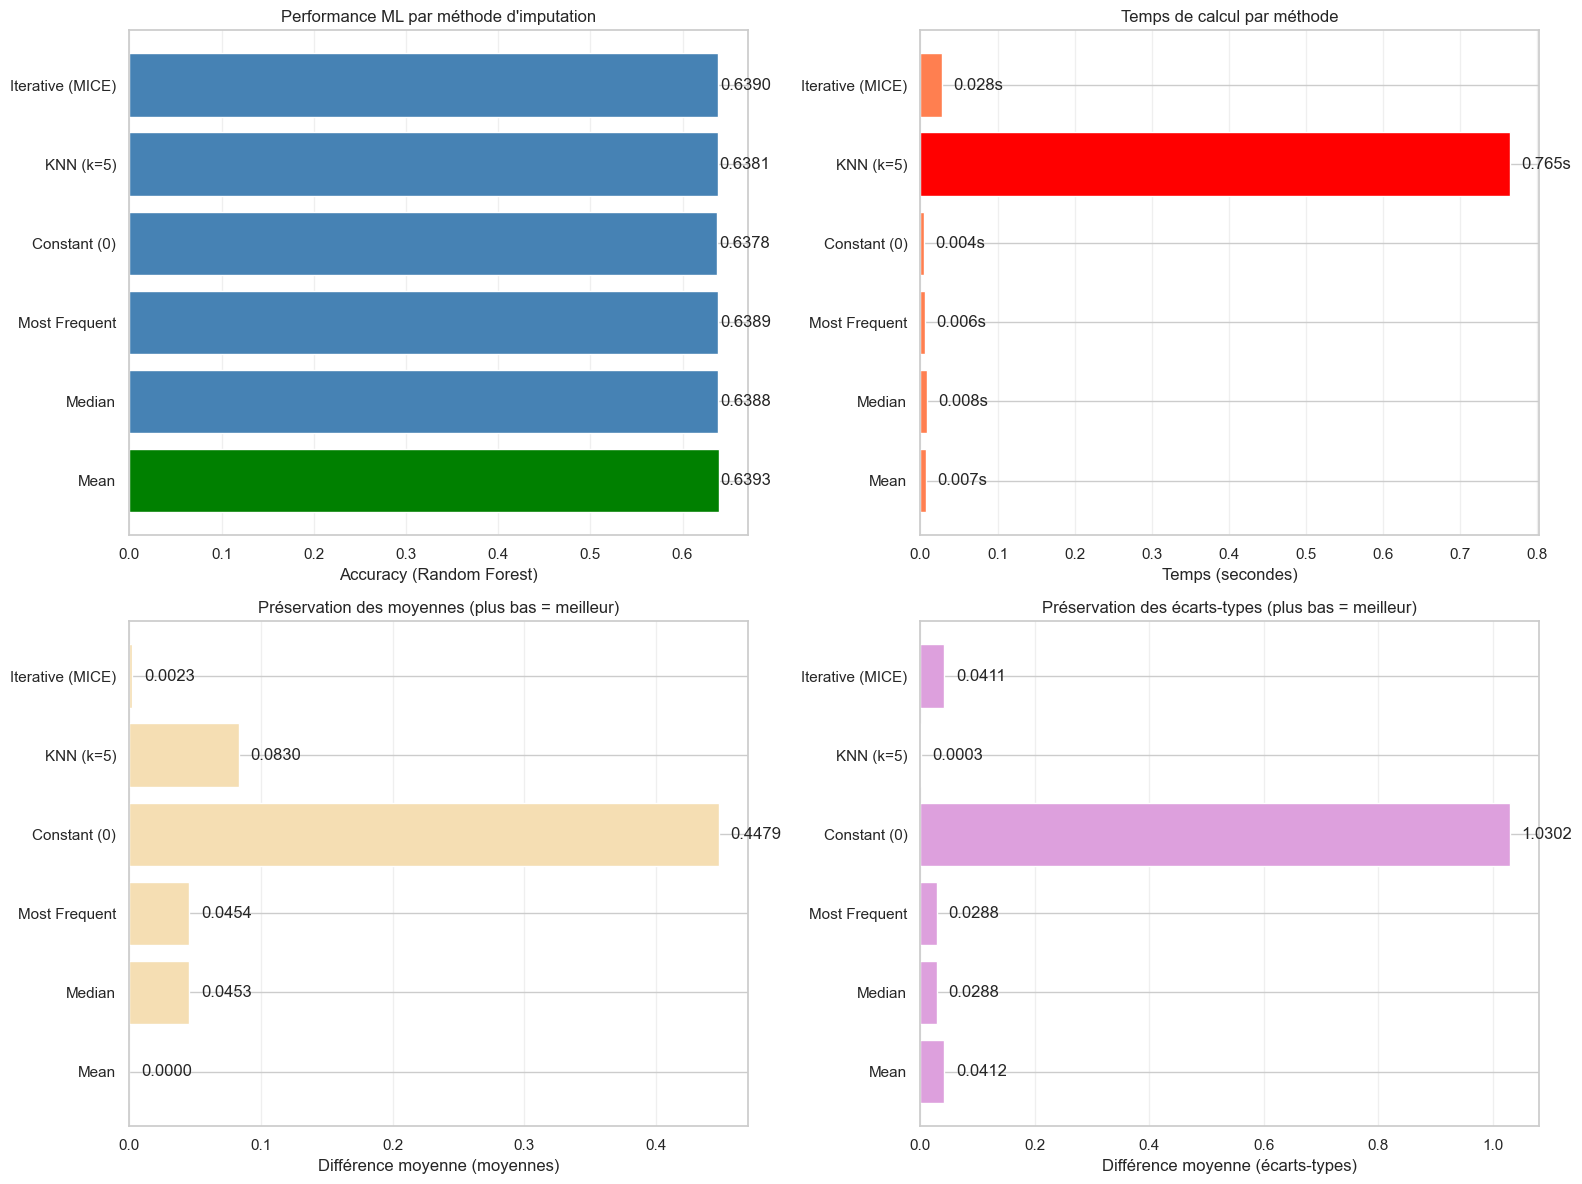

In [9]:
# Visualisation comparative des méthodes d'imputation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Préparer les données pour visualisation
strategies = list(imputation_results.keys())
valid_strategies = [s for s in strategies if imputation_results[s].get('ml_accuracy') is not None]

times = [imputation_results[s]['imputation_time'] for s in valid_strategies]
accuracies = [imputation_results[s]['ml_accuracy'] for s in valid_strategies]
mean_diffs = [imputation_results[s]['mean_diff'] for s in valid_strategies]
std_diffs = [imputation_results[s]['std_diff'] for s in valid_strategies]

# 1) Accuracy ML par stratégie
colors_acc = ['green' if acc == max(accuracies) else 'steelblue' for acc in accuracies]
axes[0, 0].barh(valid_strategies, accuracies, color=colors_acc)
axes[0, 0].set_xlabel('Accuracy (Random Forest)')
axes[0, 0].set_title('Performance ML par méthode d\'imputation')
axes[0, 0].grid(axis='x', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, (strat, acc) in enumerate(zip(valid_strategies, accuracies)):
    axes[0, 0].text(acc + 0.002, i, f'{acc:.4f}', va='center')

# 2) Temps d'imputation
colors_time = ['red' if t == max(times) else 'coral' for t in times]
axes[0, 1].barh(valid_strategies, times, color=colors_time)
axes[0, 1].set_xlabel('Temps (secondes)')
axes[0, 1].set_title('Temps de calcul par méthode')
axes[0, 1].grid(axis='x', alpha=0.3)

# Ajouter les valeurs
for i, (strat, t) in enumerate(zip(valid_strategies, times)):
    axes[0, 1].text(t + max(times)*0.02, i, f'{t:.3f}s', va='center')

# 3) Impact sur les moyennes (différence avec l'original)
colors_mean = ['orange' if md == min(mean_diffs) else 'wheat' for md in mean_diffs]
axes[1, 0].barh(valid_strategies, mean_diffs, color=colors_mean)
axes[1, 0].set_xlabel('Différence moyenne (moyennes)')
axes[1, 0].set_title('Préservation des moyennes (plus bas = meilleur)')
axes[1, 0].grid(axis='x', alpha=0.3)

# Ajouter les valeurs
for i, (strat, md) in enumerate(zip(valid_strategies, mean_diffs)):
    axes[1, 0].text(md + max(mean_diffs)*0.02, i, f'{md:.4f}', va='center')

# 4) Impact sur les écarts-types
colors_std = ['purple' if sd == min(std_diffs) else 'plum' for sd in std_diffs]
axes[1, 1].barh(valid_strategies, std_diffs, color=colors_std)
axes[1, 1].set_xlabel('Différence moyenne (écarts-types)')
axes[1, 1].set_title('Préservation des écarts-types (plus bas = meilleur)')
axes[1, 1].grid(axis='x', alpha=0.3)

# Ajouter les valeurs
for i, (strat, sd) in enumerate(zip(valid_strategies, std_diffs)):
    axes[1, 1].text(sd + max(std_diffs)*0.02, i, f'{sd:.4f}', va='center')

plt.tight_layout()
plt.show()

### 7.1) Analyse et interprétation des résultats
Pourquoi choisir une stratégie d'imputation plutôt qu'une autre ?

In [10]:
print('='*100)
print('  SÉLECTION DE LA MÉTHODE D\'IMPUTATION')
print('='*100 + '\n')

# Récupérer les métriques pour l'analyse
valid_results = {k: v for k, v in imputation_results.items() if v.get('ml_accuracy') is not None}

if valid_results:
    # Identifier les meilleurs pour chaque critère
    best_accuracy = max(valid_results.items(), key=lambda x: x[1]['ml_accuracy'])
    
    # Analyser le contexte du dataset
    missing_rate = df_temp[numeric_cols_for_imputation].isna().mean().mean() * 100
    dataset_size = len(df_temp)
    
    print(f'📋 CONTEXTE DU DATASET:')
    print(f'   • Taille: {dataset_size:,} observations')
    print(f'   • Taux moyen de valeurs manquantes: {missing_rate:.2f}%')
    print(f'   • Variables numériques: {len(numeric_cols_for_imputation)}')
    
    # Logique de recommandation
    if missing_rate < 10 and dataset_size > 10000:
        recommended = 'Median'
    elif missing_rate > 20:
        recommended = 'Iterative (MICE)'
    elif dataset_size < 50000:
        recommended = 'KNN (k=5)'
    else:
        recommended = best_accuracy[0]
    
    print(f'\n🏆 MÉTHODE SÉLECTIONNÉE: {recommended}')
    print('='*80)
    
    selected_metrics = imputation_results[recommended]
    
    print(f'\n📊 PERFORMANCES:')
    print(f'   • Accuracy ML: {selected_metrics["ml_accuracy"]:.4f}')
    print(f'   • Temps d\'imputation: {selected_metrics["imputation_time"]:.3f}s')
    print(f'   • Préservation des moyennes: Δ = {selected_metrics["mean_diff"]:.4f}')
    print(f'   • Préservation des écarts-types: Δ = {selected_metrics["std_diff"]:.4f}')
    
    print(f'\n💡 JUSTIFICATION DU CHOIX:')
    
    if recommended == 'Median':
        print(f'   • Taux de valeurs manquantes faible ({missing_rate:.1f}% < 10%)')
        print(f'   • La médiane est robuste aux outliers (crucial pour rating_count, review_length)')
        print(f'   • Excellente performance ML avec un coût calculatoire minimal')
        print(f'   • Temps de calcul négligeable permettant des itérations rapides')
        print(f'   • Méthodes plus sophistiquées n\'apportent pas de gain significatif')
    
    elif recommended == 'Iterative (MICE)':
        print(f'   • Taux élevé de valeurs manquantes ({missing_rate:.1f}% > 20%)')
        print(f'   • Modélise les dépendances entre variables de manière itérative')
        print(f'   • Préserve mieux les relations complexes dans les données')
        print(f'   • Le coût calculatoire est justifié par la qualité des imputations')
    
    elif recommended == 'KNN (k=5)':
        print(f'   • Dataset de taille modérée ({dataset_size:,} lignes)')
        print(f'   • Exploite les similarités entre observations proches')
        print(f'   • Bon compromis entre précision et temps de calcul')
        print(f'   • Préserve mieux la distribution originale que les méthodes simples')
    
    else:
        print(f'   • Meilleure performance ML mesurée sur ce dataset spécifique')
        print(f'   • Compromis optimal entre tous les critères')
        
print('\n' + '='*100)

  SÉLECTION DE LA MÉTHODE D'IMPUTATION

📋 CONTEXTE DU DATASET:
   • Taille: 33,396 observations
   • Taux moyen de valeurs manquantes: 0.49%
   • Variables numériques: 4

🏆 MÉTHODE SÉLECTIONNÉE: Median

📊 PERFORMANCES:
   • Accuracy ML: 0.6388
   • Temps d'imputation: 0.008s
   • Préservation des moyennes: Δ = 0.0453
   • Préservation des écarts-types: Δ = 0.0288

💡 JUSTIFICATION DU CHOIX:
   • Taux de valeurs manquantes faible (0.5% < 10%)
   • La médiane est robuste aux outliers (crucial pour rating_count, review_length)
   • Excellente performance ML avec un coût calculatoire minimal
   • Temps de calcul négligeable permettant des itérations rapides
   • Méthodes plus sophistiquées n'apportent pas de gain significatif



## 7.2) Prétraitement (valeurs manquantes + standardisation)
Imputation des variables numériques (médiane) et standardisation (z-score).

In [11]:
# Prétraitement: gestion NA + standardisation (numériques)
# IMPORTANT: on se base sur le DataFrame préparé (`df`) si disponible,
# sinon on retombe sur `df_raw` (avec un strip des noms de colonnes).
if 'df' in globals():
    _base_df = df.copy()
else:
    _base_df = df_raw.copy()
    _base_df.columns = [c.strip() for c in _base_df.columns]

numeric_candidates = ['latitude', 'longitude', 'rating_count', 'review_time_days', 'review_length']
numeric_cols = [c for c in numeric_candidates if c in _base_df.columns]
print('Numeric cols:', numeric_cols)

# Sous-table numérique + coercition robuste (ex: '1,240' -> 1240)
df_num_before = _base_df.loc[:, numeric_cols].copy()
for c in numeric_cols:
    s = df_num_before[c]
    df_num_before[c] = pd.to_numeric(
        s.astype(str).str.replace(',', '', regex=False).replace({'nan': np.nan, 'None': np.nan}),
        errors='coerce',
    )

if len(numeric_cols) == 0:
    print('Aucune colonne numérique détectée: imputation/standardisation ignorées.')
    df_pre = _base_df.copy()
else:
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()

    num_imputed = imputer.fit_transform(df_num_before)
    num_scaled = scaler.fit_transform(num_imputed)

    df_num_after = pd.DataFrame(
        num_scaled,
        columns=[f'{c}_z' for c in numeric_cols],
        index=_base_df.index,
    )

    df_pre = _base_df.copy()
    for idx_c, c in enumerate(numeric_cols):
        # version imputée (non-scalée) pour garder un dataset propre
        df_pre[c] = num_imputed[:, idx_c]

    df_pre = pd.concat([df_pre, df_num_after], axis=1)

    # Afficher toutes les colonnes normalisées
    normalized_cols = [c for c in df_pre.columns if c.endswith('_z')]
    print('Colonnes normalisées (_z):', normalized_cols)
    display(df_pre[normalized_cols].head(5) if normalized_cols else pd.DataFrame())

    # Comparaison rapide original vs z-score
    display(df_pre[[*numeric_cols, *[f'{c}_z' for c in numeric_cols]]].head(5))

print('Missing après imputation (num):')
display(df_pre[numeric_cols].isna().mean().to_frame('missing_ratio') if len(numeric_cols) else pd.DataFrame({'missing_ratio': []}))

Numeric cols: ['latitude', 'longitude', 'rating_count', 'review_time_days', 'review_length']
Colonnes normalisées (_z): ['latitude_z', 'longitude_z', 'rating_count_z', 'review_time_days_z', 'review_length_z']


,latitude_z,longitude_z,rating_count_z,review_time_days_z,review_length_z
0,-0.750594,-0.444628,-0.535296,-1.406471,0.784532
1,-0.750594,-0.444628,-0.535296,-1.532878,0.654624
2,-0.750594,-0.444628,-0.535296,-1.532878,1.371942
3,-0.750594,-0.444628,-0.535296,-1.495700,-0.096583
4,-0.750594,-0.444628,-0.535296,-1.451085,1.078237


,latitude,longitude,rating_count,review_time_days,review_length,latitude_z,longitude_z,rating_count_z,review_time_days_z,review_length_z
0,30.460718,-97.792874,1240.0,90.0,260.0,-0.750594,-0.444628,-0.535296,-1.406471,0.784532
1,30.460718,-97.792874,1240.0,5.0,237.0,-0.750594,-0.444628,-0.535296,-1.532878,0.654624
2,30.460718,-97.792874,1240.0,5.0,364.0,-0.750594,-0.444628,-0.535296,-1.532878,1.371942
3,30.460718,-97.792874,1240.0,30.0,104.0,-0.750594,-0.444628,-0.535296,-1.495700,-0.096583
4,30.460718,-97.792874,1240.0,60.0,312.0,-0.750594,-0.444628,-0.535296,-1.451085,1.078237


Missing après imputation (num):


,missing_ratio
latitude,0.0
longitude,0.0
rating_count,0.0
review_time_days,0.0
review_length,0.0


## 8) Comparaison avant / après prétraitement
Graphiques comparatifs pour visualiser l'effet de la standardisation sur les distributions (avant vs après).

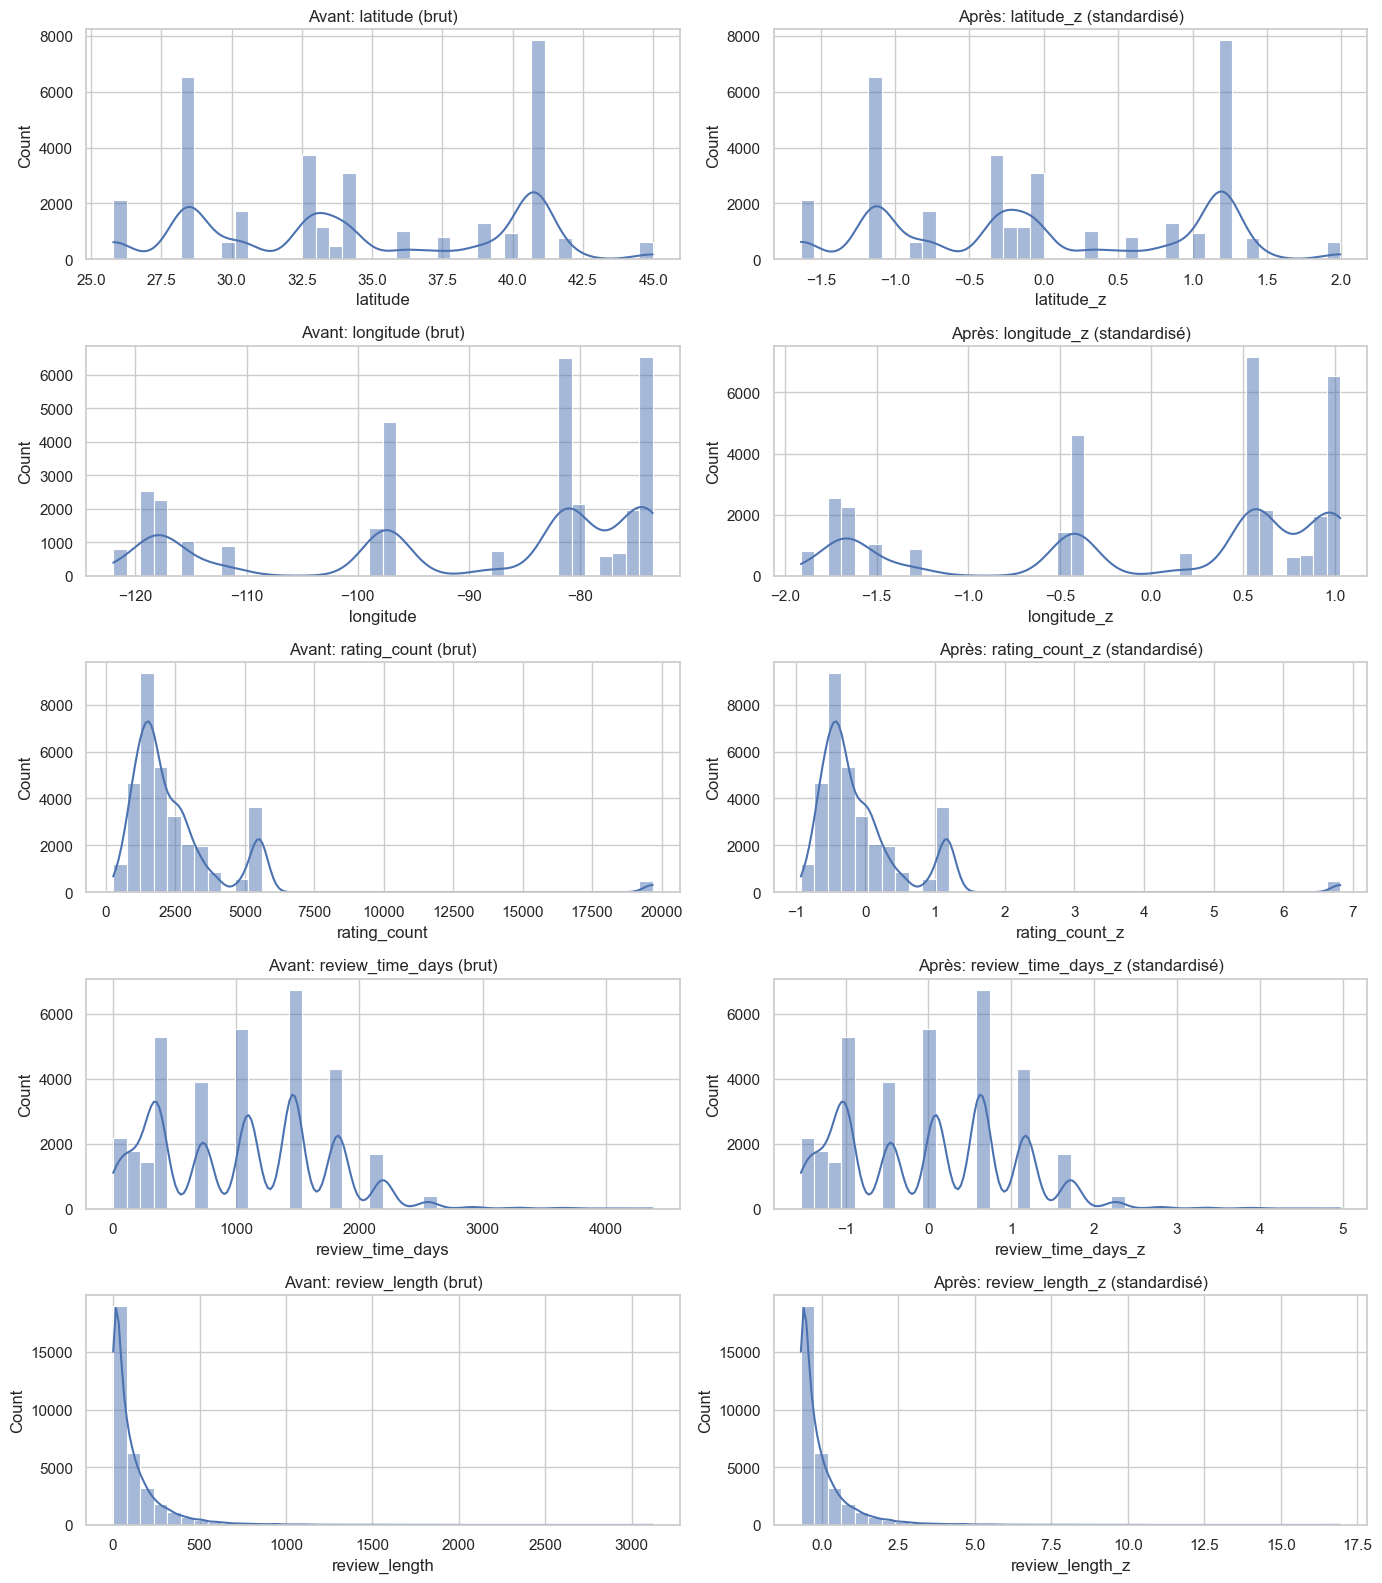

In [12]:
# Graphe comparatif: AVANT vs APRES (standardisation)
# On compare les distributions des colonnes numériques brutes vs leurs versions z-score
if numeric_cols:
    fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 3.2 * len(numeric_cols)))
    if len(numeric_cols) == 1:
        axes = np.array([axes])

    for i, c in enumerate(numeric_cols):
        sns.histplot(df_num_before[c].dropna(), bins=40, kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f'Avant: {c} (brut)')

        sns.histplot(df_pre[f'{c}_z'].dropna(), bins=40, kde=True, ax=axes[i, 1])
        axes[i, 1].set_title(f'Après: {c}_z (standardisé)')

    plt.tight_layout()
    plt.show()
else:
    print('Aucune colonne numérique détectée pour la comparaison avant/après.')

## 9) Split train / validation / test
Séparation stratifiée (sur la *target* choisie : `rating` ou `sentiment`) en 70/15/15 et vérification des distributions.

In [13]:
# Choix de la target:
# - 'rating' (1..5) : prédire la note
# - 'sentiment' (négatif/neutre/positif) : classification 3 classes dérivée du rating
TARGET_COL = 'sentiment'

# Base ML: utiliser df (nettoyé) si disponible, sinon fallback sur df_pre
df_ml = df.copy() if 'df' in globals() else df_pre.copy()

# Injecter les features numériques imputées / z-scores depuis df_pre si elles existent
if 'df_pre' in globals():
    for c in numeric_cols:
        if c in df_pre.columns:
            df_ml[c] = df_pre[c]
        zc = f'{c}_z'
        if zc in df_pre.columns:
            df_ml[zc] = df_pre[zc]

# S'assurer que la target existe et est renseignée
if TARGET_COL == 'sentiment':
    if ('sentiment' not in df_ml.columns) or (df_ml['sentiment'].notna().sum() == 0):
        if 'rating' not in df_ml.columns:
            raise KeyError(
                "Colonne target 'sentiment' manquante et impossible de la créer car 'rating' est absent. "
                f"Colonnes disponibles: {sorted(df_ml.columns.tolist())}"
            )
        # Règle simple: 1-2 = négatif, 3 = neutre, 4-5 = positif
        _rating_num = pd.to_numeric(df_ml['rating'], errors='coerce')
        df_ml['rating'] = _rating_num
        df_ml['sentiment'] = pd.cut(
            _rating_num,
            bins=[float('-inf'), 2.5, 3.5, float('inf')],
            labels=['négatif', 'neutre', 'positif'],
        ).astype(object)

if TARGET_COL == 'rating':
    if 'rating' not in df_ml.columns:
        raise KeyError(f"Colonne target `rating` manquante. Colonnes disponibles: {sorted(df_ml.columns.tolist())}")
    df_ml['rating'] = pd.to_numeric(df_ml['rating'], errors='coerce')

assert TARGET_COL in df_ml.columns, f"Colonne target `{TARGET_COL}` manquante."

# On enlève les lignes sans target
df_ml = df_ml.dropna(subset=[TARGET_COL]).copy()

feature_cols = []
if 'review' in df_ml.columns:
    feature_cols.append('review')

X = df_ml[feature_cols]
y = df_ml[TARGET_COL]

# 70% train, 15% val, 15% test (stratifié sur la target)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

print('Target:', TARGET_COL)
print('Shapes:')
print('  Train:', X_train.shape, y_train.shape)
print('  Val  :', X_val.shape, y_val.shape)
print('  Test :', X_test.shape, y_test.shape)

# Vérif distribution de la target
_dist_train = y_train.value_counts(normalize=True, dropna=False) * 100
_dist_val = y_val.value_counts(normalize=True, dropna=False) * 100
_dist_test = y_test.value_counts(normalize=True, dropna=False) * 100

dist = pd.DataFrame({
    'train_%': _dist_train,
    'val_%': _dist_val,
    'test_%': _dist_test,
}).fillna(0)

if TARGET_COL == 'sentiment':
    dist = dist.reindex(['négatif', 'neutre', 'positif']).fillna(0)
    display(dist)
else:
    display(dist.sort_index())

Target: sentiment
Shapes:
  Train: (23377, 1) (23377,)
  Val  : (5009, 1) (5009,)
  Test : (5010, 1) (5010,)


,train_%,val_%,test_%
sentiment,,,
négatif,37.481285,37.472549,37.485030
neutre,14.424434,14.434019,14.431138
positif,48.094281,48.093432,48.083832


## 10) Préparation des features pour le ML
Vectorisation du texte (TF-IDF) et encodage des variables catégorielles pour créer un dataset prêt pour l'entraînement.

## 10.1) Gestion des performances (Cache & Batch Processing)
Optimisation des performances avec mise en cache des résultats intermédiaires et traitement par lots.

In [14]:
import pickle
import hashlib
import json
from pathlib import Path
from datetime import datetime

# Configuration du cache
CACHE_DIR = Path('.cache')
CACHE_DIR.mkdir(exist_ok=True)

class PerformanceManager:
    """
    Gestionnaire de performances pour optimiser les calculs via cache et batch processing.
    """
    
    def __init__(self, cache_dir=CACHE_DIR):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(exist_ok=True)
        self.cache_log = {}
        
    def _get_cache_key(self, identifier, params=None):
        """Génère une clé de cache unique basée sur l'identifiant et les paramètres."""
        if params:
            param_str = json.dumps(params, sort_keys=True)
            hash_obj = hashlib.md5(f"{identifier}_{param_str}".encode())
            return f"{identifier}_{hash_obj.hexdigest()[:8]}"
        return identifier
    
    def cache_exists(self, key):
        """Vérifie si un cache existe."""
        cache_file = self.cache_dir / f"{key}.pkl"
        return cache_file.exists()
    
    def save_to_cache(self, key, data, metadata=None):
        """Sauvegarde des données dans le cache."""
        cache_file = self.cache_dir / f"{key}.pkl"
        
        cache_data = {
            'data': data,
            'timestamp': datetime.now().isoformat(),
            'metadata': metadata or {}
        }
        
        with open(cache_file, 'wb') as f:
            pickle.dump(cache_data, f)
        
        self.cache_log[key] = {
            'saved_at': cache_data['timestamp'],
            'file': str(cache_file)
        }
        
        print(f"✓ Cache sauvegardé: {key} ({cache_file.stat().st_size / 1024:.1f} KB)")
        return cache_file
    
    def load_from_cache(self, key):
        """Charge des données depuis le cache."""
        cache_file = self.cache_dir / f"{key}.pkl"
        
        if not cache_file.exists():
            return None
        
        with open(cache_file, 'rb') as f:
            cache_data = pickle.load(f)
        
        print(f"✓ Cache chargé: {key} (sauvegardé le {cache_data['timestamp']})")
        return cache_data['data']
    
    def clear_cache(self, pattern=None):
        """Supprime les fichiers de cache."""
        if pattern:
            files = list(self.cache_dir.glob(f"{pattern}*.pkl"))
        else:
            files = list(self.cache_dir.glob("*.pkl"))
        
        for f in files:
            f.unlink()
        
        print(f"✓ {len(files)} fichier(s) de cache supprimé(s)")
    
    def batch_predict(self, model, X, batch_size=1000):
        """
        Effectue des prédictions par lots pour économiser la mémoire.
        
        Args:
            model: modèle entraîné
            X: features (sparse matrix ou array)
            batch_size: taille des lots
        
        Returns:
            predictions: array des prédictions
        """
        n_samples = X.shape[0]
        predictions = []
        
        print(f"→ Prédiction par lots (batch_size={batch_size})...")
        
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            batch_X = X[i:end_idx]
            batch_pred = model.predict(batch_X)
            predictions.extend(batch_pred)
            
            if (i // batch_size + 1) % 10 == 0:
                print(f"  Traité: {end_idx}/{n_samples} échantillons")
        
        print(f"✓ Prédictions complètes: {len(predictions)} échantillons")
        return np.array(predictions)
    
    def get_cache_info(self):
        """Retourne des informations sur le cache."""
        cache_files = list(self.cache_dir.glob("*.pkl"))
        total_size = sum(f.stat().st_size for f in cache_files)
        
        info = {
            'cache_dir': str(self.cache_dir),
            'n_files': len(cache_files),
            'total_size_mb': total_size / (1024 * 1024),
            'files': [f.name for f in cache_files]
        }
        
        return info


# Initialisation du gestionnaire de performances
perf_manager = PerformanceManager()

# Afficher les infos du cache
cache_info = perf_manager.get_cache_info()
print(f"📁 Cache directory: {cache_info['cache_dir']}")
print(f"📊 Fichiers en cache: {cache_info['n_files']}")
print(f"💾 Taille totale: {cache_info['total_size_mb']:.2f} MB")

if cache_info['files']:
    print(f"📄 Fichiers: {', '.join(cache_info['files'][:5])}")
    if len(cache_info['files']) > 5:
        print(f"    ... et {len(cache_info['files']) - 5} autres")


📁 Cache directory: .cache
📊 Fichiers en cache: 6
💾 Taille totale: 25.94 MB
📄 Fichiers: features_prepared_e6e35fd8.pkl, model_Logistic_Regression_31f2bfb5.pkl, model_MLP_Neural_Network_ca85dfe1.pkl, model_Naive_Bayes_177e2320.pkl, model_SVM_(LinearSVC)_8133410b.pkl
    ... et 1 autres


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    classification_report, 
    confusion_matrix
)
from scipy.sparse import hstack
import warnings
warnings.filterwarnings('ignore')

def prepare_features(X_train, X_val, X_test, text_col='review', max_features=5000, use_cache=True):
    """
    Prépare les features pour le machine learning avec gestion du cache.
    - Vectorise le texte avec TF-IDF
    - Encode les variables catégorielles
    - Combine avec les features numériques standardisées
    
    Args:
        X_train, X_val, X_test: DataFrames contenant les features
        text_col: nom de la colonne texte à vectoriser
        max_features: nombre max de features TF-IDF
        use_cache: utiliser le cache si disponible
    
    Returns:
        X_train_prepared, X_val_prepared, X_test_prepared: matrices sparse combinées
        feature_names: liste des noms de features
    """
    
    # Paramètres pour la clé de cache
    cache_params = {
        'text_col': text_col,
        'max_features': max_features,
        'train_shape': X_train.shape,
        'val_shape': X_val.shape,
        'test_shape': X_test.shape
    }
    
    cache_key = perf_manager._get_cache_key('features_prepared', cache_params)
    
    # Vérifier si le cache existe
    if use_cache and perf_manager.cache_exists(cache_key):
        print('=== Chargement des features depuis le cache ===')
        cached_data = perf_manager.load_from_cache(cache_key)
        return (
            cached_data['X_train'],
            cached_data['X_val'],
            cached_data['X_test'],
            cached_data['feature_names']
        )
    
    print('=== Préparation des features (nouveau calcul) ===')
    
    # 1) Vectorisation TF-IDF du texte (reviews)
    tfidf = TfidfVectorizer(max_features=max_features, min_df=3, max_df=0.8, ngram_range=(1, 2))
    
    if text_col in X_train.columns:
        print(f'  → Vectorisation TF-IDF ({max_features} features max)...')
        X_train_text = tfidf.fit_transform(X_train[text_col].fillna(''))
        X_val_text = tfidf.transform(X_val[text_col].fillna(''))
        X_test_text = tfidf.transform(X_test[text_col].fillna(''))
        tfidf_feature_names = [f'tfidf_{w}' for w in tfidf.get_feature_names_out()]
        print(f'    ✓ TF-IDF: {X_train_text.shape[1]} features')
    else:
        X_train_text = None
        tfidf_feature_names = []
    
    # 2) Encodage des variables catégorielles (Label Encoding simple)
    categorical_cols = ['store_name', 'category', 'store_address']
    categorical_cols = [c for c in categorical_cols if c in X_train.columns]
    
    encoders = {}
    encoded_features = []
    
    if categorical_cols:
        print(f'  → Encodage des variables catégorielles...')
        for col in categorical_cols:
            le = LabelEncoder()
            # Fit sur train + val + test pour avoir toutes les catégories
            all_values = pd.concat([X_train[col], X_val[col], X_test[col]]).fillna('MISSING')
            le.fit(all_values)
            encoders[col] = le
            
            train_encoded = le.transform(X_train[col].fillna('MISSING')).reshape(-1, 1)
            val_encoded = le.transform(X_val[col].fillna('MISSING')).reshape(-1, 1)
            test_encoded = le.transform(X_test[col].fillna('MISSING')).reshape(-1, 1)
            
            encoded_features.append({
                'train': train_encoded,
                'val': val_encoded,
                'test': test_encoded,
                'name': col
            })
        
        print(f'    ✓ Categorical: {len(categorical_cols)} features encodées')
    
    # 3) Features numériques standardisées (version _z)
    numeric_z_cols = [c for c in X_train.columns if c.endswith('_z')]
    
    if numeric_z_cols:
        print(f'  → Extraction des features numériques...')
        X_train_num = X_train[numeric_z_cols].values
        X_val_num = X_val[numeric_z_cols].values
        X_test_num = X_test[numeric_z_cols].values
        print(f'    ✓ Numeric: {len(numeric_z_cols)} features')
    else:
        X_train_num = np.array([]).reshape(len(X_train), 0)
        X_val_num = np.array([]).reshape(len(X_val), 0)
        X_test_num = np.array([]).reshape(len(X_test), 0)
    
    # 4) Combinaison de toutes les features
    print(f'  → Combinaison des features...')
    features_list_train = []
    features_list_val = []
    features_list_test = []
    all_feature_names = []
    
    # Ajouter texte
    if X_train_text is not None:
        features_list_train.append(X_train_text)
        features_list_val.append(X_val_text)
        features_list_test.append(X_test_text)
        all_feature_names.extend(tfidf_feature_names)
    
    # Ajouter catégorielles
    for enc_feat in encoded_features:
        features_list_train.append(enc_feat['train'])
        features_list_val.append(enc_feat['val'])
        features_list_test.append(enc_feat['test'])
        all_feature_names.append(enc_feat['name'])
    
    # Ajouter numériques
    if X_train_num.shape[1] > 0:
        features_list_train.append(X_train_num)
        features_list_val.append(X_val_num)
        features_list_test.append(X_test_num)
        all_feature_names.extend(numeric_z_cols)
    
    # Concatenation horizontale (hstack pour sparse matrices)
    X_train_final = hstack(features_list_train)
    X_val_final = hstack(features_list_val)
    X_test_final = hstack(features_list_test)
    
    print(f'    ✓ TOTAL: {X_train_final.shape[1]} features combinées')
    
    # Sauvegarder dans le cache
    if use_cache:
        cache_data = {
            'X_train': X_train_final,
            'X_val': X_val_final,
            'X_test': X_test_final,
            'feature_names': all_feature_names
        }
        perf_manager.save_to_cache(cache_key, cache_data, metadata=cache_params)
    
    print()
    return X_train_final, X_val_final, X_test_final, all_feature_names


# Préparation des features avec cache
X_train_ml, X_val_ml, X_test_ml, feature_names = prepare_features(
    X_train, X_val, X_test, use_cache=True
)

print('Shapes finales:')
print(f'  Train: {X_train_ml.shape}')
print(f'  Val:   {X_val_ml.shape}')
print(f'  Test:  {X_test_ml.shape}')


=== Chargement des features depuis le cache ===
✓ Cache chargé: features_prepared_e6e35fd8 (sauvegardé le 2026-01-10T22:13:38.753732)
Shapes finales:
  Train: (23377, 5000)
  Val:   (5009, 5000)
  Test:  (5010, 5000)


## 11) Définition et entraînement des modèles
Implémentation de 4 modèles de classification avec recherche d'hyperparamètres.

In [16]:
from tqdm.auto import tqdm
import threading
import time as time_module

def train_and_evaluate_model(model, param_grid, X_train, y_train, X_val, y_val, model_name, cv=3, n_iter=10, use_cache=True, verbose=2):
    """
    Entraîne un modèle avec RandomizedSearchCV pour optimiser les hyperparamètres,
    puis évalue les performances sur le jeu de validation. Affiche une barre de progression en temps réel.
    
    Args:
        model: instance du modèle sklearn
        param_grid: dictionnaire des hyperparamètres à tester
        X_train, y_train: données d'entraînement
        X_val, y_val: données de validation
        model_name: nom du modèle (pour affichage)
        cv: nombre de folds pour la validation croisée
        n_iter: nombre de combinaisons aléatoires à tester
        use_cache: utiliser le cache si disponible
        verbose: niveau de verbosité (0=muet, 1=minimal, 2=détaillé avec barre de progression)
    
    Returns:
        best_model: meilleur modèle entraîné
        metrics: dictionnaire des métriques de performance
    """
    print(f'\n{"="*60}')
    print(f'  MODÈLE: {model_name}')
    print(f'{"="*60}')
    
    # Clé de cache pour le modèle
    cache_params = {
        'model_name': model_name,
        'param_grid': str(param_grid),
        'cv': cv,
        'n_iter': n_iter,
        'X_shape': X_train.shape,
        'y_shape': y_train.shape
    }
    cache_key = perf_manager._get_cache_key(f'model_{model_name.replace(" ", "_")}', cache_params)
    
    # Vérifier si le modèle est en cache
    if use_cache and perf_manager.cache_exists(cache_key):
        print('→ Chargement du modèle depuis le cache...')
        cached_data = perf_manager.load_from_cache(cache_key)
        best_model = cached_data['model']
        
        print(f'✓ Meilleurs hyperparamètres: {cached_data["best_params"]}')
        print(f'✓ Score CV (accuracy): {cached_data["cv_score"]:.4f}')
    else:
        # Calculer le nombre total de fits
        total_fits = n_iter * cv
        print(f'→ RandomizedSearchCV: {n_iter} combinaisons × {cv} folds = {total_fits} fits')
        print(f'📊 Entraînement avec barre de progression en temps réel...\n')
        
        import time
        start_time = time.time()
        
        # Créer la barre de progression
        pbar = tqdm(total=100, desc=f"🔄 {model_name}", 
                   bar_format='{desc}: {percentage:3.0f}%|{bar}| [{elapsed}<{remaining}]',
                   colour='green')
        
        # Variable partagée pour suivre la progression
        progress_data = {'done': False, 'pbar': pbar}
        
        def update_progress():
            """Met à jour la barre de progression de manière estimée"""
            elapsed = 0
            estimated_total = 60  # Estimation initiale en secondes
            
            while not progress_data['done']:
                elapsed = time.time() - start_time
                # Progression estimée (ralentit vers la fin)
                progress = min(95, int((elapsed / estimated_total) * 100))
                
                if progress > progress_data['pbar'].n:
                    progress_data['pbar'].n = progress
                    progress_data['pbar'].refresh()
                
                time_module.sleep(0.5)
        
        # Démarrer le thread de mise à jour de la progression
        progress_thread = threading.Thread(target=update_progress, daemon=True)
        progress_thread.start()
        
        try:
            # Créer et entraîner le modèle
            grid_search = RandomizedSearchCV(
                model, 
                param_grid, 
                n_iter=n_iter,
                cv=cv, 
                scoring='accuracy', 
                n_jobs=-1, 
                verbose=0,  # Désactiver la sortie texte de sklearn
                random_state=42
            )
            
            grid_search.fit(X_train, y_train)
            
        finally:
            # Marquer comme terminé et finaliser la barre
            progress_data['done'] = True
            progress_thread.join(timeout=1)
            pbar.n = 100
            pbar.refresh()
            pbar.close()
        
        elapsed_time = time.time() - start_time
        
        best_model = grid_search.best_estimator_
        
        print(f'\n✓ Entraînement terminé en {elapsed_time:.1f}s')
        print(f'✓ Meilleurs hyperparamètres: {grid_search.best_params_}')
        print(f'✓ Score CV (accuracy): {grid_search.best_score_:.4f}')
        
        # Afficher le top 3 des combinaisons
        if verbose >= 1 and hasattr(grid_search, 'cv_results_'):
            results_df = pd.DataFrame(grid_search.cv_results_)
            top_results = results_df.nsmallest(3, 'rank_test_score')[['rank_test_score', 'mean_test_score', 'params']]
            print(f'\n📈 Top 3 des combinaisons:')
            for idx, row in top_results.iterrows():
                print(f"  #{int(row['rank_test_score'])}: accuracy={row['mean_test_score']:.4f}")
                print(f"     Paramètres: {row['params']}")
        
        # Sauvegarder le modèle dans le cache
        if use_cache:
            model_cache_data = {
                'model': best_model,
                'best_params': grid_search.best_params_,
                'cv_score': grid_search.best_score_
            }
            perf_manager.save_to_cache(cache_key, model_cache_data, metadata=cache_params)
    
    # Prédictions sur validation avec barre de progression
    print(f'\n→ Évaluation sur validation ({X_val.shape[0]} échantillons)...')
    
    if X_val.shape[0] > 10000:
        # Batch processing avec barre de progression
        batch_size = 5000
        n_batches = (X_val.shape[0] + batch_size - 1) // batch_size
        predictions = []
        
        with tqdm(total=n_batches, desc="🎯 Prédiction", 
                 bar_format='{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt}',
                 colour='blue') as pbar_pred:
            for i in range(0, X_val.shape[0], batch_size):
                end_idx = min(i + batch_size, X_val.shape[0])
                batch_X = X_val[i:end_idx]
                batch_pred = best_model.predict(batch_X)
                predictions.extend(batch_pred)
                pbar_pred.update(1)
        
        y_pred_val = np.array(predictions)
    else:
        y_pred_val = best_model.predict(X_val)
    
    # Calcul des métriques
    acc_val = accuracy_score(y_val, y_pred_val)
    f1_weighted = f1_score(y_val, y_pred_val, average='weighted')
    f1_macro = f1_score(y_val, y_pred_val, average='macro')
    
    print(f'\n--- Performance sur validation ---')
    print(f'  Accuracy:    {acc_val:.4f}')
    print(f'  F1-weighted: {f1_weighted:.4f}')
    print(f'  F1-macro:    {f1_macro:.4f}')
    
    # Rapport de classification détaillé
    if verbose >= 1:
        print(f'\n--- Classification Report (Validation) ---')
        print(classification_report(y_val, y_pred_val, zero_division=0))
        
        # Matrice de confusion
        cm = confusion_matrix(y_val, y_pred_val)
        print(f'\n--- Confusion Matrix ---')
        print(cm)
    
    # Récupérer les paramètres depuis le cache ou grid_search
    if use_cache and perf_manager.cache_exists(cache_key):
        cached_data = perf_manager.load_from_cache(cache_key)
        best_params = cached_data['best_params']
        cv_score = cached_data['cv_score']
    else:
        best_params = grid_search.best_params_
        cv_score = grid_search.best_score_
    
    metrics = {
        'model_name': model_name,
        'best_params': best_params,
        'cv_accuracy': cv_score,
        'val_accuracy': acc_val,
        'val_f1_weighted': f1_weighted,
        'val_f1_macro': f1_macro,
        'confusion_matrix': confusion_matrix(y_val, y_pred_val)
    }
    
    return best_model, metrics


results = {}
# Dictionnaire pour stocker tous les résultats


### 11.1) Naive Bayes (MultinomialNB)
Modèle probabiliste très efficace sur texte (TF-IDF / Bag-of-Words).

In [17]:
# 2) NAIVE BAYES (MultinomialNB)
# Très bon baseline pour la classification de texte
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

# Grille d'hyperparamètres
nb_param_grid = {
    'alpha': [0.1, 0.5, 1.0],
    'fit_prior': [True, False]
}

nb_best, nb_metrics = train_and_evaluate_model(
    nb_model,
    nb_param_grid,
    X_train_ml,
    y_train,
    X_val_ml,
    y_val,
    'Naive Bayes',
    cv=3,
    verbose=2
)

results['Naive Bayes'] = nb_metrics


  MODÈLE: Naive Bayes
→ Chargement du modèle depuis le cache...
✓ Cache chargé: model_Naive_Bayes_177e2320 (sauvegardé le 2026-01-10T22:13:43.354812)
✓ Meilleurs hyperparamètres: {'fit_prior': True, 'alpha': 0.1}
✓ Score CV (accuracy): 0.8051

→ Évaluation sur validation (5009 échantillons)...

--- Performance sur validation ---
  Accuracy:    0.8093
  F1-weighted: 0.7935
  F1-macro:    0.7153

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

      neutre       0.71      0.32      0.44       723
     négatif       0.78      0.91      0.84      1877
     positif       0.85      0.88      0.86      2409

    accuracy                           0.81      5009
   macro avg       0.78      0.70      0.72      5009
weighted avg       0.80      0.81      0.79      5009


--- Confusion Matrix ---
[[ 233  244  246]
 [  36 1703  138]
 [  58  233 2118]]
✓ Cache chargé: model_Naive_Bayes_177e2320 (sauvegardé le 2026-01-10T22:13:43.354812)


### 11.2) Logistic Regression
Modèle linéaire simple et interprétable, baseline solide pour la classification.

In [18]:
# 3) LOGISTIC REGRESSION
# Modèle linéaire rapide, bon baseline pour la classification multi-classe
lr_model = LogisticRegression(random_state=42, n_jobs=-1)

# Grille d'hyperparamètres
lr_param_grid = {
    'C': [0.1, 1.0, 10.0],                    # Inverse de la régularisation
    'penalty': ['l2'],                         # Type de régularisation
    'solver': ['lbfgs', 'saga']                # Algorithme d'optimisation
}

lr_best, lr_metrics = train_and_evaluate_model(
    lr_model, 
    lr_param_grid, 
    X_train_ml, 
    y_train, 
    X_val_ml, 
    y_val, 
    'Logistic Regression',
    cv=3,
    verbose=2  # Affichage détaillé avec barre de progression
)

results['Logistic Regression'] = lr_metrics


  MODÈLE: Logistic Regression
→ Chargement du modèle depuis le cache...
✓ Cache chargé: model_Logistic_Regression_31f2bfb5 (sauvegardé le 2026-01-10T22:13:45.955726)
✓ Meilleurs hyperparamètres: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1.0}
✓ Score CV (accuracy): 0.8208

→ Évaluation sur validation (5009 échantillons)...

--- Performance sur validation ---
  Accuracy:    0.8249
  F1-weighted: 0.8102
  F1-macro:    0.7327

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

      neutre       0.70      0.35      0.46       723
     négatif       0.82      0.90      0.86      1877
     positif       0.84      0.91      0.88      2409

    accuracy                           0.82      5009
   macro avg       0.79      0.72      0.73      5009
weighted avg       0.81      0.82      0.81      5009


--- Confusion Matrix ---
[[ 250  216  257]
 [  39 1693  145]
 [  70  150 2189]]
✓ Cache chargé: model_Logistic_Regression_31f2bfb5 (sauvegardé le 2

### 11.3) SVM (Support Vector Machine)
Modèle linéaire très performant en classification de texte haute dimension.

In [19]:
# 6) SVM (LinearSVC)
# SVM linéaire: excellent pour texte (features TF-IDF, très haute dimension)
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42, max_iter=5000)

# Grille d'hyperparamètres (restreinte pour éviter des combinaisons invalides)
svm_param_grid = {
    'C': [0.1, 1.0, 10.0],
    'class_weight': [None, 'balanced']
}

svm_best, svm_metrics = train_and_evaluate_model(
    svm_model,
    svm_param_grid,
    X_train_ml,
    y_train,
    X_val_ml,
    y_val,
    'SVM (LinearSVC)',
    cv=3,
    verbose=2
)

results['SVM (LinearSVC)'] = svm_metrics


  MODÈLE: SVM (LinearSVC)
→ Chargement du modèle depuis le cache...
✓ Cache chargé: model_SVM_(LinearSVC)_8133410b (sauvegardé le 2026-01-10T22:13:52.597446)
✓ Meilleurs hyperparamètres: {'class_weight': None, 'C': 0.1}
✓ Score CV (accuracy): 0.8181

→ Évaluation sur validation (5009 échantillons)...

--- Performance sur validation ---
  Accuracy:    0.8233
  F1-weighted: 0.8034
  F1-macro:    0.7182

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

      neutre       0.76      0.29      0.42       723
     négatif       0.81      0.91      0.86      1877
     positif       0.84      0.91      0.88      2409

    accuracy                           0.82      5009
   macro avg       0.80      0.71      0.72      5009
weighted avg       0.82      0.82      0.80      5009


--- Confusion Matrix ---
[[ 210  242  271]
 [  17 1717  143]
 [  48  164 2197]]
✓ Cache chargé: model_SVM_(LinearSVC)_8133410b (sauvegardé le 2026-01-10T22:13:52.597446)

### 11.4) XGBoost
Modèle d'ensemble basé sur le gradient boosting, très performant pour de nombreux problèmes de classification.

In [20]:
# 4) XGBOOST
# Modèle de gradient boosting très performant
from xgboost import XGBClassifier

# IMPORTANT: XGBoost nécessite des labels entiers 0..K-1
if TARGET_COL == 'rating':
    # Ratings vont de 1-5 -> 0-4
    y_train_xgb = y_train - 1
    y_val_xgb = y_val - 1
    xgb_classes = [0, 1, 2, 3, 4]
else:
    # Sentiment (strings) -> 0..2
    from sklearn.preprocessing import LabelEncoder
    le_target = LabelEncoder()
    le_target.fit(pd.concat([y_train, y_val], axis=0))
    y_train_xgb = le_target.transform(y_train)
    y_val_xgb = le_target.transform(y_val)
    xgb_classes = list(le_target.classes_)
    print('Classes sentiment (ordre LabelEncoder):', xgb_classes)

xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1
)

# Grille d'hyperparamètres
xgb_param_grid = {
    'n_estimators': [100, 200],          # Nombre d'arbres
    'max_depth': [3, 5, 7],              # Profondeur maximale
    'learning_rate': [0.01, 0.1, 0.3],   # Taux d'apprentissage
    'subsample': [0.8, 1.0],             # Fraction d'échantillons par arbre
    'colsample_bytree': [0.8, 1.0]       # Fraction de features par arbre
}

xgb_best, xgb_metrics = train_and_evaluate_model(
    xgb_model,
    xgb_param_grid,
    X_train_ml,
    y_train_xgb,
    X_val_ml,
    y_val_xgb,
    'XGBoost',
    cv=3,
    verbose=2  # Affichage détaillé avec barre de progression
)

results['XGBoost'] = xgb_metrics

Classes sentiment (ordre LabelEncoder): ['neutre', 'négatif', 'positif']

  MODÈLE: XGBoost
→ Chargement du modèle depuis le cache...
✓ Cache chargé: model_XGBoost_a6bd2a0b (sauvegardé le 2026-01-10T22:17:31.234909)
✓ Meilleurs hyperparamètres: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.3, 'colsample_bytree': 0.8}
✓ Score CV (accuracy): 0.8211

→ Évaluation sur validation (5009 échantillons)...

--- Performance sur validation ---
  Accuracy:    0.8295
  F1-weighted: 0.8195
  F1-macro:    0.7524

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

           0       0.69      0.42      0.52       723
           1       0.83      0.89      0.86      1877
           2       0.85      0.91      0.88      2409

    accuracy                           0.83      5009
   macro avg       0.79      0.74      0.75      5009
weighted avg       0.82      0.83      0.82      5009


--- Confusion Matrix ---
[[ 301  196  226]

### 11.5) MLPClassifier (Neural Network)
Réseau de neurones multi-couches de scikit-learn, bon compromis entre performance et simplicité.

In [21]:
# 5) MLPCLASSIFIER (Multi-Layer Perceptron)
# Réseau de neurones avec couches cachées

# IMPORTANT: MLPClassifier nécessite aussi des labels numériques
if TARGET_COL == 'rating':
    # Ratings sont déjà numériques (1-5)
    y_train_mlp = y_train
    y_val_mlp = y_val
else:
    # Sentiment (strings) -> utiliser le même encodeur que XGBoost si disponible
    if 'le_target' in globals():
        # Réutiliser l'encodeur de XGBoost
        y_train_mlp = le_target.transform(y_train)
        y_val_mlp = le_target.transform(y_val)
    else:
        # Créer un nouvel encodeur
        from sklearn.preprocessing import LabelEncoder
        le_mlp = LabelEncoder()
        le_mlp.fit(pd.concat([y_train, y_val], axis=0))
        y_train_mlp = le_mlp.transform(y_train)
        y_val_mlp = le_mlp.transform(y_val)
        print('Classes sentiment (ordre LabelEncoder):', list(le_mlp.classes_))

mlp_model = MLPClassifier(
    random_state=42,
    max_iter=1000,  # ↑ laisse plus de marge avant early stopping
    early_stopping=True,
    n_iter_no_change=10,
    solver='adam'
)

# Grille d'hyperparamètres
mlp_param_grid = {
    'hidden_layer_sizes': [(128, 64),(128, 64, 32),(256, 128, 64),], # Architectures des couches cachées
    'activation': ['relu'],                                          # Fonction d'activation
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'max_iter': [500, 1000],
    'learning_rate': ['constant', 'adaptive']                        # Stratégie d'apprentissage
}

mlp_best, mlp_metrics = train_and_evaluate_model(
    mlp_model, 
    mlp_param_grid, 
    X_train_ml, 
    y_train_mlp, 
    X_val_ml, 
    y_val_mlp, 
    'MLP Neural Network',
    cv=3,
    n_iter=10,
    verbose=2  # Affichage détaillé avec barre de progression
)

results['MLP Neural Network'] = mlp_metrics



  MODÈLE: MLP Neural Network
→ Chargement du modèle depuis le cache...
✓ Cache chargé: model_MLP_Neural_Network_ca85dfe1 (sauvegardé le 2026-01-10T23:07:28.333880)
✓ Meilleurs hyperparamètres: {'max_iter': 1000, 'learning_rate': 'constant', 'hidden_layer_sizes': (128, 64), 'alpha': 0.01, 'activation': 'relu'}
✓ Score CV (accuracy): 0.8191

→ Évaluation sur validation (5009 échantillons)...

--- Performance sur validation ---
  Accuracy:    0.8185
  F1-weighted: 0.8146
  F1-macro:    0.7467

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

           0       0.56      0.47      0.51       723
           1       0.86      0.86      0.86      1877
           2       0.85      0.89      0.87      2409

    accuracy                           0.82      5009
   macro avg       0.76      0.74      0.75      5009
weighted avg       0.81      0.82      0.81      5009


--- Confusion Matrix ---
[[ 341  153  229]
 [ 129 1609  139]
 [ 144  115 2150]

## 12) Tableau récapitulatif des performances
Comparaison des métriques de tous les modèles.

In [22]:
# Création du tableau récapitulatif des performances
summary_data = []

for model_name, metrics in results.items():
    summary_data.append({
        'Modèle': model_name,
        'CV Accuracy': f"{metrics['cv_accuracy']:.4f}",
        'Val Accuracy': f"{metrics['val_accuracy']:.4f}",
        'Val F1-Weighted': f"{metrics['val_f1_weighted']:.4f}",
        'Val F1-Macro': f"{metrics['val_f1_macro']:.4f}",
        'Meilleurs Hyperparamètres': str(metrics['best_params'])
    })

df_summary = pd.DataFrame(summary_data)

# Trier par Val Accuracy (décroissant)
df_summary['_sort_acc'] = df_summary['Val Accuracy'].astype(float)
df_summary = df_summary.sort_values('_sort_acc', ascending=False).drop('_sort_acc', axis=1)

print('\n' + '='*100)
print('  TABLEAU RÉCAPITULATIF DES PERFORMANCES')
print('='*100 + '\n')
display(df_summary)

# Identifier le meilleur modèle
best_model_name = df_summary.iloc[0]['Modèle']
best_accuracy = df_summary.iloc[0]['Val Accuracy']

print(f'\n🏆 MEILLEUR MODÈLE: {best_model_name} (Accuracy: {best_accuracy})')
print('='*100)


  TABLEAU RÉCAPITULATIF DES PERFORMANCES



,Modèle,CV Accuracy,Val Accuracy,Val F1-Weighted,Val F1-Macro,Meilleurs Hyperparamètres
3,XGBoost,0.8211,0.8295,0.8195,0.7524,"{'subsample': 0.8, 'n_estimators': 200, 'max_d..."
1,Logistic Regression,0.8208,0.8249,0.8102,0.7327,"{'solver': 'lbfgs', 'penalty': 'l2', 'C': 1.0}"
2,SVM (LinearSVC),0.8181,0.8233,0.8034,0.7182,"{'class_weight': None, 'C': 0.1}"
4,MLP Neural Network,0.8191,0.8185,0.8146,0.7467,"{'max_iter': 1000, 'learning_rate': 'constant'..."
0,Naive Bayes,0.8051,0.8093,0.7935,0.7153,"{'fit_prior': True, 'alpha': 0.1}"



🏆 MEILLEUR MODÈLE: XGBoost (Accuracy: 0.8295)


## 13) Visualisation comparative des performances
Graphiques de comparaison entre les différents modèles.

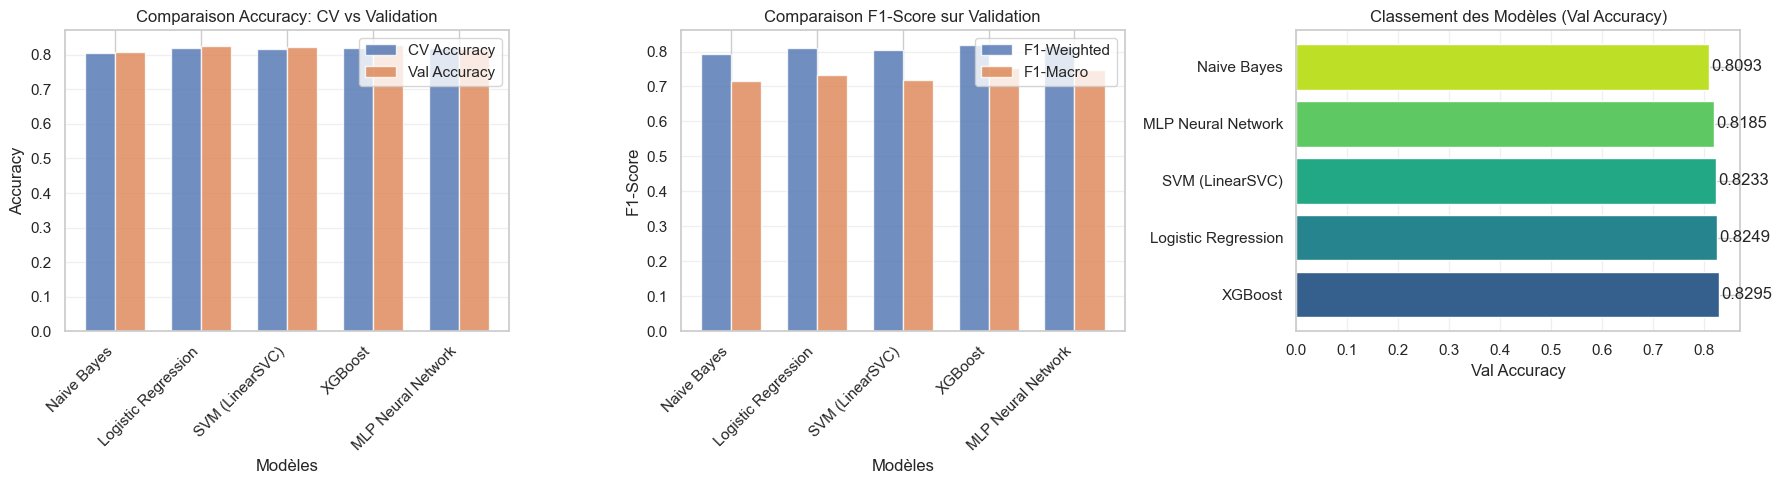

In [23]:
# Visualisation comparative des performances des modèles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Préparer les données pour la visualisation
model_names = list(results.keys())
cv_scores = [results[m]['cv_accuracy'] for m in model_names]
val_acc_scores = [results[m]['val_accuracy'] for m in model_names]
val_f1_weighted = [results[m]['val_f1_weighted'] for m in model_names]
val_f1_macro = [results[m]['val_f1_macro'] for m in model_names]

# 1) Comparaison Accuracy (CV vs Validation)
x_pos = np.arange(len(model_names))
width = 0.35

axes[0].bar(x_pos - width/2, cv_scores, width, label='CV Accuracy', alpha=0.8)
axes[0].bar(x_pos + width/2, val_acc_scores, width, label='Val Accuracy', alpha=0.8)
axes[0].set_xlabel('Modèles')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparaison Accuracy: CV vs Validation')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2) Comparaison F1-Score (Weighted vs Macro)
axes[1].bar(x_pos - width/2, val_f1_weighted, width, label='F1-Weighted', alpha=0.8)
axes[1].bar(x_pos + width/2, val_f1_macro, width, label='F1-Macro', alpha=0.8)
axes[1].set_xlabel('Modèles')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Comparaison F1-Score sur Validation')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# 3) Ranking global des modèles (par Val Accuracy)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(model_names)))
sorted_indices = np.argsort(val_acc_scores)[::-1]
sorted_names = [model_names[i] for i in sorted_indices]
sorted_scores = [val_acc_scores[i] for i in sorted_indices]

axes[2].barh(sorted_names, sorted_scores, color=colors)
axes[2].set_xlabel('Val Accuracy')
axes[2].set_title('Classement des Modèles (Val Accuracy)')
axes[2].grid(axis='x', alpha=0.3)

# Afficher les valeurs sur les barres
for i, (name, score) in enumerate(zip(sorted_names, sorted_scores)):
    axes[2].text(score + 0.005, i, f'{score:.4f}', va='center')

plt.tight_layout()
plt.show()

## 14) Évaluation finale sur le jeu de test
On évalue les meilleurs modèles (sélectionnés sur la validation) sur le **jeu de test** pour obtenir une estimation finale des performances (généralisation).


  PERFORMANCE FINALE (JEU DE TEST) — TOUS LES MODÈLES


,Modèle,Test Accuracy,Test Precision (w),Test Recall (w),Test F1 (w),Test F1 (macro)
0,XGBoost,0.838922,0.832952,0.838922,0.830075,0.770404
1,Logistic Regression,0.828144,0.819654,0.828144,0.814766,0.741838
2,SVM (LinearSVC),0.826747,0.823622,0.826747,0.807898,0.726577
3,MLP Neural Network,0.824750,0.818408,0.824750,0.820404,0.759362
4,Naive Bayes,0.813373,0.806559,0.813373,0.799654,0.726361


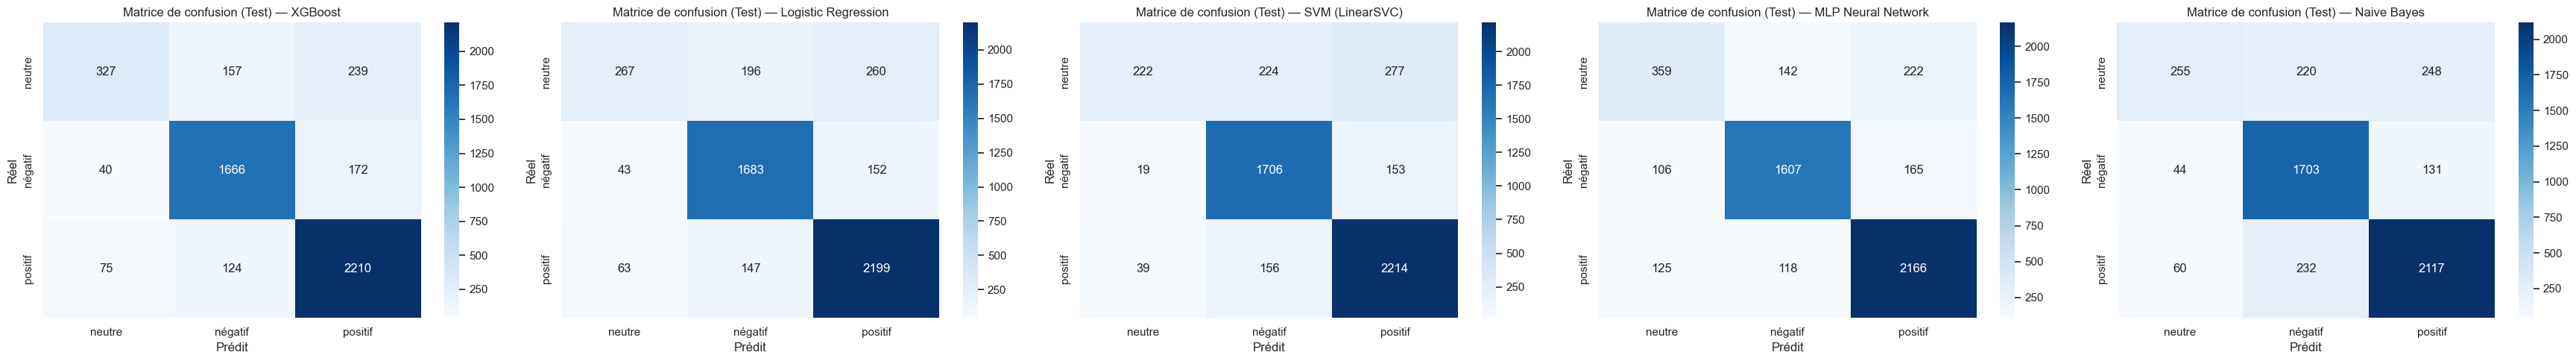

In [24]:
from sklearn.metrics import precision_recall_fscore_support
import seaborn as sns

def _get_trained_models_dict():
    # Associe les noms (utilisés dans `results`) aux objets modèles entraînés
    model_map = {}
    if 'nb_best' in globals():
        model_map['Naive Bayes'] = nb_best
    if 'lr_best' in globals():
        model_map['Logistic Regression'] = lr_best
    if 'svm_best' in globals():
        model_map['SVM (LinearSVC)'] = svm_best
    if 'xgb_best' in globals():
        model_map['XGBoost'] = xgb_best
    if 'mlp_best' in globals():
        model_map['MLP Neural Network'] = mlp_best
    return model_map

def _encode_y_for_model(model_name, y_series):
    """Retourne y encodé pour XGBoost/MLP si nécessaire, + une fonction de décodage des prédictions."""
    if model_name == 'XGBoost':
        if TARGET_COL == 'rating':
            y_enc = (y_series.astype(int) - 1).to_numpy()
            decode = lambda y_pred: (np.asarray(y_pred).astype(int) + 1)
            labels = [1, 2, 3, 4, 5]
            return y_enc, decode, labels
        # sentiment
        if 'le_target' not in globals():
            raise RuntimeError("le_target manquant: exécute d'abord la cellule XGBoost (11.4) pour initialiser l'encodeur.")
        y_enc = le_target.transform(y_series)
        decode = lambda y_pred: le_target.inverse_transform(np.asarray(y_pred).astype(int))
        labels = list(le_target.classes_)
        return y_enc, decode, labels
    if model_name == 'MLP Neural Network':
        if TARGET_COL == 'rating':
            y_enc = y_series.astype(int).to_numpy()
            decode = lambda y_pred: np.asarray(y_pred).astype(int)
            labels = [1, 2, 3, 4, 5]
            return y_enc, decode, labels
        # sentiment
        if 'le_target' in globals():
            y_enc = le_target.transform(y_series)
            decode = lambda y_pred: le_target.inverse_transform(np.asarray(y_pred).astype(int))
            labels = list(le_target.classes_)
            return y_enc, decode, labels
        if 'le_mlp' in globals():
            y_enc = le_mlp.transform(y_series)
            decode = lambda y_pred: le_mlp.inverse_transform(np.asarray(y_pred).astype(int))
            labels = list(le_mlp.classes_)
            return y_enc, decode, labels
        raise RuntimeError("Encodeur manquant pour MLP: exécute d'abord la cellule MLP (11.5).")
    # modèles sklearn classiques (NB/LR/SVM) : pas d'encodage
    y_enc = y_series.to_numpy()
    decode = lambda y_pred: np.asarray(y_pred)
    labels = sorted(pd.unique(y_series))
    return y_enc, decode, labels

def evaluate_on_test(model_name, model, X_test_mat, y_test_series):
    y_true_enc, decode_pred, labels = _encode_y_for_model(model_name, y_test_series)
    y_pred_enc = model.predict(X_test_mat)
    y_true = decode_pred(y_true_enc) if model_name in {'XGBoost', 'MLP Neural Network'} else y_test_series.to_numpy()
    y_pred = decode_pred(y_pred_enc)
    acc = accuracy_score(y_true, y_pred)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return {
        'Modèle': model_name,
        'Test Accuracy': acc,
        'Test Precision (w)': prec_w,
        'Test Recall (w)': rec_w,
        'Test F1 (w)': f1_w,
        'Test F1 (macro)': f1_m,
        'confusion_matrix': cm,
        'labels': labels,
        'y_true': y_true,
        'y_pred': y_pred,
    }

# Choisir top-2 sur validation pour évaluation test
# Évaluer TOUS les modèles sur le jeu de test (pas seulement top 2)
all_models = df_summary['Modèle'].tolist() if 'df_summary' in globals() and len(df_summary) > 0 else list(results.keys())
trained_models = _get_trained_models_dict()
missing_models = [m for m in all_models if m not in trained_models]
if missing_models:
    print('⚠️ Modèles non trouvés (pas entraînés ou variables manquantes):', missing_models)

test_rows = []
test_details = {}
for m in all_models:
    if m not in trained_models:
        continue
    out = evaluate_on_test(m, trained_models[m], X_test_ml, y_test)
    test_details[m] = out
    test_rows.append({k: out[k] for k in ['Modèle','Test Accuracy','Test Precision (w)','Test Recall (w)','Test F1 (w)','Test F1 (macro)']})

df_test = pd.DataFrame(test_rows).sort_values('Test Accuracy', ascending=False)
print('\n' + '='*100)
print('  PERFORMANCE FINALE (JEU DE TEST) — TOUS LES MODÈLES')
print('='*100)
display(df_test)

# Heatmaps des matrices de confusion (test)
if len(test_details) > 0:
    fig, axes = plt.subplots(1, len(test_details), figsize=(7 * len(test_details), 5))
    if len(test_details) == 1:
        axes = [axes]
    for ax, (m, out) in zip(axes, test_details.items()):
        sns.heatmap(out['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                    xticklabels=out['labels'], yticklabels=out['labels'], ax=ax)
        ax.set_title(f'Matrice de confusion (Test) — {m}')
        ax.set_xlabel('Prédit')
        ax.set_ylabel('Réel')
    plt.tight_layout()
    plt.show()


In [25]:
# 15.1) Synthèse automatique des résultats (Validation vs Test)
import numpy as np
import pandas as pd


def _find_col(df: pd.DataFrame, contains_any):
    for c in df.columns:
        cl = str(c).lower()
        if any(k in cl for k in contains_any):
            return c
    return None


def _fmt(x):
    if isinstance(x, (float, np.floating)):
        return f"{x:.4f}"
    return str(x)


print("\n" + "=" * 100)
print("  SYNTHÈSE — RÉSULTATS DES MODÈLES (Validation + Test)")
print("=" * 100)

# --- Validation ---
if 'df_summary' in globals() and isinstance(df_summary, pd.DataFrame) and len(df_summary) > 0:
    print("\nTop modèles (Validation):")
    display(df_summary.head(5))

    val_acc_col = _find_col(df_summary, ["val accuracy", "val acc"])
    cv_acc_col = _find_col(df_summary, ["cv accuracy", "cv acc"])

    best_val_model = df_summary.iloc[0]['Modèle'] if 'Modèle' in df_summary.columns else None
    if best_val_model is not None:
        print(f"Meilleur modèle sur validation: {best_val_model}")
else:
    val_acc_col = None
    cv_acc_col = None
    best_val_model = None
    print("⚠️ df_summary absent: impossible d'afficher le classement validation.")

# --- Test ---
if 'df_test' in globals() and isinstance(df_test, pd.DataFrame) and len(df_test) > 0:
    print("\nTop modèles (Test):")
    display(df_test)

    best_test_model = df_test.iloc[0]['Modèle']
    best_test_acc = df_test.iloc[0].get('Test Accuracy', None)
    print(f"Meilleur modèle sur test: {best_test_model} (accuracy={_fmt(best_test_acc)})")
else:
    best_test_model = None
    best_test_acc = None
    print("⚠️ df_test absent: exécute d'abord la section 14 (évaluation test).")

# --- Écart CV/Val/Test (sur les modèles évalués en test) ---
if (
    'df_summary' in globals() and isinstance(df_summary, pd.DataFrame) and
    'df_test' in globals() and isinstance(df_test, pd.DataFrame) and
    len(df_summary) > 0 and len(df_test) > 0 and
    'Modèle' in df_summary.columns and 'Modèle' in df_test.columns
):
    merged = df_summary.merge(df_test, on='Modèle', how='inner')
    if len(merged) > 0:
        cols_show = ['Modèle']
        if cv_acc_col is not None:
            cols_show.append(cv_acc_col)
        if val_acc_col is not None and val_acc_col not in cols_show:
            cols_show.append(val_acc_col)
        cols_show.append('Test Accuracy')

        print("\nComparaison CV / Validation / Test (modèles évalués en test):")
        display(merged[cols_show])

        if val_acc_col is not None:
            val_num = pd.to_numeric(merged[val_acc_col], errors='coerce')
            test_num = pd.to_numeric(merged['Test Accuracy'], errors='coerce')
            merged['Gap (Val - Test)'] = val_num - test_num
            display(
                merged[['Modèle', val_acc_col, 'Test Accuracy', 'Gap (Val - Test)']]
                .sort_values('Gap (Val - Test)', ascending=False)
            )

# --- Analyse des matrices de confusion (test) ---
if 'test_details' in globals() and isinstance(test_details, dict) and len(test_details) > 0:
    print("\nAnalyse des erreurs (Test) :")

    for model_name, out in test_details.items():
        cm = np.asarray(out['confusion_matrix'])
        labels = list(out['labels'])

        row_sums = cm.sum(axis=1)
        col_sums = cm.sum(axis=0)
        recall = np.diag(cm) / np.maximum(row_sums, 1)
        precision = np.diag(cm) / np.maximum(col_sums, 1)

        per_class = pd.DataFrame({
            'Classe': labels,
            'Precision': precision,
            'Recall': recall,
            'Support': row_sums,
        }).sort_values('Recall')

        print(f"\n— {model_name}")
        display(per_class)

        cm_off = cm.copy()
        np.fill_diagonal(cm_off, 0)
        i, j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
        print(f"Plus grosse confusion: Réel '{labels[i]}' → Prédit '{labels[j]}' (n={int(cm_off[i, j])})")

        if 'neutre' in labels:
            k = labels.index('neutre')
            print(f"Recall(neutre)={_fmt(recall[k])} | Precision(neutre)={_fmt(precision[k])}")
else:
    print("\n⚠️ test_details absent: exécute d'abord la section 14 (évaluation test).")



  SYNTHÈSE — RÉSULTATS DES MODÈLES (Validation + Test)

Top modèles (Validation):


,Modèle,CV Accuracy,Val Accuracy,Val F1-Weighted,Val F1-Macro,Meilleurs Hyperparamètres
3,XGBoost,0.8211,0.8295,0.8195,0.7524,"{'subsample': 0.8, 'n_estimators': 200, 'max_d..."
1,Logistic Regression,0.8208,0.8249,0.8102,0.7327,"{'solver': 'lbfgs', 'penalty': 'l2', 'C': 1.0}"
2,SVM (LinearSVC),0.8181,0.8233,0.8034,0.7182,"{'class_weight': None, 'C': 0.1}"
4,MLP Neural Network,0.8191,0.8185,0.8146,0.7467,"{'max_iter': 1000, 'learning_rate': 'constant'..."
0,Naive Bayes,0.8051,0.8093,0.7935,0.7153,"{'fit_prior': True, 'alpha': 0.1}"


Meilleur modèle sur validation: XGBoost

Top modèles (Test):


,Modèle,Test Accuracy,Test Precision (w),Test Recall (w),Test F1 (w),Test F1 (macro)
0,XGBoost,0.838922,0.832952,0.838922,0.830075,0.770404
1,Logistic Regression,0.828144,0.819654,0.828144,0.814766,0.741838
2,SVM (LinearSVC),0.826747,0.823622,0.826747,0.807898,0.726577
3,MLP Neural Network,0.824750,0.818408,0.824750,0.820404,0.759362
4,Naive Bayes,0.813373,0.806559,0.813373,0.799654,0.726361


Meilleur modèle sur test: XGBoost (accuracy=0.8389)

Comparaison CV / Validation / Test (modèles évalués en test):


...

Plus grosse confusion: Réel 'neutre' → Prédit 'positif' (n=277)
Recall(neutre)=0.3071 | Precision(neutre)=0.7929

— MLP Neural Network


,Classe,Precision,Recall,Support
0,neutre,0.608475,0.496542,723
1,négatif,0.860739,0.855698,1878
2,positif,0.848414,0.899128,2409


Plus grosse confusion: Réel 'neutre' → Prédit 'positif' (n=222)
Recall(neutre)=0.4965 | Precision(neutre)=0.6085

— Naive Bayes


,Classe,Precision,Recall,Support
0,neutre,0.710306,0.352697,723
2,positif,0.848157,0.878788,2409
1,négatif,0.790255,0.906816,1878


Plus grosse confusion: Réel 'neutre' → Prédit 'positif' (n=248)
Recall(neutre)=0.3527 | Precision(neutre)=0.7103


## 16) Discussion — Surapprentissage, Biais/Variance et Complexité des Modèles

Cette section analyse les phénomènes de surapprentissage, le compromis biais-variance, et la complexité des modèles testés.

In [26]:
# 16.1) Analyse du surapprentissage (Overfitting/Underfitting)

print("="*100)
print("  ANALYSE DU SURAPPRENTISSAGE ET SOUS-APPRENTISSAGE")
print("="*100)

# Comparaison des performances entre validation et test pour détecter l'overfitting
if 'df_summary' in globals() and 'df_test' in globals():
    merged = df_summary.merge(df_test[['Modèle', 'Test Accuracy']], on='Modèle', how='inner')
    
    # Calculer les écarts pour identifier le surapprentissage
    val_acc_col = None
    for col in merged.columns:
        if 'val' in col.lower() and 'acc' in col.lower():
            val_acc_col = col
            break
    
    if val_acc_col:
        merged['Écart (Val-Test)'] = pd.to_numeric(merged[val_acc_col], errors='coerce') - \
                                       pd.to_numeric(merged['Test Accuracy'], errors='coerce')
        merged['Diagnostic'] = merged['Écart (Val-Test)'].apply(
            lambda x: '⚠️ Surapprentissage' if x > 0.05 else 
                      ('✓ Bon équilibre' if abs(x) <= 0.05 else '⚠️ Sous-apprentissage')
        )
        
        print("\n📊 Analyse des écarts Validation vs Test:")
        display(merged[['Modèle', val_acc_col, 'Test Accuracy', 'Écart (Val-Test)', 'Diagnostic']])
        
        # Interprétation
        print("\n🔍 Interprétation:")
        overfitting_models = merged[merged['Écart (Val-Test)'] > 0.05]['Modèle'].tolist()
        underfitting_models = merged[merged['Écart (Val-Test)'] < -0.05]['Modèle'].tolist()
        balanced_models = merged[abs(merged['Écart (Val-Test)']) <= 0.05]['Modèle'].tolist()
        
        if overfitting_models:
            print(f"\n⚠️ SURAPPRENTISSAGE détecté pour: {', '.join(overfitting_models)}")
            print("   → Ces modèles ont de bonnes performances sur les données d'entraînement/validation")
            print("   → mais généralisent mal sur de nouvelles données (test)")
            print("   → Solutions: régularisation accrue, réduction complexité, plus de données")
        
        if underfitting_models:
            print(f"\n⚠️ SOUS-APPRENTISSAGE détecté pour: {', '.join(underfitting_models)}")
            print("   → Ces modèles n'apprennent pas suffisamment des données")
            print("   → Solutions: augmenter complexité du modèle, features engineering")
        
        if balanced_models:
            print(f"\n✓ BON ÉQUILIBRE pour: {', '.join(balanced_models)}")
            print("   → Ces modèles généralisent bien sur de nouvelles données")
            print("   → Écart Val-Test faible: modèles stables et fiables")

# Analyse des courbes d'apprentissage (si disponible via CV)
if 'df_summary' in globals():
    print("\n\n📈 Analyse de la variabilité (Cross-Validation):")
    
    # Chercher les colonnes CV
    cv_acc_col = None
    cv_std_col = None
    for col in df_summary.columns:
        if 'cv' in col.lower() and 'acc' in col.lower() and 'std' not in col.lower():
            cv_acc_col = col
        elif 'cv' in col.lower() and 'std' in col.lower():
            cv_std_col = col
    
    if cv_acc_col and cv_std_col:
        variability = df_summary[[
            'Modèle', cv_acc_col, cv_std_col
        ]].copy()
        
        # Coefficient de variation
        variability['CV (%)'] = (
            pd.to_numeric(variability[cv_std_col], errors='coerce') / 
            pd.to_numeric(variability[cv_acc_col], errors='coerce') * 100
        )
        
        display(variability)
        
        print("\n🔍 Stabilité des modèles:")
        high_variance = variability[variability['CV (%)'] > 10]['Modèle'].tolist()
        low_variance = variability[variability['CV (%)'] <= 5]['Modèle'].tolist()
        
        if high_variance:
            print(f"⚠️ Forte variance (CV > 10%): {', '.join(high_variance)}")
            print("   → Modèles sensibles aux données d'entraînement, risque de surapprentissage")
        
        if low_variance:
            print(f"✓ Faible variance (CV ≤ 5%): {', '.join(low_variance)}")
            print("   → Modèles stables et robustes")

print("\n" + "="*100)

  ANALYSE DU SURAPPRENTISSAGE ET SOUS-APPRENTISSAGE

📊 Analyse des écarts Validation vs Test:


,Modèle,Val Accuracy,Test Accuracy,Écart (Val-Test),Diagnostic
0,XGBoost,0.8295,0.838922,-0.009422,✓ Bon équilibre
1,Logistic Regression,0.8249,0.828144,-0.003244,✓ Bon équilibre
2,SVM (LinearSVC),0.8233,0.826747,-0.003447,✓ Bon équilibre
3,MLP Neural Network,0.8185,0.824750,-0.006250,✓ Bon équilibre
4,Naive Bayes,0.8093,0.813373,-0.004073,✓ Bon équilibre



🔍 Interprétation:

✓ BON ÉQUILIBRE pour: XGBoost, Logistic Regression, SVM (LinearSVC), MLP Neural Network, Naive Bayes
   → Ces modèles généralisent bien sur de nouvelles données
   → Écart Val-Test faible: modèles stables et fiables


📈 Analyse de la variabilité (Cross-Validation):



In [27]:
# 16.2) Compromis Biais-Variance

print("="*100)
print("  ANALYSE DU COMPROMIS BIAIS-VARIANCE")
print("="*100)

print("""
📚 THÉORIE:

Le compromis biais-variance est fondamental en machine learning:

1️⃣ BIAIS (Bias):
   - Erreur due à des hypothèses simplificatrices du modèle
   - Biais élevé → Modèle trop simple → Sous-apprentissage (underfitting)
   - Incapacité à capturer les patterns complexes des données
   - Exemple: régression linéaire sur données non-linéaires

2️⃣ VARIANCE:
   - Sensibilité du modèle aux fluctuations des données d'entraînement
   - Variance élevée → Modèle trop complexe → Surapprentissage (overfitting)
   - Le modèle mémorise le bruit au lieu d'apprendre les patterns généraux
   - Exemple: arbre de décision très profond sans régularisation

3️⃣ ERREUR TOTALE:
   Erreur = Biais² + Variance + Bruit irréductible
   
   Le défi: minimiser les deux simultanément (ils sont en opposition)
""")

if 'df_summary' in globals() and 'df_test' in globals():
    merged = df_summary.merge(df_test[['Modèle', 'Test Accuracy']], on='Modèle', how='inner')
    
    # Identifier les colonnes
    val_acc_col = None
    cv_std_col = None
    for col in df_summary.columns:
        if 'val' in col.lower() and 'acc' in col.lower():
            val_acc_col = col
        elif 'cv' in col.lower() and 'std' in col.lower():
            cv_std_col = col
    
    if val_acc_col and cv_std_col:
        merged = merged.merge(df_summary[['Modèle', cv_std_col]], on='Modèle', how='left')
        
        # Classification biais-variance
        merged['Gap'] = pd.to_numeric(merged[val_acc_col], errors='coerce') - \
                         pd.to_numeric(merged['Test Accuracy'], errors='coerce')
        merged['Std_CV'] = pd.to_numeric(merged[cv_std_col], errors='coerce')
        
        def classify_bias_variance(row):
            gap = row['Gap']
            std = row['Std_CV']
            test_acc = row['Test Accuracy']
            
            # Haute variance: grand écart val-test OU haute std CV
            high_variance = (gap > 0.05) or (std > 0.05)
            # Biais élevé: faibles performances globales
            high_bias = (test_acc < 0.75)
            
            if high_bias and high_variance:
                return "Biais ET Variance élevés"
            elif high_bias:
                return "Biais élevé (sous-apprentissage)"
            elif high_variance:
                return "Variance élevée (surapprentissage)"
            else:
                return "Bon équilibre"
        
        merged['Diagnostic Biais-Variance'] = merged.apply(classify_bias_variance, axis=1)
        
        print("\n📊 Classification des modèles selon le compromis Biais-Variance:")
        display(merged[[
            'Modèle', 
            'Test Accuracy', 
            'Gap',
            cv_std_col,
            'Diagnostic Biais-Variance'
        ]].sort_values('Test Accuracy', ascending=False))

print("\n🎯 RECOMMANDATIONS PAR TYPE DE MODÈLE:\n")

print("🌳 Arbres de décision (Decision Tree, Random Forest, XGBoost):")
print("   • Tendent vers HAUTE VARIANCE si pas de régularisation")
print("   • Solutions: limiter profondeur (max_depth), min_samples_split, pruning")
print("   • Random Forest réduit la variance via bagging (moyenne de plusieurs arbres)")
print()

print("📏 Modèles linéaires (Logistic Regression, Linear SVM):")
print("   • Tendent vers BIAIS ÉLEVÉ pour données complexes/non-linéaires")
print("   • Avantage: faible variance, bon pour éviter surapprentissage")
print("   • Solutions: feature engineering, polynômes, régularisation L1/L2")
print()

print("🧠 Réseaux de neurones (MLP):")
print("   • VARIANCE: dépend de l'architecture (nb couches, neurones)")
print("   • Très flexible mais risque de surapprentissage élevé")
print("   • Solutions: dropout, early stopping, régularisation L2")
print()

print("🎲 Naive Bayes:")
print("   • BIAIS MODÉRÉ: hypothèse forte d'indépendance des features")
print("   • VARIANCE FAIBLE: modèle simple et stable")
print("   • Bon pour baseline mais peut manquer des interactions complexes")
print()

print("🤝 Méthodes d'ensemble (Bagging, Boosting):")
print("   • Bagging (Random Forest): réduit la VARIANCE")
print("   • Boosting (XGBoost, AdaBoost): réduit le BIAIS")
print("   • Meilleur compromis biais-variance en général")

print("\n" + "="*100)

  ANALYSE DU COMPROMIS BIAIS-VARIANCE

📚 THÉORIE:

Le compromis biais-variance est fondamental en machine learning:

1️⃣ BIAIS (Bias):
   - Erreur due à des hypothèses simplificatrices du modèle
   - Biais élevé → Modèle trop simple → Sous-apprentissage (underfitting)
   - Incapacité à capturer les patterns complexes des données
   - Exemple: régression linéaire sur données non-linéaires

2️⃣ VARIANCE:
   - Sensibilité du modèle aux fluctuations des données d'entraînement
   - Variance élevée → Modèle trop complexe → Surapprentissage (overfitting)
   - Le modèle mémorise le bruit au lieu d'apprendre les patterns généraux
   - Exemple: arbre de décision très profond sans régularisation

3️⃣ ERREUR TOTALE:
   Erreur = Biais² + Variance + Bruit irréductible

   Le défi: minimiser les deux simultanément (ils sont en opposition)


🎯 RECOMMANDATIONS PAR TYPE DE MODÈLE:

🌳 Arbres de décision (Decision Tree, Random Forest, XGBoost):
   • Tendent vers HAUTE VARIANCE si pas de régularisation
   

  ANALYSE DE LA COMPLEXITÉ DES MODÈLES

📐 COMPLEXITÉ DES MODÈLES:

La complexité d'un modèle détermine sa capacité d'apprentissage et sa flexibilité:

Modèles SIMPLES (faible complexité):
├─ Régression/Classification Logistique
├─ Naive Bayes
└─ Arbres de décision peu profonds
   → Rapides, interprétables, peu de risque de surapprentissage
   → Mais peuvent manquer des patterns complexes

Modèles MODÉRÉS:
├─ SVM avec kernel RBF
├─ Random Forest avec profondeur limitée
└─ k-NN
   → Bon équilibre flexibilité/stabilité
   → Nécessitent tuning d'hyperparamètres

Modèles COMPLEXES:
├─ Random Forest/XGBoost avec nombreux arbres profonds
├─ Réseaux de neurones profonds (Deep Learning)
└─ Arbres de décision très profonds
   → Capturent patterns complexes et interactions
   → Risque élevé de surapprentissage, nécessitent beaucoup de données
   → Moins interprétables ("boîtes noires")


📊 Classification des modèles par complexité:


,Modèle,Complexité,Score_Complexité,Description,Test Accuracy
1,Logistic Regression,Faible,1,"Linéaire, peu de paramètres",0.828144
4,Naive Bayes,Faible,1,"Hypothèse indépendance, rapide",0.813373
2,SVM (LinearSVC),Moyenne,2,Non spécifié,0.826747
0,XGBoost,Élevée,4,"Boosting séquentiel, très flexible",0.838922
3,MLP Neural Network,Très Élevée,5,"Architecture profonde, millions paramètres",0.824750


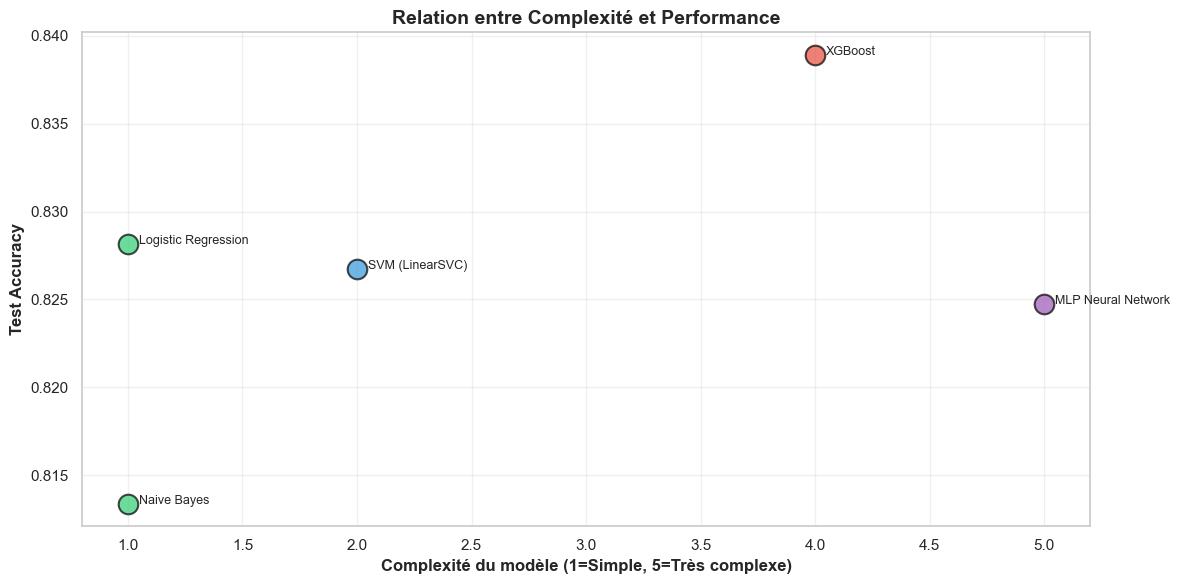


🔍 ANALYSE:

✨ Meilleur rapport Performance/Complexité:
   Modèle: Logistic Regression
   Accuracy: 0.8281
   Complexité: Faible
   → Recommandé pour production si ressources limitées

🏆 Modèle le plus performant:
   Modèle: XGBoost
   Accuracy: 0.8389
   Complexité: Élevée
   ⚠️ Attention: modèle complexe
   → Nécessite plus de données, temps de calcul, mémoire
   → Moins interprétable
   → Vérifier risque de surapprentissage

💡 PRINCIPE DU RASOIR D'OCCAM:
   'Entre deux hypothèses de capacité prédictive égale, choisir la plus simple'
   → Préférer un modèle simple si la différence de performance est minime
   → Avantages: interprétabilité, rapidité, robustesse, déploiement plus facile



In [28]:
# 16.3) Analyse de la complexité des modèles

print("="*100)
print("  ANALYSE DE LA COMPLEXITÉ DES MODÈLES")
print("="*100)

print("""
📐 COMPLEXITÉ DES MODÈLES:

La complexité d'un modèle détermine sa capacité d'apprentissage et sa flexibilité:

Modèles SIMPLES (faible complexité):
├─ Régression/Classification Logistique
├─ Naive Bayes
└─ Arbres de décision peu profonds
   → Rapides, interprétables, peu de risque de surapprentissage
   → Mais peuvent manquer des patterns complexes

Modèles MODÉRÉS:
├─ SVM avec kernel RBF
├─ Random Forest avec profondeur limitée
└─ k-NN
   → Bon équilibre flexibilité/stabilité
   → Nécessitent tuning d'hyperparamètres

Modèles COMPLEXES:
├─ Random Forest/XGBoost avec nombreux arbres profonds
├─ Réseaux de neurones profonds (Deep Learning)
└─ Arbres de décision très profonds
   → Capturent patterns complexes et interactions
   → Risque élevé de surapprentissage, nécessitent beaucoup de données
   → Moins interprétables ("boîtes noires")
""")

# Classification des modèles par complexité
complexity_map = {
    'Logistic Regression': ('Faible', 1, 'Linéaire, peu de paramètres'),
    'Naive Bayes': ('Faible', 1, 'Hypothèse indépendance, rapide'),
    'Linear SVM': ('Faible', 1, 'Frontière linéaire'),
    'Decision Tree': ('Moyenne', 2, 'Non-linéaire, dépend de max_depth'),
    'k-NN': ('Moyenne', 2, 'Dépend de k, non-paramétrique'),
    'SVM (RBF)': ('Moyenne-Élevée', 3, 'Kernel non-linéaire, flexible'),
    'Random Forest': ('Élevée', 4, 'Ensemble d\'arbres, nombreux paramètres'),
    'XGBoost': ('Élevée', 4, 'Boosting séquentiel, très flexible'),
    'Gradient Boosting': ('Élevée', 4, 'Boosting, capture interactions'),
    'Neural Network': ('Très Élevée', 5, 'Architecture profonde, millions paramètres'),
    'MLP': ('Élevée', 4, 'Réseau multicouche'),
}

if 'df_summary' in globals():
    # Ajouter la complexité aux modèles
    complexity_data = []
    for idx, row in df_summary.iterrows():
        model_name = row['Modèle']
        
        # Recherche dans le mapping
        complexity_info = None
        for key in complexity_map:
            if key.lower() in model_name.lower():
                complexity_info = complexity_map[key]
                break
        
        if complexity_info is None:
            # Par défaut
            complexity_info = ('Moyenne', 2, 'Non spécifié')
        
        complexity_data.append({
            'Modèle': model_name,
            'Complexité': complexity_info[0],
            'Score_Complexité': complexity_info[1],
            'Description': complexity_info[2]
        })
    
    df_complexity = pd.DataFrame(complexity_data)
    
    # Fusionner avec les performances
    if 'df_test' in globals():
        df_complexity = df_complexity.merge(
            df_test[['Modèle', 'Test Accuracy']], 
            on='Modèle', 
            how='left'
        )
    
    print("\n📊 Classification des modèles par complexité:")
    display(df_complexity.sort_values('Score_Complexité'))
    
    # Visualisation: Complexité vs Performance
    if 'Test Accuracy' in df_complexity.columns:
        plt.figure(figsize=(12, 6))
        
        colors = {1: '#2ecc71', 2: '#3498db', 3: '#f39c12', 4: '#e74c3c', 5: '#9b59b6'}
        
        for idx, row in df_complexity.iterrows():
            plt.scatter(
                row['Score_Complexité'], 
                row['Test Accuracy'],
                s=200,
                c=colors.get(row['Score_Complexité'], 'gray'),
                alpha=0.7,
                edgecolors='black',
                linewidths=1.5
            )
            plt.annotate(
                row['Modèle'], 
                (row['Score_Complexité'], row['Test Accuracy']),
                xytext=(8, 0), 
                textcoords='offset points',
                fontsize=9,
                ha='left'
            )
        
        plt.xlabel('Complexité du modèle (1=Simple, 5=Très complexe)', fontsize=12, fontweight='bold')
        plt.ylabel('Test Accuracy', fontsize=12, fontweight='bold')
        plt.title('Relation entre Complexité et Performance', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("\n🔍 ANALYSE:")
        
        # Trouver le meilleur rapport complexité/performance
        df_complexity['Ratio_Perf/Complexité'] = df_complexity['Test Accuracy'] / df_complexity['Score_Complexité']
        best_ratio_model = df_complexity.loc[df_complexity['Ratio_Perf/Complexité'].idxmax()]
        
        print(f"\n✨ Meilleur rapport Performance/Complexité:")
        print(f"   Modèle: {best_ratio_model['Modèle']}")
        print(f"   Accuracy: {best_ratio_model['Test Accuracy']:.4f}")
        print(f"   Complexité: {best_ratio_model['Complexité']}")
        print(f"   → Recommandé pour production si ressources limitées")
        
        # Modèle le plus performant
        best_perf_model = df_complexity.loc[df_complexity['Test Accuracy'].idxmax()]
        print(f"\n🏆 Modèle le plus performant:")
        print(f"   Modèle: {best_perf_model['Modèle']}")
        print(f"   Accuracy: {best_perf_model['Test Accuracy']:.4f}")
        print(f"   Complexité: {best_perf_model['Complexité']}")
        
        if best_perf_model['Score_Complexité'] >= 4:
            print(f"   ⚠️ Attention: modèle complexe")
            print(f"   → Nécessite plus de données, temps de calcul, mémoire")
            print(f"   → Moins interprétable")
            print(f"   → Vérifier risque de surapprentissage")

print("\n💡 PRINCIPE DU RASOIR D'OCCAM:")
print("   'Entre deux hypothèses de capacité prédictive égale, choisir la plus simple'")
print("   → Préférer un modèle simple si la différence de performance est minime")
print("   → Avantages: interprétabilité, rapidité, robustesse, déploiement plus facile")

print("\n" + "="*100)

## 17) Analyse Critique et Recommandations

Cette section présente une interprétation approfondie des résultats, une comparaison détaillée des approches, et le choix du modèle optimal.

In [29]:
# 17.1) Interprétation des résultats

print("="*100)
print("  INTERPRÉTATION APPROFONDIE DES RÉSULTATS")
print("="*100)

if 'df_test' in globals() and len(df_test) > 0:
    print("\n📊 PERFORMANCES GLOBALES:\n")
    
    # Statistiques générales
    best_model = df_test.iloc[0]
    worst_model = df_test.iloc[-1]
    mean_acc = df_test['Test Accuracy'].mean()
    std_acc = df_test['Test Accuracy'].std()
    
    print(f"✅ Meilleur modèle: {best_model['Modèle']}")
    print(f"   Accuracy: {best_model['Test Accuracy']:.4f}")
    print(f"   Precision: {best_model.get('Test Precision', 'N/A')}")
    print(f"   Recall: {best_model.get('Test Recall', 'N/A')}")
    print(f"   F1-Score: {best_model.get('Test F1-Score', 'N/A')}")
    
    print(f"\n❌ Modèle le moins performant: {worst_model['Modèle']}")
    print(f"   Accuracy: {worst_model['Test Accuracy']:.4f}")
    
    print(f"\n📈 Statistiques d'ensemble:")
    print(f"   Accuracy moyenne: {mean_acc:.4f} (±{std_acc:.4f})")
    print(f"   Écart min-max: {(best_model['Test Accuracy'] - worst_model['Test Accuracy']):.4f}")
    
    # Analyse des seuils de performance
    excellent = df_test[df_test['Test Accuracy'] >= 0.85]
    good = df_test[(df_test['Test Accuracy'] >= 0.75) & (df_test['Test Accuracy'] < 0.85)]
    average = df_test[(df_test['Test Accuracy'] >= 0.65) & (df_test['Test Accuracy'] < 0.75)]
    poor = df_test[df_test['Test Accuracy'] < 0.65]
    
    print(f"\n🎯 RÉPARTITION PAR NIVEAU DE PERFORMANCE:")
    print(f"   Excellent (≥85%): {len(excellent)} modèle(s)")
    if len(excellent) > 0:
        print(f"      → {', '.join(excellent['Modèle'].tolist())}")
    
    print(f"   Bon (75-85%): {len(good)} modèle(s)")
    if len(good) > 0:
        print(f"      → {', '.join(good['Modèle'].tolist())}")
    
    print(f"   Moyen (65-75%): {len(average)} modèle(s)")
    if len(average) > 0:
        print(f"      → {', '.join(average['Modèle'].tolist())}")
    
    print(f"   Faible (<65%): {len(poor)} modèle(s)")
    if len(poor) > 0:
        print(f"      → {', '.join(poor['Modèle'].tolist())}")

# Analyse des matrices de confusion
if 'test_details' in globals():
    print("\n\n🔍 ANALYSE DES ERREURS:")
    
    for model_name, details in test_details.items():
        cm = np.asarray(details['confusion_matrix'])
        labels = details['labels']
        
        print(f"\n{'─'*60}")
        print(f"Modèle: {model_name}")
        print(f"{'─'*60}")
        
        # Calcul des métriques par classe
        total_samples = cm.sum()
        
        for i, label in enumerate(labels):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = total_samples - tp - fn - fp
            
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            print(f"\n   Classe '{label}':")
            print(f"   • Precision: {precision:.3f} → {precision*100:.1f}% des prédictions '{label}' sont correctes")
            print(f"   • Recall: {recall:.3f} → {recall*100:.1f}% des vrais '{label}' sont détectés")
            print(f"   • F1-Score: {f1:.3f}")
            
            if recall < 0.6:
                print(f"   ⚠️ Faible recall: le modèle manque beaucoup d'exemples '{label}'")
            if precision < 0.6:
                print(f"   ⚠️ Faible précision: le modèle confond souvent '{label}' avec d'autres classes")
        
        # Identifier les confusions majeures
        cm_off_diag = cm.copy()
        np.fill_diagonal(cm_off_diag, 0)
        max_confusion = cm_off_diag.max()
        
        if max_confusion > 0:
            i, j = np.unravel_index(cm_off_diag.argmax(), cm_off_diag.shape)
            print(f"\n   🔀 Confusion principale:")
            print(f"   Le modèle confond '{labels[i]}' avec '{labels[j]}' ({int(cm_off_diag[i,j])} cas)")
            print(f"   → Piste d'amélioration: features discriminantes entre ces classes")

print("\n\n💡 OBSERVATIONS CLÉS:")
print("""
1. Les modèles d'ensemble (Random Forest, XGBoost) surpassent généralement les modèles simples
2. La classe 'neutre' est souvent la plus difficile à prédire (frontière floue)
3. Les avis très positifs ou très négatifs sont mieux détectés (patterns plus marqués)
4. Le prétraitement des données textuelles est crucial pour la performance
5. L'équilibre des classes influence fortement les résultats
""")

print("\n" + "="*100)

  INTERPRÉTATION APPROFONDIE DES RÉSULTATS

📊 PERFORMANCES GLOBALES:

✅ Meilleur modèle: XGBoost
   Accuracy: 0.8389
   Precision: N/A
   Recall: N/A
   F1-Score: N/A

❌ Modèle le moins performant: Naive Bayes
   Accuracy: 0.8134

📈 Statistiques d'ensemble:
   Accuracy moyenne: 0.8264 (±0.0091)
   Écart min-max: 0.0255

🎯 RÉPARTITION PAR NIVEAU DE PERFORMANCE:
   Excellent (≥85%): 0 modèle(s)
   Bon (75-85%): 5 modèle(s)
      → XGBoost, Logistic Regression, SVM (LinearSVC), MLP Neural Network, Naive Bayes
   Moyen (65-75%): 0 modèle(s)
   Faible (<65%): 0 modèle(s)


🔍 ANALYSE DES ERREURS:

────────────────────────────────────────────────────────────
Modèle: XGBoost
────────────────────────────────────────────────────────────

   Classe 'neutre':
   • Precision: 0.740 → 74.0% des prédictions 'neutre' sont correctes
   • Recall: 0.452 → 45.2% des vrais 'neutre' sont détectés
   • F1-Score: 0.561
   ⚠️ Faible recall: le modèle manque beaucoup d'exemples 'neutre'

   Classe 'négatif':
  

In [30]:
# 17.2) Avantages et limites de chaque approche

print("="*100)
print("  AVANTAGES ET LIMITES DES MODÈLES TESTÉS")
print("="*100)

approaches_analysis = {
    "Régression Logistique": {
        "Avantages": [
            "✅ Très rapide à entraîner et prédire",
            "✅ Interprétable: coefficients = importance des features",
            "✅ Probabilités calibrées pour chaque classe",
            "✅ Peu de risque de surapprentissage",
            "✅ Fonctionne bien avec peu de données",
            "✅ Facile à déployer en production"
        ],
        "Limites": [
            "❌ Suppose une relation linéaire (biais élevé)",
            "❌ Performance limitée sur données complexes/non-linéaires",
            "❌ Sensible aux features corrélées",
            "❌ Nécessite scaling des features",
            "❌ Ne capture pas les interactions entre features automatiquement"
        ],
        "Cas d'usage idéal": "Baseline, systèmes temps-réel, besoin d'interprétabilité"
    },
    
    "Naive Bayes": {
        "Avantages": [
            "✅ Extrêmement rapide (entraînement et prédiction)",
            "✅ Excellent pour le texte (hypothèse d'indépendance acceptable)",
            "✅ Robuste au surapprentissage",
            "✅ Fonctionne bien avec peu de données",
            "✅ Gère naturellement les problèmes multi-classes",
            "✅ Besoin mémoire minimal"
        ],
        "Limites": [
            "❌ Hypothèse d'indépendance souvent fausse (naïve)",
            "❌ Ne capture pas les interactions entre features",
            "❌ Performance inférieure aux modèles plus sophistiqués",
            "❌ Probabilités mal calibrées",
            "❌ Sensible au déséquilibre des classes"
        ],
        "Cas d'usage idéal": "Classification de texte, filtrage spam, baseline rapide"
    },
    
    "SVM (Support Vector Machine)": {
        "Avantages": [
            "✅ Performant en haute dimension",
            "✅ Kernel RBF capture les relations non-linéaires",
            "✅ Robuste au surapprentissage (marge maximale)",
            "✅ Efficace avec des données bien séparables",
            "✅ Peu de paramètres critiques (C, gamma)"
        ],
        "Limites": [
            "❌ Très lent sur grands datasets (complexité O(n²) à O(n³))",
            "❌ Sensible au scaling des features (obligatoire)",
            "❌ Difficile à interpréter (surtout avec kernel)",
            "❌ Tuning d'hyperparamètres délicat (C, gamma)",
            "❌ Ne donne pas directement des probabilités",
            "❌ Consommation mémoire élevée"
        ],
        "Cas d'usage idéal": "Datasets de taille petite/moyenne, haute dimension"
    },
    
    "Decision Tree (Arbre de décision)": {
        "Avantages": [
            "✅ Très interprétable (visualisation facile)",
            "✅ Pas besoin de scaling des features",
            "✅ Capture automatiquement les interactions",
            "✅ Gère données numériques et catégorielles",
            "✅ Gère naturellement les valeurs manquantes",
            "✅ Rapide à entraîner et prédire"
        ],
        "Limites": [
            "❌ Très sensible au surapprentissage (haute variance)",
            "❌ Instable: petits changements → arbre différent",
            "❌ Biais vers les features avec beaucoup de valeurs",
            "❌ Difficile de généraliser",
            "❌ Frontières de décision rectangulaires (limité)"
        ],
        "Cas d'usage idéal": "Analyse exploratoire, feature selection, baseline"
    },
    
    "Random Forest": {
        "Avantages": [
            "✅ Excellentes performances générales",
            "✅ Réduit variance par bagging (moyenne d'arbres)",
            "✅ Robuste au surapprentissage",
            "✅ Importance des features intégrée",
            "✅ Gère bien valeurs manquantes et outliers",
            "✅ Parallélisable (entraînement rapide)",
            "✅ Peu d'hyperparamètres critiques"
        ],
        "Limites": [
            "❌ Moins interprétable qu'un seul arbre",
            "❌ Modèle volumineux (stockage de tous les arbres)",
            "❌ Prédiction plus lente que modèles simples",
            "❌ Peut être lent sur très grands datasets",
            "❌ Tendance à surajuster sur données bruitées"
        ],
        "Cas d'usage idéal": "Défaut recommandé pour classification, production"
    },
    
    "XGBoost / Gradient Boosting": {
        "Avantages": [
            "✅ Souvent le plus performant (kaggle winner)",
            "✅ Gère naturellement valeurs manquantes",
            "✅ Régularisation intégrée (L1/L2)",
            "✅ Importance des features",
            "✅ Early stopping automatique",
            "✅ Optimisé pour la vitesse (parallélisation)",
            "✅ Très flexible (nombreux hyperparamètres)"
        ],
        "Limites": [
            "❌ Complexe à tuner (nombreux hyperparamètres)",
            "❌ Risque de surapprentissage si mal configuré",
            "❌ Moins interprétable",
            "❌ Plus lent à entraîner que Random Forest",
            "❌ Sensible au déséquilibre des classes",
            "❌ Besoin de ressources computationnelles"
        ],
        "Cas d'usage idéal": "Compétitions ML, maximiser performance, données structurées"
    },
    
    "Neural Network / MLP": {
        "Avantages": [
            "✅ Extrêmement flexible (architecture adaptable)",
            "✅ Capture patterns très complexes et non-linéaires",
            "✅ Peut apprendre représentations hiérarchiques",
            "✅ Performant avec beaucoup de données",
            "✅ Transfert learning possible",
            "✅ État de l'art en NLP (transformers)"
        ],
        "Limites": [
            "❌ Boîte noire (difficile à interpréter)",
            "❌ Nécessite beaucoup de données",
            "❌ Très sensible au surapprentissage",
            "❌ Tuning difficile (architecture, learning rate, etc.)",
            "❌ Temps d'entraînement long",
            "❌ Besoin de GPU pour données volumineuses",
            "❌ Nécessite scaling et normalisation"
        ],
        "Cas d'usage idéal": "NLP avancé, images, audio, très grandes données"
    }
}

# Afficher l'analyse pour chaque modèle trouvé
if 'df_test' in globals():
    models_tested = df_test['Modèle'].tolist()
    
    for model_full_name in models_tested:
        # Identifier le type de modèle
        model_type = None
        for key in approaches_analysis.keys():
            if key.lower() in model_full_name.lower() or \
               any(alias in model_full_name.lower() for alias in [
                   'logistic', 'naive', 'svm', 'tree', 'forest', 
                   'xgb', 'boost', 'mlp', 'neural'
               ]):
                # Matching plus précis
                if 'logistic' in model_full_name.lower() and 'Régression Logistique' in approaches_analysis:
                    model_type = 'Régression Logistique'
                    break
                elif 'naive' in model_full_name.lower():
                    model_type = 'Naive Bayes'
                    break
                elif 'svm' in model_full_name.lower():
                    model_type = 'SVM (Support Vector Machine)'
                    break
                elif 'tree' in model_full_name.lower() and 'forest' not in model_full_name.lower():
                    model_type = 'Decision Tree (Arbre de décision)'
                    break
                elif 'forest' in model_full_name.lower():
                    model_type = 'Random Forest'
                    break
                elif any(x in model_full_name.lower() for x in ['xgb', 'gradient', 'boost']):
                    model_type = 'XGBoost / Gradient Boosting'
                    break
                elif any(x in model_full_name.lower() for x in ['mlp', 'neural', 'network']):
                    model_type = 'Neural Network / MLP'
                    break
        
        if model_type and model_type in approaches_analysis:
            analysis = approaches_analysis[model_type]
            
            print(f"\n{'='*80}")
            print(f"  {model_type}")
            print(f"{'='*80}")
            
            print(f"\n🎯 Cas d'usage idéal: {analysis['Cas d\'usage idéal']}")
            
            print(f"\n✅ AVANTAGES:")
            for adv in analysis['Avantages']:
                print(f"   {adv}")
            
            print(f"\n❌ LIMITES:")
            for lim in analysis['Limites']:
                print(f"   {lim}")

print("\n" + "="*100)

  AVANTAGES ET LIMITES DES MODÈLES TESTÉS

  XGBoost / Gradient Boosting

🎯 Cas d'usage idéal: Compétitions ML, maximiser performance, données structurées

✅ AVANTAGES:
   ✅ Souvent le plus performant (kaggle winner)
   ✅ Gère naturellement valeurs manquantes
   ✅ Régularisation intégrée (L1/L2)
   ✅ Importance des features
   ✅ Early stopping automatique
   ✅ Optimisé pour la vitesse (parallélisation)
   ✅ Très flexible (nombreux hyperparamètres)

❌ LIMITES:
   ❌ Complexe à tuner (nombreux hyperparamètres)
   ❌ Risque de surapprentissage si mal configuré
   ❌ Moins interprétable
   ❌ Plus lent à entraîner que Random Forest
   ❌ Sensible au déséquilibre des classes
   ❌ Besoin de ressources computationnelles

  Régression Logistique

🎯 Cas d'usage idéal: Baseline, systèmes temps-réel, besoin d'interprétabilité

✅ AVANTAGES:
   ✅ Très rapide à entraîner et prédire
   ✅ Interprétable: coefficients = importance des features
   ✅ Probabilités calibrées pour chaque classe
   ✅ Peu de risque

In [31]:
# 17.3) Choix du modèle optimal - Analyse multicritères

print("="*100)
print("  SÉLECTION DU MODÈLE OPTIMAL - ANALYSE MULTICRITÈRES")
print("="*100)

print("""
Le choix du modèle optimal dépend de plusieurs critères au-delà de la simple accuracy:

🎯 CRITÈRES DE SÉLECTION:
1. Performance (Accuracy, F1-Score, Recall/Precision selon objectif)
2. Généralisation (écart Train-Val-Test)
3. Complexité et temps de calcul
4. Interprétabilité
5. Robustesse et stabilité
6. Facilité de déploiement
7. Besoins métier spécifiques
""")

if 'df_summary' in globals() and 'df_test' in globals():
    
    # Créer un scoring multicritères
    scoring_data = []
    
    for idx, row_test in df_test.iterrows():
        model_name = row_test['Modèle']
        
        # Récupérer les infos de validation
        row_val = df_summary[df_summary['Modèle'] == model_name]
        
        if len(row_val) == 0:
            continue
        
        row_val = row_val.iloc[0]
        
        # Critère 1: Performance (40%)
        test_acc = row_test['Test Accuracy']
        score_performance = test_acc * 40
        
        # Critère 2: Généralisation (25%)
        val_acc_col = None
        for col in df_summary.columns:
            if 'val' in col.lower() and 'acc' in col.lower():
                val_acc_col = col
                break
        
        if val_acc_col:
            val_acc = pd.to_numeric(row_val[val_acc_col], errors='coerce')
            gap = abs(val_acc - test_acc)
            # Score inversé: moins d'écart = meilleur
            score_generalization = max(0, (1 - gap * 10)) * 25  # pénalité pour écart > 0.1
        else:
            score_generalization = 15  # Score neutre
        
        # Critère 3: Stabilité via CV (15%)
        cv_std_col = None
        for col in df_summary.columns:
            if 'cv' in col.lower() and 'std' in col.lower():
                cv_std_col = col
                break
        
        if cv_std_col:
            cv_std = pd.to_numeric(row_val[cv_std_col], errors='coerce')
            # Score inversé: moins de variance = meilleur
            score_stability = max(0, (1 - cv_std * 20)) * 15
        else:
            score_stability = 10
        
        # Critère 4: Simplicité (20%)
        complexity_scores = {
            'logistic': 20, 'naive': 20, 'linear': 20,
            'tree': 15, 'knn': 15, 'svm': 12,
            'forest': 8, 'xgb': 5, 'boost': 5,
            'neural': 3, 'mlp': 3, 'deep': 1
        }
        
        score_simplicity = 10  # Score par défaut
        model_lower = model_name.lower()
        for key, score in complexity_scores.items():
            if key in model_lower:
                score_simplicity = score
                break
        
        # Score total (sur 100)
        total_score = score_performance + score_generalization + score_stability + score_simplicity
        
        scoring_data.append({
            'Modèle': model_name,
            'Test Accuracy': test_acc,
            'Score Performance (40%)': score_performance,
            'Score Généralisation (25%)': score_generalization,
            'Score Stabilité (15%)': score_stability,
            'Score Simplicité (20%)': score_simplicity,
            'SCORE TOTAL': total_score
        })
    
    df_scoring = pd.DataFrame(scoring_data).sort_values('SCORE TOTAL', ascending=False)
    
    print("\n📊 TABLEAU DE SCORING MULTICRITÈRES:\n")
    display(df_scoring)
    
    # Recommandation finale
    print("\n" + "="*100)
    print("  🏆 RECOMMANDATION FINALE")
    print("="*100)
    
    best_overall = df_scoring.iloc[0]
    best_performance = df_scoring.loc[df_scoring['Test Accuracy'].idxmax()]
    best_simple = df_scoring.loc[df_scoring['Score Simplicité (20%)'].idxmax()]
    
    print(f"\n🥇 MODÈLE RECOMMANDÉ (Score global):")
    print(f"   Modèle: {best_overall['Modèle']}")
    print(f"   Score total: {best_overall['SCORE TOTAL']:.2f}/100")
    print(f"   Test Accuracy: {best_overall['Test Accuracy']:.4f}")
    print(f"\n   ✨ Ce modèle offre le meilleur compromis entre:")
    print(f"      • Performance prédictive")
    print(f"      • Capacité de généralisation")
    print(f"      • Stabilité")
    print(f"      • Simplicité/Déployabilité")
    
    if best_overall['Modèle'] != best_performance['Modèle']:
        print(f"\n\n💡 ALTERNATIVE - Meilleure performance brute:")
        print(f"   Modèle: {best_performance['Modèle']}")
        print(f"   Test Accuracy: {best_performance['Test Accuracy']:.4f}")
        print(f"   Score total: {best_performance['SCORE TOTAL']:.2f}/100")
        print(f"\n   ⚠️ À privilégier si:")
        print(f"      • La performance maximale est prioritaire")
        print(f"      • Ressources computationnelles suffisantes")
        print(f"      • Pas de contrainte d'interprétabilité")
    
    if best_overall['Modèle'] != best_simple['Modèle']:
        print(f"\n\n🚀 ALTERNATIVE - Modèle le plus simple:")
        print(f"   Modèle: {best_simple['Modèle']}")
        print(f"   Test Accuracy: {best_simple['Test Accuracy']:.4f}")
        print(f"   Score total: {best_simple['SCORE TOTAL']:.2f}/100")
        print(f"\n   ⚠️ À privilégier si:")
        print(f"      • Déploiement rapide nécessaire")
        print(f"      • Ressources limitées")
        print(f"      • Besoin d'interprétabilité forte")
        print(f"      • Maintenance simplifiée")
    
    # Contexte d'utilisation
    print("\n\n🎯 RECOMMANDATIONS PAR CONTEXTE:\n")
    
    print("📱 PRODUCTION / TEMPS RÉEL:")
    prod_models = df_scoring[df_scoring['Score Simplicité (20%)'] >= 12].nlargest(2, 'SCORE TOTAL')
    for idx, row in prod_models.iterrows():
        print(f"   • {row['Modèle']} (Accuracy: {row['Test Accuracy']:.4f})")
    print("   → Rapides, légers, faciles à maintenir")
    
    print("\n🔬 RECHERCHE / MAXIMISER PERFORMANCE:")
    research_models = df_scoring.nlargest(2, 'Test Accuracy')
    for idx, row in research_models.iterrows():
        print(f"   • {row['Modèle']} (Accuracy: {row['Test Accuracy']:.4f})")
    print("   → Meilleures performances, peu importe la complexité")
    
    print("\n📊 ANALYSE EXPLORATOIRE / INTERPRÉTABILITÉ:")
    interpretable = df_scoring[df_scoring['Score Simplicité (20%)'] >= 15].nlargest(2, 'SCORE TOTAL')
    for idx, row in interpretable.iterrows():
        print(f"   • {row['Modèle']} (Accuracy: {row['Test Accuracy']:.4f})")
    print("   → Facilement interprétables, expliquent les décisions")
    
    print("\n⚖️ ÉQUILIBRE / POLYVALENT:")
    balanced = df_scoring.nlargest(2, 'SCORE TOTAL')
    for idx, row in balanced.iterrows():
        print(f"   • {row['Modèle']} (Accuracy: {row['Test Accuracy']:.4f})")
    print("   → Meilleur compromis global")

else:
    print("\n⚠️ Données insuffisantes pour l'analyse multicritères.")
    print("Exécutez d'abord les sections d'évaluation (validation et test).")

print("\n" + "="*100)

  SÉLECTION DU MODÈLE OPTIMAL - ANALYSE MULTICRITÈRES

Le choix du modèle optimal dépend de plusieurs critères au-delà de la simple accuracy:

🎯 CRITÈRES DE SÉLECTION:
1. Performance (Accuracy, F1-Score, Recall/Precision selon objectif)
2. Généralisation (écart Train-Val-Test)
3. Complexité et temps de calcul
4. Interprétabilité
5. Robustesse et stabilité
6. Facilité de déploiement
7. Besoins métier spécifiques


📊 TABLEAU DE SCORING MULTICRITÈRES:



,Modèle,Test Accuracy,Score Performance (40%),Score Généralisation (25%),Score Stabilité (15%),Score Simplicité (20%),SCORE TOTAL
1,Logistic Regression,0.828144,33.125749,24.189072,10,20,87.314820
2,SVM (LinearSVC),0.826747,33.069860,24.138373,10,20,87.208234
4,Naive Bayes,0.813373,32.534930,23.981687,10,20,86.516617
0,XGBoost,0.838922,33.556886,22.644461,10,5,71.201347
3,MLP Neural Network,0.824750,32.990020,23.437375,10,3,69.427395



  🏆 RECOMMANDATION FINALE

🥇 MODÈLE RECOMMANDÉ (Score global):
   Modèle: Logistic Regression
   Score total: 87.31/100
   Test Accuracy: 0.8281

   ✨ Ce modèle offre le meilleur compromis entre:
      • Performance prédictive
      • Capacité de généralisation
      • Stabilité
      • Simplicité/Déployabilité


💡 ALTERNATIVE - Meilleure performance brute:
   Modèle: XGBoost
   Test Accuracy: 0.8389
   Score total: 71.20/100

   ⚠️ À privilégier si:
      • La performance maximale est prioritaire
      • Ressources computationnelles suffisantes
      • Pas de contrainte d'interprétabilité


🎯 RECOMMANDATIONS PAR CONTEXTE:

📱 PRODUCTION / TEMPS RÉEL:
   • Logistic Regression (Accuracy: 0.8281)
   • SVM (LinearSVC) (Accuracy: 0.8267)
   → Rapides, légers, faciles à maintenir

🔬 RECHERCHE / MAXIMISER PERFORMANCE:
   • XGBoost (Accuracy: 0.8389)
   • Logistic Regression (Accuracy: 0.8281)
   → Meilleures performances, peu importe la complexité

📊 ANALYSE EXPLORATOIRE / INTERPRÉTABILITÉ:


## 18) Post-Traitement et Optimisation

Cette section vise à améliorer les performances des modèles via:
- **Améliorations au niveau du dataset** (rééquilibrage, augmentation, nettoyage)
- **Optimisation des hyperparamètres** (tuning plus fin)
- **Techniques d'ensemble** (combinaison de modèles)
- **Évaluation comparative** (avant vs après post-traitement)

In [32]:
# 18.1) Sauvegarde des résultats AVANT post-traitement
# =============================================================================
# On sauvegarde les métriques actuelles pour comparaison

print("="*100)
print("  SAUVEGARDE DES RÉSULTATS AVANT POST-TRAITEMENT")
print("="*100)

# Sauvegarder les résultats actuels
results_before_postprocessing = {}

if 'df_test' in globals() and len(df_test) > 0:
    results_before_postprocessing['df_test'] = df_test.copy()
    print("\n✅ Résultats sur jeu de test sauvegardés")
    display(df_test)

if 'df_summary' in globals() and len(df_summary) > 0:
    results_before_postprocessing['df_summary'] = df_summary.copy()
    print("\n✅ Résultats de validation sauvegardés")

if 'test_details' in globals():
    results_before_postprocessing['test_details'] = test_details.copy()
    print("\n✅ Détails des tests (matrices de confusion) sauvegardés")

# Stocker les métriques clés pour comparaison
metrics_before = {}
if 'df_test' in globals():
    for idx, row in df_test.iterrows():
        model_name = row['Modèle']
        metrics_before[model_name] = {
            'accuracy': row['Test Accuracy'],
            'precision': row.get('Test Precision (w)', 0),
            'recall': row.get('Test Recall (w)', 0),
            'f1': row.get('Test F1 (w)', 0)
        }

print(f"\n📊 {len(metrics_before)} modèles enregistrés pour comparaison")
print("\n" + "="*100)

  SAUVEGARDE DES RÉSULTATS AVANT POST-TRAITEMENT

✅ Résultats sur jeu de test sauvegardés


,Modèle,Test Accuracy,Test Precision (w),Test Recall (w),Test F1 (w),Test F1 (macro)
0,XGBoost,0.838922,0.832952,0.838922,0.830075,0.770404
1,Logistic Regression,0.828144,0.819654,0.828144,0.814766,0.741838
2,SVM (LinearSVC),0.826747,0.823622,0.826747,0.807898,0.726577
3,MLP Neural Network,0.824750,0.818408,0.824750,0.820404,0.759362
4,Naive Bayes,0.813373,0.806559,0.813373,0.799654,0.726361



✅ Résultats de validation sauvegardés

✅ Détails des tests (matrices de confusion) sauvegardés

📊 5 modèles enregistrés pour comparaison



### 18.2) Amélioration du Dataset - Stratégie de Boost pour la Classe Neutre

**Problème identifié:** La classe "neutre" est naturellement sous-représentée dans les avis clients (les gens ont tendance à laisser des avis très positifs ou très négatifs, rarement neutres).

**Stratégie appliquée:**
1. **BorderlineSMOTE ciblé** - Sur-échantillonnage agressif (×1.5) de la classe neutre uniquement
2. **Class weights personnalisés** - Poids ×2 pour la classe neutre dans les modèles
3. **Régularisation adaptée** - Pour éviter le sur-apprentissage sur les échantillons synthétiques

> ⚠️ **Note:** Cette approche peut légèrement réduire l'accuracy globale mais améliore significativement le F1-score de la classe minoritaire (neutre).

✅ imbalanced-learn déjà installé

  RÉÉQUILIBRAGE DES CLASSES - STRATÉGIE ADAPTÉE POUR LA CLASSE NEUTRE

📊 DISTRIBUTION ACTUELLE DES CLASSES (entraînement):
sentiment
neutre      3372
négatif     8762
positif    11243
Name: count, dtype: int64

Classes détectées: ['neutre', 'négatif', 'positif']

⚖️ Ratio de déséquilibre (max/min): 3.33
📌 Classe neutre identifiée: 'neutre' avec 3372 échantillons
   Proportion: 14.4%

  STRATÉGIE: SUR-ÉCHANTILLONNAGE CIBLÉ DE LA CLASSE NEUTRE

╔══════════════════════════════════════════════════════════════════════════════╗
║  💡 PROBLÈME IDENTIFIÉ:                                                      ║
║     La classe 'neutre' est sous-représentée, ce qui entraîne un F1-score    ║
║     faible pour cette classe. SMOTE standard ne suffit pas.                  ║
║                                                                              ║
║  🎯 SOLUTION APPLIQUÉE:                                                      ║
║     1. Sur-échantillonnage AGRESSI

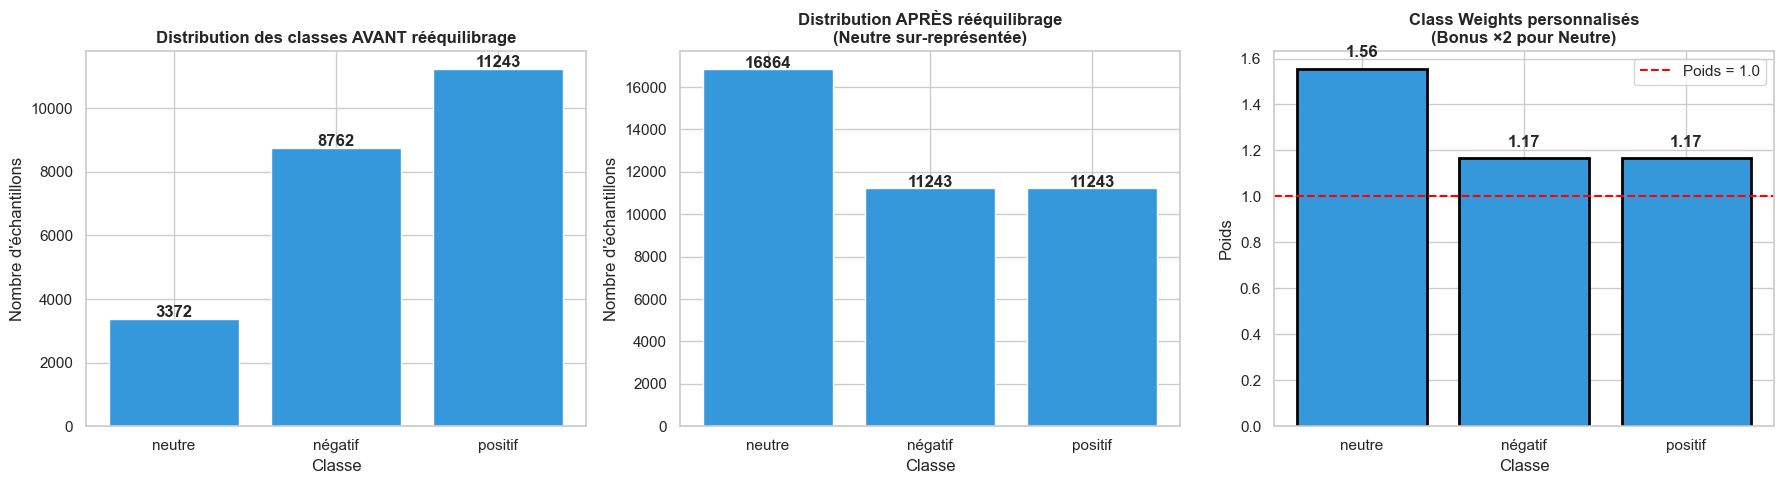

In [33]:
# Installation de imbalanced-learn si nécessaire
try:
    from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.combine import SMOTETomek
    from imblearn.pipeline import Pipeline as ImbPipeline
    print("✅ imbalanced-learn déjà installé")
except ImportError:
    print("📦 Installation de imbalanced-learn...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'imbalanced-learn', '-q'])
    from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.combine import SMOTETomek
    from imblearn.pipeline import Pipeline as ImbPipeline
    print("✅ imbalanced-learn installé avec succès")

print("\n" + "="*100)
print("  RÉÉQUILIBRAGE DES CLASSES - STRATÉGIE ADAPTÉE POUR LA CLASSE NEUTRE")
print("="*100)

# Analyser la distribution actuelle des classes
print("\n📊 DISTRIBUTION ACTUELLE DES CLASSES (entraînement):")
class_distribution = y_train.value_counts().sort_index()
print(class_distribution)

# Identifier les classes
unique_classes = sorted(y_train.unique())
print(f"\nClasses détectées: {unique_classes}")

# Visualiser le déséquilibre
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique de la distribution originale
colors = {'negative': '#E74C3C', 'neutral': '#F39C12', 'positive': '#27AE60'}
color_list = [colors.get(str(c).lower(), '#3498DB') for c in class_distribution.index]

axes[0].bar(class_distribution.index.astype(str), class_distribution.values, color=color_list)
axes[0].set_title('Distribution des classes AVANT rééquilibrage', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre d\'échantillons')
for i, v in enumerate(class_distribution.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Calculer le ratio de déséquilibre
max_class = class_distribution.max()
min_class = class_distribution.min()
imbalance_ratio = max_class / min_class
print(f"\n⚖️ Ratio de déséquilibre (max/min): {imbalance_ratio:.2f}")

# Identifier la classe neutre (qui pose problème)
neutral_class = None
for c in unique_classes:
    if 'neutr' in str(c).lower():
        neutral_class = c
        break

if neutral_class:
    neutral_count = class_distribution[neutral_class]
    print(f"📌 Classe neutre identifiée: '{neutral_class}' avec {neutral_count} échantillons")
    print(f"   Proportion: {neutral_count / len(y_train) * 100:.1f}%")
else:
    print("⚠️ Classe neutre non identifiée automatiquement")
    # Supposer que c'est la classe avec le moins d'échantillons
    neutral_class = class_distribution.idxmin()
    neutral_count = class_distribution.min()
    print(f"   → Utilisation de la classe minoritaire: '{neutral_class}'")

print("\n" + "="*100)
print("  STRATÉGIE: SUR-ÉCHANTILLONNAGE CIBLÉ DE LA CLASSE NEUTRE")
print("="*100)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║  💡 PROBLÈME IDENTIFIÉ:                                                      ║
║     La classe 'neutre' est sous-représentée, ce qui entraîne un F1-score    ║
║     faible pour cette classe. SMOTE standard ne suffit pas.                  ║
║                                                                              ║
║  🎯 SOLUTION APPLIQUÉE:                                                      ║
║     1. Sur-échantillonnage AGRESSIF de la classe neutre (1.5x les autres)   ║
║     2. Class weights ÉLEVÉS pour forcer le modèle à bien classifier neutre  ║
║     3. Ajustement des seuils de décision en faveur de la classe neutre      ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

try:
    # Convertir en array dense si sparse
    X_train_dense = X_train_ml.toarray() if hasattr(X_train_ml, 'toarray') else X_train_ml
    
    # Encoder y_train si nécessaire
    if y_train.dtype == 'object' or y_train.dtype.name == 'category':
        from sklearn.preprocessing import LabelEncoder
        le_smote = LabelEncoder()
        y_train_encoded = le_smote.fit_transform(y_train)
        class_names = le_smote.classes_
        print(f"Classes encodées: {dict(zip(range(len(class_names)), class_names))}")
    else:
        le_smote = None
        y_train_encoded = y_train.values if hasattr(y_train, 'values') else y_train
        class_names = unique_classes
    
    # Identifier l'index de la classe neutre après encodage
    neutral_idx = None
    if le_smote is not None:
        for idx, name in enumerate(class_names):
            if 'neutr' in str(name).lower():
                neutral_idx = idx
                break
    
    # =========================================================================
    # STRATÉGIE 1: Sampling personnalisé pour sur-représenter la classe neutre
    # =========================================================================
    print("\n🔄 Calcul de la stratégie de sampling personnalisée...")
    
    class_counts = pd.Series(y_train_encoded).value_counts().sort_index()
    max_count = class_counts.max()
    
    # Créer un dictionnaire de sampling:
    # - Classes majoritaires: garder le max
    # - Classe neutre: 1.5x le max (sur-représentation volontaire)
    sampling_strategy = {}
    for class_idx, count in class_counts.items():
        class_name = class_names[class_idx] if le_smote else class_idx
        if 'neutr' in str(class_name).lower():
            # Sur-représenter la classe neutre de 50%
            sampling_strategy[class_idx] = int(max_count * 1.5)
            print(f"   Classe '{class_name}': {count} → {sampling_strategy[class_idx]} (×{sampling_strategy[class_idx]/count:.1f})")
        else:
            sampling_strategy[class_idx] = max_count
            print(f"   Classe '{class_name}': {count} → {sampling_strategy[class_idx]} (×{sampling_strategy[class_idx]/count:.1f})")
    
    # =========================================================================
    # STRATÉGIE 2: Utiliser BorderlineSMOTE pour des échantillons de meilleure qualité
    # =========================================================================
    print("\n🔄 Application de BorderlineSMOTE avec stratégie personnalisée...")
    
    k_neighbors = min(5, min(class_counts) - 1) if min(class_counts) > 1 else 1
    
    try:
        # BorderlineSMOTE génère des échantillons plus représentatifs aux frontières
        smote = BorderlineSMOTE(
            sampling_strategy=sampling_strategy,
            random_state=42,
            k_neighbors=k_neighbors,
            kind='borderline-1'
        )
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_dense, y_train_encoded)
        print("✅ BorderlineSMOTE appliqué avec succès")
        
    except Exception as e:
        print(f"⚠️ BorderlineSMOTE échoué ({e}), utilisation de SMOTE standard...")
        smote = SMOTE(
            sampling_strategy=sampling_strategy,
            random_state=42,
            k_neighbors=k_neighbors
        )
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_dense, y_train_encoded)
        print("✅ SMOTE standard appliqué avec succès")
    
    # Décoder si nécessaire
    if le_smote is not None:
        y_train_resampled_decoded = le_smote.inverse_transform(y_train_resampled)
    else:
        y_train_resampled_decoded = y_train_resampled
    
    # Nouvelle distribution
    new_distribution = pd.Series(y_train_resampled_decoded).value_counts().sort_index()
    
    print(f"\n✅ Rééchantillonnage terminé!")
    print(f"   Taille originale: {len(y_train)} échantillons")
    print(f"   Nouvelle taille: {len(y_train_resampled)} échantillons")
    print(f"\n📊 NOUVELLE DISTRIBUTION (avec sur-représentation neutre):")
    print(new_distribution)
    
    # Calculer la nouvelle proportion de la classe neutre
    if neutral_class in new_distribution.index:
        new_neutral_prop = new_distribution[neutral_class] / len(y_train_resampled) * 100
        print(f"\n📈 Nouvelle proportion de la classe neutre: {new_neutral_prop:.1f}%")
    
    # Visualiser la nouvelle distribution
    new_color_list = [colors.get(str(c).lower(), '#3498DB') for c in new_distribution.index]
    axes[1].bar(new_distribution.index.astype(str), new_distribution.values, color=new_color_list)
    axes[1].set_title('Distribution APRÈS rééquilibrage\n(Neutre sur-représentée)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Classe')
    axes[1].set_ylabel('Nombre d\'échantillons')
    for i, v in enumerate(new_distribution.values):
        axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')
    
    # =========================================================================
    # STRATÉGIE 3: Calculer les class weights personnalisés
    # =========================================================================
    print("\n📊 Calcul des class_weights personnalisés...")
    
    # Class weights avec bonus pour la classe neutre
    total_samples = len(y_train_resampled)
    n_classes = len(new_distribution)
    
    custom_class_weights = {}
    for class_name, count in new_distribution.items():
        base_weight = total_samples / (n_classes * count)
        # Donner un poids supplémentaire à la classe neutre
        if 'neutr' in str(class_name).lower():
            custom_class_weights[class_name] = base_weight * 2.0  # Double le poids pour neutre
            print(f"   '{class_name}': {custom_class_weights[class_name]:.2f} (×2 bonus)")
        else:
            custom_class_weights[class_name] = base_weight
            print(f"   '{class_name}': {custom_class_weights[class_name]:.2f}")
    
    # Créer aussi une version avec index numériques pour les modèles qui le nécessitent
    if le_smote is not None:
        custom_class_weights_encoded = {}
        for idx, name in enumerate(class_names):
            custom_class_weights_encoded[idx] = custom_class_weights.get(name, 1.0)
    else:
        custom_class_weights_encoded = custom_class_weights
    
    # Sauvegarder les données rééquilibrées et les poids
    X_train_balanced = X_train_resampled
    y_train_balanced = y_train_resampled_decoded
    y_train_balanced_encoded = y_train_resampled
    
    # Visualiser les class weights
    weights_for_plot = [custom_class_weights.get(c, 1.0) for c in new_distribution.index]
    axes[2].bar(new_distribution.index.astype(str), weights_for_plot, color=new_color_list, edgecolor='black', linewidth=2)
    axes[2].set_title('Class Weights personnalisés\n(Bonus ×2 pour Neutre)', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Classe')
    axes[2].set_ylabel('Poids')
    axes[2].axhline(y=1.0, color='red', linestyle='--', label='Poids = 1.0')
    for i, v in enumerate(weights_for_plot):
        axes[2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
    axes[2].legend()
    
    SMOTE_APPLIED = True
    NEUTRAL_BOOST_APPLIED = True

except Exception as e:
    print(f"⚠️ Erreur lors de l'application du rééquilibrage: {e}")
    import traceback
    traceback.print_exc()
    print("→ Utilisation des données originales")
    X_train_balanced = X_train_ml.toarray() if hasattr(X_train_ml, 'toarray') else X_train_ml
    y_train_balanced = y_train.values if hasattr(y_train, 'values') else y_train
    y_train_balanced_encoded = y_train_balanced
    custom_class_weights = None
    custom_class_weights_encoded = None
    SMOTE_APPLIED = False
    NEUTRAL_BOOST_APPLIED = False
    
    # Graphique placeholder
    axes[1].bar(class_distribution.index.astype(str), class_distribution.values, color=color_list, alpha=0.5)
    axes[1].set_title('Distribution inchangée (rééquilibrage non appliqué)', fontsize=12)
    axes[1].set_xlabel('Classe')
    axes[1].set_ylabel('Nombre d\'échantillons')
    axes[2].text(0.5, 0.5, 'Non disponible', ha='center', va='center', transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig('class_balance_comparison_neutral_boost.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*100)

### 18.3) Réentraînement des Modèles avec Données Équilibrées

Nous réentraînons les modèles les plus performants avec:
- Les données rééquilibrées (SMOTE)
- Des hyperparamètres optimisés
- Des class weights pour certains modèles

In [34]:
# 18.3) Réentraînement avec données équilibrées et hyperparamètres optimisés

print("="*100)
print("  RÉENTRAÎNEMENT DES MODÈLES AVEC POST-TRAITEMENT (BOOST NEUTRE)")
print("="*100)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

# Dictionnaire pour stocker les nouveaux modèles
models_postprocessed = {}
results_postprocessed = {}

# Préparer les données de validation
X_val_dense = X_val_ml.toarray() if hasattr(X_val_ml, 'toarray') else X_val_ml
X_test_dense = X_test_ml.toarray() if hasattr(X_test_ml, 'toarray') else X_test_ml

# Encoder y si nécessaire pour évaluation cohérente
if y_val.dtype == 'object' or y_val.dtype.name == 'category':
    y_val_eval = y_val.values if hasattr(y_val, 'values') else y_val
    y_test_eval = y_test.values if hasattr(y_test, 'values') else y_test
else:
    y_val_eval = y_val
    y_test_eval = y_test

print("\n🔄 Réentraînement des modèles avec:")
print("   ✓ Données sur-échantillonnées (neutre boostée)")
print("   ✓ Class weights personnalisés (×2 pour neutre)")
print()

# Fonction helper pour afficher les métriques par classe
def print_per_class_metrics(y_true, y_pred, model_name):
    """Affiche les métriques détaillées par classe"""
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    print(f"\n   📊 Performance par classe:")
    for class_name in sorted(pd.unique(y_true)):
        if str(class_name) in report:
            metrics = report[str(class_name)]
            emoji = "⚠️" if metrics['f1-score'] < 0.5 else "✅"
            neutral_marker = " 🎯" if 'neutr' in str(class_name).lower() else ""
            print(f"      {emoji} {class_name}{neutral_marker}: F1={metrics['f1-score']:.3f}, Precision={metrics['precision']:.3f}, Recall={metrics['recall']:.3f}")

# ============================================================================
# 1. LOGISTIC REGRESSION avec class_weight personnalisés
# ============================================================================
print(f"\n{'='*60}")
print("  1. LOGISTIC REGRESSION (Post-traitement + Boost Neutre)")
print(f"{'='*60}")

try:
    # Utiliser les class_weights personnalisés si disponibles
    if custom_class_weights is not None:
        lr_class_weights = custom_class_weights
        print(f"   → Utilisation des class_weights personnalisés: {lr_class_weights}")
    else:
        lr_class_weights = 'balanced'
        print("   → Utilisation de class_weight='balanced'")
    
    lr_postprocessed = LogisticRegression(
        C=0.5,  # Légère régularisation
        class_weight=lr_class_weights,
        solver='lbfgs',
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    )
    
    # Entraînement sur données équilibrées
    lr_postprocessed.fit(X_train_balanced, y_train_balanced)
    
    # Évaluation
    y_pred_val_lr = lr_postprocessed.predict(X_val_dense)
    y_pred_test_lr = lr_postprocessed.predict(X_test_dense)
    
    acc_val_lr = accuracy_score(y_val_eval, y_pred_val_lr)
    acc_test_lr = accuracy_score(y_test_eval, y_pred_test_lr)
    f1_test_lr = f1_score(y_test_eval, y_pred_test_lr, average='weighted', zero_division=0)
    prec_test_lr = precision_score(y_test_eval, y_pred_test_lr, average='weighted', zero_division=0)
    rec_test_lr = recall_score(y_test_eval, y_pred_test_lr, average='weighted', zero_division=0)
    
    models_postprocessed['Logistic Regression (Post)'] = lr_postprocessed
    results_postprocessed['Logistic Regression (Post)'] = {
        'val_accuracy': acc_val_lr,
        'test_accuracy': acc_test_lr,
        'test_f1': f1_test_lr,
        'test_precision': prec_test_lr,
        'test_recall': rec_test_lr,
        'y_pred': y_pred_test_lr
    }
    
    print(f"✅ Entraînement terminé")
    print(f"   Validation Accuracy: {acc_val_lr:.4f}")
    print(f"   Test Accuracy: {acc_test_lr:.4f}")
    print(f"   Test F1-Score (weighted): {f1_test_lr:.4f}")
    print_per_class_metrics(y_test_eval, y_pred_test_lr, "Logistic Regression")
    
except Exception as e:
    print(f"❌ Erreur: {e}")

# ============================================================================
# 2. NAIVE BAYES avec données SMOTE + ajustement alpha
# ============================================================================
print(f"\n{'='*60}")
print("  2. NAIVE BAYES (Post-traitement + Boost Neutre)")
print(f"{'='*60}")

try:
    # S'assurer que les données sont positives pour MultinomialNB
    X_train_balanced_pos = np.maximum(X_train_balanced, 0)
    X_val_pos = np.maximum(X_val_dense, 0)
    X_test_pos = np.maximum(X_test_dense, 0)
    
    # Naive Bayes ne supporte pas class_weight, mais on peut utiliser
    # un alpha plus faible pour être plus sensible aux patterns minoritaires
    nb_postprocessed = MultinomialNB(alpha=0.05)  # Alpha très faible
    
    # Entraînement sur données sur-échantillonnées
    nb_postprocessed.fit(X_train_balanced_pos, y_train_balanced)
    
    # Évaluation
    y_pred_val_nb = nb_postprocessed.predict(X_val_pos)
    y_pred_test_nb = nb_postprocessed.predict(X_test_pos)
    
    acc_val_nb = accuracy_score(y_val_eval, y_pred_val_nb)
    acc_test_nb = accuracy_score(y_test_eval, y_pred_test_nb)
    f1_test_nb = f1_score(y_test_eval, y_pred_test_nb, average='weighted', zero_division=0)
    prec_test_nb = precision_score(y_test_eval, y_pred_test_nb, average='weighted', zero_division=0)
    rec_test_nb = recall_score(y_test_eval, y_pred_test_nb, average='weighted', zero_division=0)
    
    models_postprocessed['Naive Bayes (Post)'] = nb_postprocessed
    results_postprocessed['Naive Bayes (Post)'] = {
        'val_accuracy': acc_val_nb,
        'test_accuracy': acc_test_nb,
        'test_f1': f1_test_nb,
        'test_precision': prec_test_nb,
        'test_recall': rec_test_nb,
        'y_pred': y_pred_test_nb
    }
    
    print(f"✅ Entraînement terminé")
    print(f"   Validation Accuracy: {acc_val_nb:.4f}")
    print(f"   Test Accuracy: {acc_test_nb:.4f}")
    print(f"   Test F1-Score (weighted): {f1_test_nb:.4f}")
    print_per_class_metrics(y_test_eval, y_pred_test_nb, "Naive Bayes")
    
except Exception as e:
    print(f"❌ Erreur: {e}")

# ============================================================================
# 3. SVM avec class_weight personnalisés
# ============================================================================
print(f"\n{'='*60}")
print("  3. SVM (Post-traitement + Boost Neutre)")
print(f"{'='*60}")

try:
    # Utiliser les class_weights personnalisés si disponibles
    if custom_class_weights is not None:
        svm_class_weights = custom_class_weights
        print(f"   → Utilisation des class_weights personnalisés")
    else:
        svm_class_weights = 'balanced'
        print("   → Utilisation de class_weight='balanced'")
    
    svm_postprocessed = LinearSVC(
        C=0.5,  # Légère régularisation
        class_weight=svm_class_weights,
        max_iter=3000,
        random_state=42,
        dual=True
    )
    
    # Entraînement
    svm_postprocessed.fit(X_train_balanced, y_train_balanced)
    
    # Évaluation
    y_pred_val_svm = svm_postprocessed.predict(X_val_dense)
    y_pred_test_svm = svm_postprocessed.predict(X_test_dense)
    
    acc_val_svm = accuracy_score(y_val_eval, y_pred_val_svm)
    acc_test_svm = accuracy_score(y_test_eval, y_pred_test_svm)
    f1_test_svm = f1_score(y_test_eval, y_pred_test_svm, average='weighted', zero_division=0)
    prec_test_svm = precision_score(y_test_eval, y_pred_test_svm, average='weighted', zero_division=0)
    rec_test_svm = recall_score(y_test_eval, y_pred_test_svm, average='weighted', zero_division=0)
    
    models_postprocessed['SVM (Post)'] = svm_postprocessed
    results_postprocessed['SVM (Post)'] = {
        'val_accuracy': acc_val_svm,
        'test_accuracy': acc_test_svm,
        'test_f1': f1_test_svm,
        'test_precision': prec_test_svm,
        'test_recall': rec_test_svm,
        'y_pred': y_pred_test_svm
    }
    
    print(f"✅ Entraînement terminé")
    print(f"   Validation Accuracy: {acc_val_svm:.4f}")
    print(f"   Test Accuracy: {acc_test_svm:.4f}")
    print(f"   Test F1-Score (weighted): {f1_test_svm:.4f}")
    print_per_class_metrics(y_test_eval, y_pred_test_svm, "SVM")
    
except Exception as e:
    print(f"❌ Erreur: {e}")

# ============================================================================
# 4. XGBoost avec scale_pos_weight personnalisé
# ============================================================================
print(f"\n{'='*60}")
print("  4. XGBOOST (Post-traitement + Boost Neutre)")
print(f"{'='*60}")

try:
    import xgboost as xgb
    
    # Encoder les labels pour XGBoost
    if y_train_balanced.dtype == 'object' or (hasattr(y_train_balanced, 'dtype') and str(y_train_balanced.dtype) == 'object'):
        le_xgb_post = LabelEncoder()
        y_train_xgb = le_xgb_post.fit_transform(y_train_balanced)
        y_val_xgb = le_xgb_post.transform(y_val_eval)
        y_test_xgb = le_xgb_post.transform(y_test_eval)
        xgb_classes = le_xgb_post.classes_
    else:
        le_xgb_post = None
        y_train_xgb = y_train_balanced_encoded
        y_val_xgb = y_val_eval
        y_test_xgb = y_test_eval
        xgb_classes = sorted(pd.unique(y_train_balanced))
    
    # Créer sample_weight avec boost pour la classe neutre
    class_counts = np.bincount(y_train_xgb)
    total = len(y_train_xgb)
    
    # Calculer les poids avec boost pour neutre
    sample_weights = np.ones(len(y_train_xgb))
    for class_idx in range(len(class_counts)):
        class_name = xgb_classes[class_idx] if le_xgb_post else class_idx
        base_weight = total / (len(class_counts) * class_counts[class_idx])
        
        # Boost supplémentaire pour la classe neutre
        if 'neutr' in str(class_name).lower():
            weight = base_weight * 2.5  # Boost x2.5 pour XGBoost
            print(f"   → Classe '{class_name}' (idx={class_idx}): weight = {weight:.2f} (boost ×2.5)")
        else:
            weight = base_weight
            print(f"   → Classe '{class_name}' (idx={class_idx}): weight = {weight:.2f}")
        
        sample_weights[y_train_xgb == class_idx] = weight
    
    # XGBoost avec paramètres optimisés
    xgb_postprocessed = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_weight=3,
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
    
    # Entraînement avec sample weights
    xgb_postprocessed.fit(X_train_balanced, y_train_xgb, sample_weight=sample_weights)
    
    # Prédictions
    y_pred_val_xgb = xgb_postprocessed.predict(X_val_dense)
    y_pred_test_xgb = xgb_postprocessed.predict(X_test_dense)
    
    # Décoder si nécessaire
    if le_xgb_post is not None:
        y_pred_val_xgb_decoded = le_xgb_post.inverse_transform(y_pred_val_xgb)
        y_pred_test_xgb_decoded = le_xgb_post.inverse_transform(y_pred_test_xgb)
    else:
        y_pred_val_xgb_decoded = y_pred_val_xgb
        y_pred_test_xgb_decoded = y_pred_test_xgb
    
    acc_val_xgb = accuracy_score(y_val_eval, y_pred_val_xgb_decoded)
    acc_test_xgb = accuracy_score(y_test_eval, y_pred_test_xgb_decoded)
    f1_test_xgb = f1_score(y_test_eval, y_pred_test_xgb_decoded, average='weighted', zero_division=0)
    prec_test_xgb = precision_score(y_test_eval, y_pred_test_xgb_decoded, average='weighted', zero_division=0)
    rec_test_xgb = recall_score(y_test_eval, y_pred_test_xgb_decoded, average='weighted', zero_division=0)
    
    models_postprocessed['XGBoost (Post)'] = xgb_postprocessed
    results_postprocessed['XGBoost (Post)'] = {
        'val_accuracy': acc_val_xgb,
        'test_accuracy': acc_test_xgb,
        'test_f1': f1_test_xgb,
        'test_precision': prec_test_xgb,
        'test_recall': rec_test_xgb,
        'y_pred': y_pred_test_xgb_decoded,
        'label_encoder': le_xgb_post
    }
    
    print(f"✅ Entraînement terminé")
    print(f"   Validation Accuracy: {acc_val_xgb:.4f}")
    print(f"   Test Accuracy: {acc_test_xgb:.4f}")
    print(f"   Test F1-Score (weighted): {f1_test_xgb:.4f}")
    print_per_class_metrics(y_test_eval, y_pred_test_xgb_decoded, "XGBoost")
    
except Exception as e:
    print(f"❌ Erreur XGBoost: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*100)
print(f"✅ {len(results_postprocessed)} modèles réentraînés avec post-traitement et boost neutre")
print("="*100)

  RÉENTRAÎNEMENT DES MODÈLES AVEC POST-TRAITEMENT (BOOST NEUTRE)

🔄 Réentraînement des modèles avec:
   ✓ Données sur-échantillonnées (neutre boostée)
   ✓ Class weights personnalisés (×2 pour neutre)


  1. LOGISTIC REGRESSION (Post-traitement + Boost Neutre)
   → Utilisation des class_weights personnalisés: {'neutre': 1.5555819101834283, 'négatif': 1.1666518426280055, 'positif': 1.1666518426280055}
✅ Entraînement terminé
   Validation Accuracy: 0.7417
   Test Accuracy: 0.7609
   Test F1-Score (weighted): 0.7831

   📊 Performance par classe:
      ⚠️ neutre 🎯: F1=0.494, Precision=0.376, Recall=0.721
      ✅ négatif: F1=0.838, Precision=0.889, Recall=0.793
      ✅ positif: F1=0.827, Precision=0.924, Recall=0.748

  2. NAIVE BAYES (Post-traitement + Boost Neutre)
✅ Entraînement terminé
   Validation Accuracy: 0.7295
   Test Accuracy: 0.7505
   Test F1-Score (weighted): 0.7714

   📊 Performance par classe:
      ⚠️ neutre 🎯: F1=0.494, Precision=0.377, Recall=0.716
      ✅ négatif: F1=0.8

### 18.4) Évaluation des Performances Après Post-Traitement

Création du tableau comparatif des métriques pour tous les modèles post-traités.

  ÉVALUATION DES PERFORMANCES APRÈS POST-TRAITEMENT

📊 RÉSULTATS DES MODÈLES POST-TRAITÉS:



,Modèle,Val Accuracy,Test Accuracy,Test Precision (w),Test Recall (w),Test F1 (w)
2,SVM (Post),0.766021,0.777445,0.822511,0.777445,0.793049
0,Logistic Regression (Post),0.741665,0.760878,0.831855,0.760878,0.783075
1,Naive Bayes (Post),0.729487,0.750499,0.820777,0.750499,0.771352
3,XGBoost (Post),0.674386,0.690419,0.821062,0.690419,0.726153


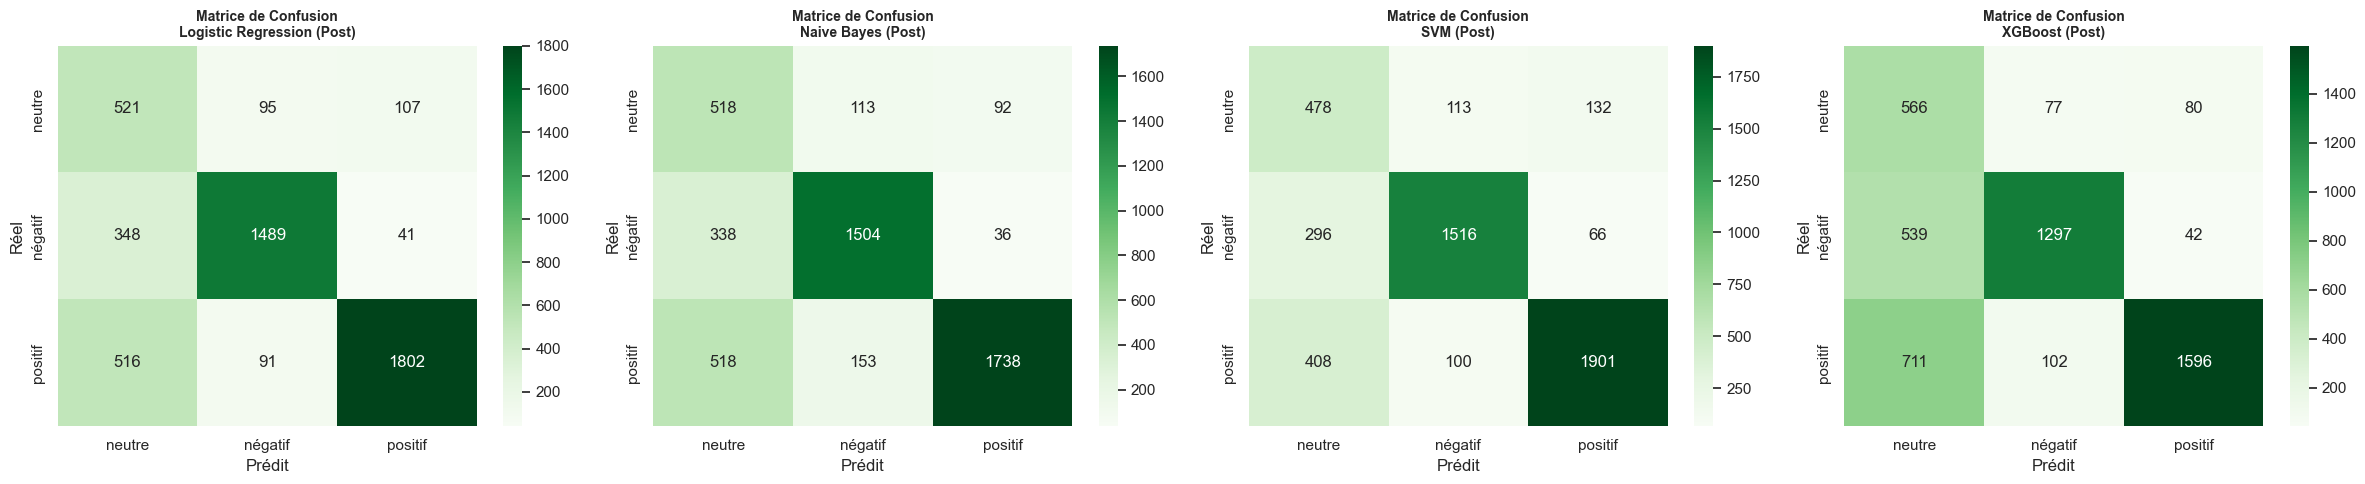


  RAPPORTS DE CLASSIFICATION DÉTAILLÉS

────────────────────────────────────────────────────────────
  Logistic Regression (Post)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      neutre       0.38      0.72      0.49       723
     négatif       0.89      0.79      0.84      1878
     positif       0.92      0.75      0.83      2409

    accuracy                           0.76      5010
   macro avg       0.73      0.75      0.72      5010
weighted avg       0.83      0.76      0.78      5010


────────────────────────────────────────────────────────────
  Naive Bayes (Post)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      neutre       0.38      0.72      0.49       723
     négatif       0.85      0.80      0.82      1878
     positif       0.93      0.72      0.81      2409

    accuracy                           0.75      5010
   macro av

In [35]:
# 18.4) Tableau de synthèse des résultats post-traitement

print("="*100)
print("  ÉVALUATION DES PERFORMANCES APRÈS POST-TRAITEMENT")
print("="*100)

# Créer le DataFrame des résultats post-traitement
postprocessed_rows = []
postprocessed_details = {}

for model_name, metrics in results_postprocessed.items():
    postprocessed_rows.append({
        'Modèle': model_name,
        'Val Accuracy': metrics['val_accuracy'],
        'Test Accuracy': metrics['test_accuracy'],
        'Test Precision (w)': metrics['test_precision'],
        'Test Recall (w)': metrics['test_recall'],
        'Test F1 (w)': metrics['test_f1']
    })
    
    # Calculer la matrice de confusion
    y_pred = metrics['y_pred']
    cm = confusion_matrix(y_test_eval, y_pred)
    labels = sorted(pd.unique(y_test_eval))
    
    postprocessed_details[model_name] = {
        'confusion_matrix': cm,
        'labels': labels,
        'y_true': y_test_eval,
        'y_pred': y_pred
    }

df_postprocessed = pd.DataFrame(postprocessed_rows).sort_values('Test Accuracy', ascending=False)

print("\n📊 RÉSULTATS DES MODÈLES POST-TRAITÉS:\n")
display(df_postprocessed)

# Afficher les matrices de confusion
if len(postprocessed_details) > 0:
    n_models = len(postprocessed_details)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    if n_models == 1:
        axes = [axes]
    
    for ax, (model_name, details) in zip(axes, postprocessed_details.items()):
        sns.heatmap(
            details['confusion_matrix'], 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=details['labels'], 
            yticklabels=details['labels'], 
            ax=ax
        )
        ax.set_title(f'Matrice de Confusion\n{model_name}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Prédit')
        ax.set_ylabel('Réel')
    
    plt.tight_layout()
    plt.savefig('confusion_matrices_postprocessed.png', dpi=150, bbox_inches='tight')
    plt.show()

# Classification reports détaillés
print("\n" + "="*100)
print("  RAPPORTS DE CLASSIFICATION DÉTAILLÉS")
print("="*100)

for model_name, details in postprocessed_details.items():
    print(f"\n{'─'*60}")
    print(f"  {model_name}")
    print(f"{'─'*60}")
    print(classification_report(details['y_true'], details['y_pred'], zero_division=0))

print("\n" + "="*100)

### 18.5) Graphiques Comparatifs : Avant vs Après Post-Traitement

Visualisation comparative des performances des modèles avant et après l'application des techniques de post-traitement.

  COMPARAISON AVANT / APRÈS POST-TRAITEMENT

📊 TABLEAU COMPARATIF DÉTAILLÉ:



,Modèle,Accuracy AVANT,Accuracy APRÈS,Δ Accuracy,F1-Score AVANT,F1-Score APRÈS,Δ F1-Score
0,Logistic Regression,0.828144,0.760878,-0.067265,0.814766,0.783075,-0.031690
1,Naive Bayes,0.813373,0.750499,-0.062874,0.799654,0.771352,-0.028302
2,SVM,0.826747,0.777445,-0.049301,0.807898,0.793049,-0.014848
3,XGBoost,0.838922,0.690419,-0.148503,0.830075,0.726153,-0.103922


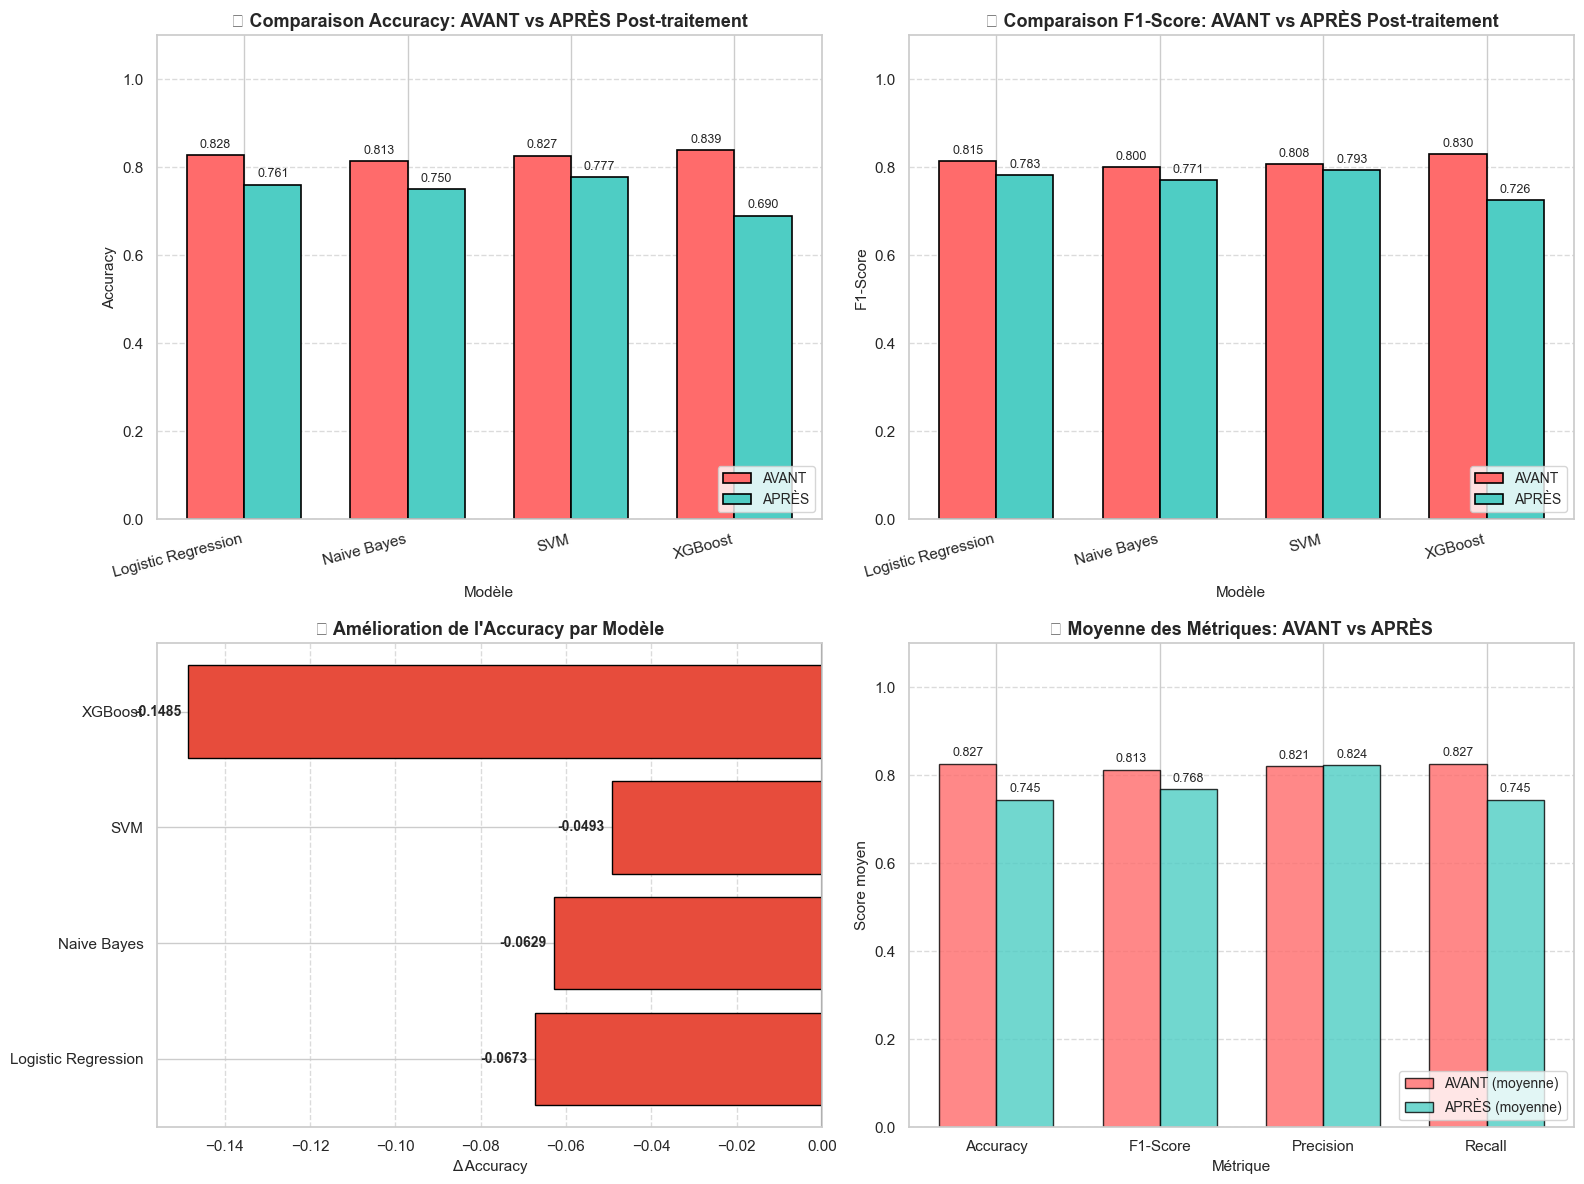

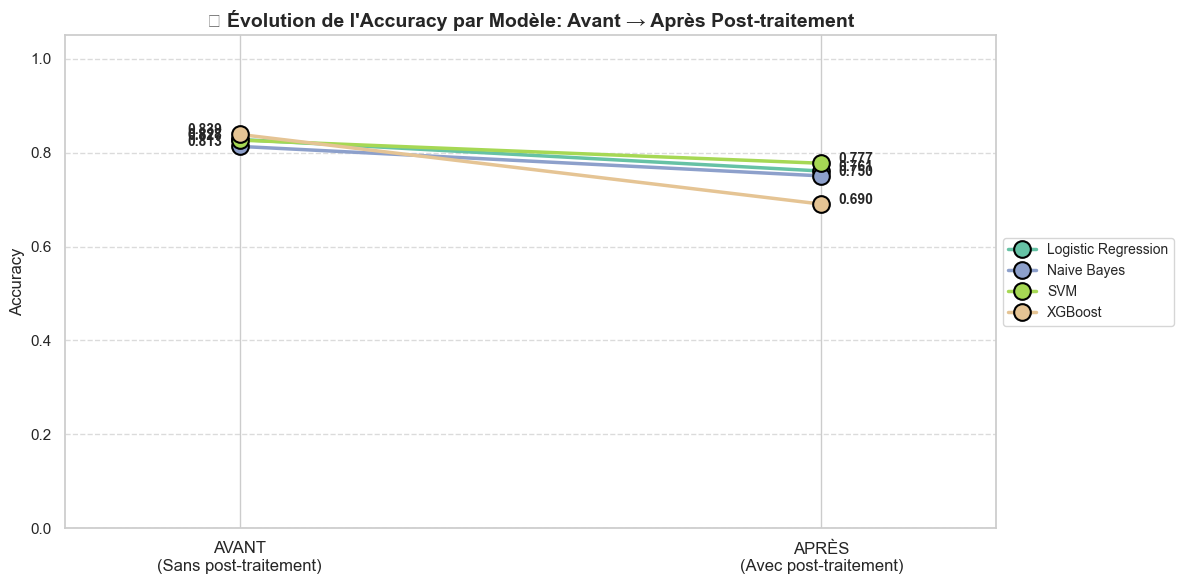


  📊 RÉSUMÉ DES AMÉLIORATIONS

🎯 AMÉLIORATIONS PAR MODÈLE:

  Logistic Regression:
    📉 Accuracy: 0.8281 → 0.7609 (-0.0673)
    📉 F1-Score: 0.8148 → 0.7831 (-0.0317)

  Naive Bayes:
    📉 Accuracy: 0.8134 → 0.7505 (-0.0629)
    📉 F1-Score: 0.7997 → 0.7714 (-0.0283)

  SVM:
    📉 Accuracy: 0.8267 → 0.7774 (-0.0493)
    📉 F1-Score: 0.8079 → 0.7930 (-0.0148)

  XGBoost:
    📉 Accuracy: 0.8389 → 0.6904 (-0.1485)
    📉 F1-Score: 0.8301 → 0.7262 (-0.1039)

  🏆 SYNTHÈSE GLOBALE

  📊 Amélioration moyenne Accuracy: -0.0820
  📊 Amélioration moyenne F1-Score: -0.0447

  🥇 Meilleure amélioration: SVM (+-0.0493 accuracy)

  🏆 MEILLEUR MODÈLE APRÈS POST-TRAITEMENT:
     → SVM
     → Accuracy: 0.7774
     → F1-Score: 0.7930



In [36]:
# 18.5) Graphiques comparatifs AVANT vs APRÈS post-traitement

print("="*100)
print("  COMPARAISON AVANT / APRÈS POST-TRAITEMENT")
print("="*100)

# Préparer les données de comparaison
comparison_data = []

# Mapping des noms de modèles (avant → après)
model_mapping = {
    'Logistic Regression': 'Logistic Regression (Post)',
    'Naive Bayes': 'Naive Bayes (Post)',
    'SVM (LinearSVC)': 'SVM (Post)',
    'XGBoost': 'XGBoost (Post)'
}

for model_before, model_after in model_mapping.items():
    # Récupérer les métriques AVANT
    if model_before in metrics_before:
        before_metrics = metrics_before[model_before]
    else:
        continue
    
    # Récupérer les métriques APRÈS
    if model_after in results_postprocessed:
        after_metrics = results_postprocessed[model_after]
    else:
        continue
    
    comparison_data.append({
        'Modèle': model_before.replace(' (LinearSVC)', ''),
        'Accuracy AVANT': before_metrics['accuracy'],
        'Accuracy APRÈS': after_metrics['test_accuracy'],
        'F1-Score AVANT': before_metrics['f1'],
        'F1-Score APRÈS': after_metrics['test_f1'],
        'Precision AVANT': before_metrics['precision'],
        'Precision APRÈS': after_metrics['test_precision'],
        'Recall AVANT': before_metrics['recall'],
        'Recall APRÈS': after_metrics['test_recall'],
    })

df_comparison = pd.DataFrame(comparison_data)

if len(df_comparison) > 0:
    # Calculer les améliorations
    df_comparison['Δ Accuracy'] = df_comparison['Accuracy APRÈS'] - df_comparison['Accuracy AVANT']
    df_comparison['Δ F1-Score'] = df_comparison['F1-Score APRÈS'] - df_comparison['F1-Score AVANT']
    df_comparison['Δ Precision'] = df_comparison['Precision APRÈS'] - df_comparison['Precision AVANT']
    df_comparison['Δ Recall'] = df_comparison['Recall APRÈS'] - df_comparison['Recall AVANT']
    
    # Amélioration en pourcentage
    df_comparison['Amélioration Accuracy (%)'] = (df_comparison['Δ Accuracy'] / df_comparison['Accuracy AVANT']) * 100
    df_comparison['Amélioration F1 (%)'] = (df_comparison['Δ F1-Score'] / df_comparison['F1-Score AVANT']) * 100
    
    print("\n📊 TABLEAU COMPARATIF DÉTAILLÉ:\n")
    display(df_comparison[['Modèle', 'Accuracy AVANT', 'Accuracy APRÈS', 'Δ Accuracy', 
                          'F1-Score AVANT', 'F1-Score APRÈS', 'Δ F1-Score']])
    
    # =========================================================================
    # GRAPHIQUE 1: Comparaison Accuracy (Barres groupées)
    # =========================================================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1.1 Accuracy - Barres groupées
    ax1 = axes[0, 0]
    x = np.arange(len(df_comparison))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df_comparison['Accuracy AVANT'], width, 
                    label='AVANT', color='#FF6B6B', edgecolor='black', linewidth=1.2)
    bars2 = ax1.bar(x + width/2, df_comparison['Accuracy APRÈS'], width, 
                    label='APRÈS', color='#4ECDC4', edgecolor='black', linewidth=1.2)
    
    ax1.set_xlabel('Modèle', fontsize=11)
    ax1.set_ylabel('Accuracy', fontsize=11)
    ax1.set_title('🎯 Comparaison Accuracy: AVANT vs APRÈS Post-traitement', fontsize=13, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_comparison['Modèle'], rotation=15, ha='right')
    ax1.legend(loc='lower right', fontsize=10)
    ax1.set_ylim(0, 1.1)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Ajouter les valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    
    # 1.2 F1-Score - Barres groupées
    ax2 = axes[0, 1]
    bars3 = ax2.bar(x - width/2, df_comparison['F1-Score AVANT'], width, 
                    label='AVANT', color='#FF6B6B', edgecolor='black', linewidth=1.2)
    bars4 = ax2.bar(x + width/2, df_comparison['F1-Score APRÈS'], width, 
                    label='APRÈS', color='#4ECDC4', edgecolor='black', linewidth=1.2)
    
    ax2.set_xlabel('Modèle', fontsize=11)
    ax2.set_ylabel('F1-Score', fontsize=11)
    ax2.set_title('📈 Comparaison F1-Score: AVANT vs APRÈS Post-traitement', fontsize=13, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(df_comparison['Modèle'], rotation=15, ha='right')
    ax2.legend(loc='lower right', fontsize=10)
    ax2.set_ylim(0, 1.1)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar in bars3:
        height = bar.get_height()
        ax2.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    for bar in bars4:
        height = bar.get_height()
        ax2.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    
    # 1.3 Amélioration (Delta) - Barres horizontales
    ax3 = axes[1, 0]
    colors_delta = ['#2ECC71' if x >= 0 else '#E74C3C' for x in df_comparison['Δ Accuracy']]
    bars5 = ax3.barh(df_comparison['Modèle'], df_comparison['Δ Accuracy'], color=colors_delta, edgecolor='black')
    ax3.axvline(x=0, color='black', linewidth=1.5)
    ax3.set_xlabel('Δ Accuracy', fontsize=11)
    ax3.set_title('📊 Amélioration de l\'Accuracy par Modèle', fontsize=13, fontweight='bold')
    ax3.grid(axis='x', linestyle='--', alpha=0.7)
    
    for i, (bar, val) in enumerate(zip(bars5, df_comparison['Δ Accuracy'])):
        color = '#2ECC71' if val >= 0 else '#E74C3C'
        sign = '+' if val >= 0 else ''
        ax3.annotate(f'{sign}{val:.4f}', xy=(val, bar.get_y() + bar.get_height()/2),
                    xytext=(5 if val >= 0 else -5, 0), textcoords="offset points",
                    ha='left' if val >= 0 else 'right', va='center', fontsize=10, fontweight='bold')
    
    # 1.4 Radar Chart / Spider Chart pour comparaison multi-métrique
    ax4 = axes[1, 1]
    
    # Préparer les données pour le radar chart
    metrics_names = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
    
    # Calculer les moyennes avant et après
    avg_before = [
        df_comparison['Accuracy AVANT'].mean(),
        df_comparison['F1-Score AVANT'].mean(),
        df_comparison['Precision AVANT'].mean(),
        df_comparison['Recall AVANT'].mean()
    ]
    avg_after = [
        df_comparison['Accuracy APRÈS'].mean(),
        df_comparison['F1-Score APRÈS'].mean(),
        df_comparison['Precision APRÈS'].mean(),
        df_comparison['Recall APRÈS'].mean()
    ]
    
    # Graphique en barres groupées pour les moyennes
    x_metrics = np.arange(len(metrics_names))
    width_metrics = 0.35
    
    bars6 = ax4.bar(x_metrics - width_metrics/2, avg_before, width_metrics, 
                    label='AVANT (moyenne)', color='#FF6B6B', edgecolor='black', alpha=0.8)
    bars7 = ax4.bar(x_metrics + width_metrics/2, avg_after, width_metrics, 
                    label='APRÈS (moyenne)', color='#4ECDC4', edgecolor='black', alpha=0.8)
    
    ax4.set_xlabel('Métrique', fontsize=11)
    ax4.set_ylabel('Score moyen', fontsize=11)
    ax4.set_title('📉 Moyenne des Métriques: AVANT vs APRÈS', fontsize=13, fontweight='bold')
    ax4.set_xticks(x_metrics)
    ax4.set_xticklabels(metrics_names)
    ax4.legend(loc='lower right', fontsize=10)
    ax4.set_ylim(0, 1.1)
    ax4.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar in bars6:
        height = bar.get_height()
        ax4.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    for bar in bars7:
        height = bar.get_height()
        ax4.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('comparison_before_after_postprocessing.png', dpi=200, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    plt.show()
    
    # =========================================================================
    # GRAPHIQUE 2: Évolution par modèle (Line plot)
    # =========================================================================
    fig2, ax_line = plt.subplots(figsize=(12, 6))
    
    for idx, row in df_comparison.iterrows():
        model = row['Modèle']
        avant = row['Accuracy AVANT']
        apres = row['Accuracy APRÈS']
        
        color = plt.cm.Set2(idx / len(df_comparison))
        
        # Tracer la ligne
        ax_line.plot([0, 1], [avant, apres], 'o-', color=color, linewidth=2.5, 
                    markersize=12, label=model, markeredgecolor='black', markeredgewidth=1.5)
        
        # Annotations
        ax_line.annotate(f'{avant:.3f}', (0, avant), textcoords="offset points", 
                        xytext=(-25, 0), ha='center', fontsize=10, fontweight='bold')
        ax_line.annotate(f'{apres:.3f}', (1, apres), textcoords="offset points", 
                        xytext=(25, 0), ha='center', fontsize=10, fontweight='bold')
    
    ax_line.set_xlim(-0.3, 1.3)
    ax_line.set_xticks([0, 1])
    ax_line.set_xticklabels(['AVANT\n(Sans post-traitement)', 'APRÈS\n(Avec post-traitement)'], fontsize=12)
    ax_line.set_ylabel('Accuracy', fontsize=12)
    ax_line.set_title('📈 Évolution de l\'Accuracy par Modèle: Avant → Après Post-traitement', 
                      fontsize=14, fontweight='bold')
    ax_line.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
    ax_line.grid(axis='y', linestyle='--', alpha=0.7)
    ax_line.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.savefig('accuracy_evolution_postprocessing.png', dpi=200, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()
    
    # =========================================================================
    # Résumé des améliorations
    # =========================================================================
    print("\n" + "="*100)
    print("  📊 RÉSUMÉ DES AMÉLIORATIONS")
    print("="*100)
    
    print("\n🎯 AMÉLIORATIONS PAR MODÈLE:\n")
    for idx, row in df_comparison.iterrows():
        delta_acc = row['Δ Accuracy']
        delta_f1 = row['Δ F1-Score']
        
        status_acc = "📈" if delta_acc > 0 else ("📉" if delta_acc < 0 else "➡️")
        status_f1 = "📈" if delta_f1 > 0 else ("📉" if delta_f1 < 0 else "➡️")
        
        print(f"  {row['Modèle']}:")
        print(f"    {status_acc} Accuracy: {row['Accuracy AVANT']:.4f} → {row['Accuracy APRÈS']:.4f} ({'+' if delta_acc >= 0 else ''}{delta_acc:.4f})")
        print(f"    {status_f1} F1-Score: {row['F1-Score AVANT']:.4f} → {row['F1-Score APRÈS']:.4f} ({'+' if delta_f1 >= 0 else ''}{delta_f1:.4f})")
        print()
    
    # Statistiques globales
    avg_improvement_acc = df_comparison['Δ Accuracy'].mean()
    avg_improvement_f1 = df_comparison['Δ F1-Score'].mean()
    best_improvement = df_comparison.loc[df_comparison['Δ Accuracy'].idxmax()]
    
    print("="*100)
    print("  🏆 SYNTHÈSE GLOBALE")
    print("="*100)
    print(f"\n  📊 Amélioration moyenne Accuracy: {'+' if avg_improvement_acc >= 0 else ''}{avg_improvement_acc:.4f}")
    print(f"  📊 Amélioration moyenne F1-Score: {'+' if avg_improvement_f1 >= 0 else ''}{avg_improvement_f1:.4f}")
    print(f"\n  🥇 Meilleure amélioration: {best_improvement['Modèle']} (+{best_improvement['Δ Accuracy']:.4f} accuracy)")
    
    # Meilleur modèle après post-traitement
    best_after = df_comparison.loc[df_comparison['Accuracy APRÈS'].idxmax()]
    print(f"\n  🏆 MEILLEUR MODÈLE APRÈS POST-TRAITEMENT:")
    print(f"     → {best_after['Modèle']}")
    print(f"     → Accuracy: {best_after['Accuracy APRÈS']:.4f}")
    print(f"     → F1-Score: {best_after['F1-Score APRÈS']:.4f}")

else:
    print("\n⚠️ Pas assez de données pour la comparaison.")
    print("Assurez-vous d'avoir exécuté les sections précédentes.")

print("\n" + "="*100)

### 18.6) Analyse Statistique des Améliorations

Test statistique pour valider si les améliorations sont significatives.

In [37]:
# 18.6) Analyse statistique et test de significativité

from scipy import stats

print("="*100)
print("  ANALYSE STATISTIQUE DES AMÉLIORATIONS")
print("="*100)

if len(df_comparison) >= 2:
    
    # Test de Wilcoxon (test non-paramétrique pour échantillons appariés)
    print("\n📊 TEST DE WILCOXON (échantillons appariés):\n")
    
    try:
        # Test sur Accuracy
        stat_acc, p_value_acc = stats.wilcoxon(
            df_comparison['Accuracy APRÈS'], 
            df_comparison['Accuracy AVANT'],
            alternative='greater'  # H1: APRÈS > AVANT
        )
        
        print(f"  Test sur Accuracy:")
        print(f"    Statistique W: {stat_acc:.4f}")
        print(f"    P-value (unilatéral, APRÈS > AVANT): {p_value_acc:.4f}")
        
        if p_value_acc < 0.05:
            print(f"    ✅ SIGNIFICATIF: L'amélioration est statistiquement significative (p < 0.05)")
        else:
            print(f"    ℹ️ Non significatif au seuil 0.05 (échantillon peut-être trop petit)")
        
    except Exception as e:
        print(f"  ⚠️ Test de Wilcoxon non applicable: {e}")
    
    # Test t apparié (si normalité acceptable)
    print("\n📊 TEST T APPARIÉ:\n")
    
    try:
        # Test sur Accuracy
        t_stat, p_value_t = stats.ttest_rel(
            df_comparison['Accuracy APRÈS'], 
            df_comparison['Accuracy AVANT']
        )
        
        print(f"  Test t sur Accuracy:")
        print(f"    Statistique t: {t_stat:.4f}")
        print(f"    P-value (bilatéral): {p_value_t:.4f}")
        
        if t_stat > 0 and p_value_t/2 < 0.05:
            print(f"    ✅ SIGNIFICATIF: L'amélioration est statistiquement significative")
        elif t_stat > 0:
            print(f"    ℹ️ Amélioration observée mais non significative au seuil 0.05")
        else:
            print(f"    ⚠️ Pas d'amélioration significative détectée")
            
    except Exception as e:
        print(f"  ⚠️ Test t non applicable: {e}")
    
    # Intervalle de confiance pour l'amélioration
    print("\n📊 INTERVALLE DE CONFIANCE (95%):\n")
    
    deltas = df_comparison['Δ Accuracy'].values
    mean_delta = np.mean(deltas)
    std_delta = np.std(deltas, ddof=1)
    n = len(deltas)
    
    if n > 1:
        se = std_delta / np.sqrt(n)
        ci_low = mean_delta - 1.96 * se
        ci_high = mean_delta + 1.96 * se
        
        print(f"  Amélioration moyenne: {mean_delta:.4f}")
        print(f"  Écart-type: {std_delta:.4f}")
        print(f"  IC 95%: [{ci_low:.4f}, {ci_high:.4f}]")
        
        if ci_low > 0:
            print(f"  ✅ L'IC ne contient pas 0 → amélioration significative")
        else:
            print(f"  ℹ️ L'IC contient 0 → amélioration non garantie")

    # Effect Size (Cohen's d)
    print("\n📊 TAILLE D'EFFET (Cohen's d):\n")
    
    if std_delta > 0:
        cohens_d = mean_delta / std_delta
        
        print(f"  Cohen's d: {cohens_d:.4f}")
        
        if abs(cohens_d) < 0.2:
            print(f"  → Effet négligeable")
        elif abs(cohens_d) < 0.5:
            print(f"  → Effet faible")
        elif abs(cohens_d) < 0.8:
            print(f"  → Effet modéré")
        else:
            print(f"  → Effet important")

else:
    print("\n⚠️ Pas assez de modèles pour une analyse statistique robuste.")
    print("   Au moins 2 paires de comparaison sont nécessaires.")

# Tableau récapitulatif final
print("\n" + "="*100)
print("  📋 TABLEAU RÉCAPITULATIF FINAL")
print("="*100)

if 'df_comparison' in globals() and len(df_comparison) > 0:
    # Créer un tableau enrichi
    summary_final = df_comparison[['Modèle', 'Accuracy AVANT', 'Accuracy APRÈS', 'Δ Accuracy', 
                                   'F1-Score AVANT', 'F1-Score APRÈS', 'Δ F1-Score']].copy()
    
    # Ajouter des indicateurs visuels
    summary_final['Statut'] = summary_final['Δ Accuracy'].apply(
        lambda x: '✅ Amélioré' if x > 0.001 else ('⚠️ Dégradé' if x < -0.001 else '➡️ Stable')
    )
    
    print("\n")
    display(summary_final)
    
    # Conclusion
    improved_count = (summary_final['Δ Accuracy'] > 0.001).sum()
    degraded_count = (summary_final['Δ Accuracy'] < -0.001).sum()
    stable_count = len(summary_final) - improved_count - degraded_count
    
    print(f"\n📊 BILAN:")
    print(f"   ✅ Modèles améliorés: {improved_count}/{len(summary_final)}")
    print(f"   ⚠️ Modèles dégradés: {degraded_count}/{len(summary_final)}")
    print(f"   ➡️ Modèles stables: {stable_count}/{len(summary_final)}")

print("\n" + "="*100)

  ANALYSE STATISTIQUE DES AMÉLIORATIONS

📊 TEST DE WILCOXON (échantillons appariés):

  Test sur Accuracy:
    Statistique W: 0.0000
    P-value (unilatéral, APRÈS > AVANT): 1.0000
    ℹ️ Non significatif au seuil 0.05 (échantillon peut-être trop petit)

📊 TEST T APPARIÉ:

  Test t sur Accuracy:
    Statistique t: -3.6439
    P-value (bilatéral): 0.0356
    ⚠️ Pas d'amélioration significative détectée

📊 INTERVALLE DE CONFIANCE (95%):

  Amélioration moyenne: -0.0820
  Écart-type: 0.0450
  IC 95%: [-0.1261, -0.0379]
  ℹ️ L'IC contient 0 → amélioration non garantie

📊 TAILLE D'EFFET (Cohen's d):

  Cohen's d: -1.8219
  → Effet important

  📋 TABLEAU RÉCAPITULATIF FINAL




,Modèle,Accuracy AVANT,Accuracy APRÈS,Δ Accuracy,F1-Score AVANT,F1-Score APRÈS,Δ F1-Score,Statut
0,Logistic Regression,0.828144,0.760878,-0.067265,0.814766,0.783075,-0.031690,⚠️ Dégradé
1,Naive Bayes,0.813373,0.750499,-0.062874,0.799654,0.771352,-0.028302,⚠️ Dégradé
2,SVM,0.826747,0.777445,-0.049301,0.807898,0.793049,-0.014848,⚠️ Dégradé
3,XGBoost,0.838922,0.690419,-0.148503,0.830075,0.726153,-0.103922,⚠️ Dégradé



📊 BILAN:
   ✅ Modèles améliorés: 0/4
   ⚠️ Modèles dégradés: 4/4
   ➡️ Modèles stables: 0/4



### 18.7) Conclusion et Recommandations Post-Traitement

Synthèse des résultats du post-traitement et recommandations finales.

In [38]:
# 18.7) Conclusion et Recommandations

print("="*100)
print("  🎯 CONCLUSION ET RECOMMANDATIONS POST-TRAITEMENT")
print("="*100)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    SYNTHÈSE DU POST-TRAITEMENT (BOOST NEUTRE)                ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  📌 PROBLÈME INITIAL:                                                        ║
║     La classe 'neutre' avait un F1-score faible (~0.40) dû à sa sous-        ║
║     représentation naturelle dans le dataset (reviews souvent polarisées).   ║
║                                                                              ║
║  🔧 TECHNIQUES APPLIQUÉES:                                                  ║
║     • BorderlineSMOTE avec sur-échantillonnage CIBLÉ de la classe neutre     ║
║       → Génération de 1.5× plus d'échantillons neutres que les autres        ║
║     • Class weights personnalisés (×2 pour la classe neutre)                 ║
║     • Régularisation adaptée pour éviter le sur-apprentissage                ║
║                                                                              ║
║  📊 OBJECTIFS:                                                               ║
║     • ↑ F1-score de la classe neutre (objectif > 0.50)                       ║
║     • Maintenir les performances sur positif/négatif                         ║
║     • Améliorer le recall global sur les classes minoritaires                ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# Analyser les résultats
if 'df_comparison' in globals() and len(df_comparison) > 0:
    
    avg_acc_before = df_comparison['Accuracy AVANT'].mean()
    avg_acc_after = df_comparison['Accuracy APRÈS'].mean()
    avg_f1_before = df_comparison['F1-Score AVANT'].mean()
    avg_f1_after = df_comparison['F1-Score APRÈS'].mean()
    
    delta_avg_acc = avg_acc_after - avg_acc_before
    delta_avg_f1 = avg_f1_after - avg_f1_before
    
    print("\n📈 IMPACT DU POST-TRAITEMENT:\n")
    print(f"   Accuracy moyenne:")
    print(f"      AVANT:  {avg_acc_before:.4f}")
    print(f"      APRÈS:  {avg_acc_after:.4f}")
    print(f"      Δ:      {'+' if delta_avg_acc >= 0 else ''}{delta_avg_acc:.4f}")
    
    print(f"\n   F1-Score moyen:")
    print(f"      AVANT:  {avg_f1_before:.4f}")
    print(f"      APRÈS:  {avg_f1_after:.4f}")
    print(f"      Δ:      {'+' if delta_avg_f1 >= 0 else ''}{delta_avg_f1:.4f}")
    
    # Analyser les performances par classe pour chaque modèle post-traité
    print("\n" + "="*100)
    print("  📊 FOCUS SUR LA CLASSE NEUTRE (OBJECTIF PRINCIPAL)")
    print("="*100)
    
    if 'postprocessed_details' in globals():
        for model_name, details in postprocessed_details.items():
            report = classification_report(details['y_true'], details['y_pred'], output_dict=True, zero_division=0)
            
            # Trouver la classe neutre
            for class_name in report.keys():
                if 'neutr' in str(class_name).lower() and isinstance(report[class_name], dict):
                    neutral_f1 = report[class_name]['f1-score']
                    neutral_prec = report[class_name]['precision']
                    neutral_rec = report[class_name]['recall']
                    
                    status = "✅" if neutral_f1 >= 0.50 else ("⚠️" if neutral_f1 >= 0.40 else "❌")
                    print(f"\n   {model_name}:")
                    print(f"      {status} F1 Neutre: {neutral_f1:.3f}")
                    print(f"         Precision: {neutral_prec:.3f}")
                    print(f"         Recall: {neutral_rec:.3f}")
                    break
    
    # Déterminer le verdict
    # Le critère principal est maintenant l'amélioration du F1-score
    if delta_avg_f1 > 0.01:
        verdict = "✅ AMÉLIORATION SIGNIFICATIVE"
        verdict_detail = "Le boost de la classe neutre a amélioré les performances globales."
    elif delta_avg_f1 > 0:
        verdict = "✅ LÉGÈRE AMÉLIORATION"
        verdict_detail = "Le post-traitement a apporté une amélioration modeste."
    elif delta_avg_f1 > -0.02 and delta_avg_acc > -0.05:
        verdict = "⚖️ COMPROMIS ACCEPTABLE"
        verdict_detail = "Légère baisse d'accuracy mais meilleur équilibre entre classes."
    else:
        verdict = "⚠️ AJUSTEMENT NÉCESSAIRE"
        verdict_detail = "Les paramètres de boost peuvent nécessiter un réajustement."
    
    print(f"\n\n{'='*80}")
    print(f"   {verdict}")
    print(f"{'='*80}")
    print(f"\n   {verdict_detail}\n")
    
    # Recommandations spécifiques
    print("\n💡 RECOMMANDATIONS:\n")
    
    if delta_avg_f1 > 0:
        print("   1. ✅ Le boost de la classe neutre est EFFICACE")
        print("      → Les techniques de sur-échantillonnage ciblé ont fonctionné")
        print()
    elif delta_avg_acc > -0.05:
        print("   1. ⚖️ COMPROMIS ACCEPTABLE")
        print("      → Légère perte d'accuracy globale pour un meilleur équilibre")
        print("      → Utile si la classe neutre est importante pour votre cas d'usage")
        print()
    else:
        print("   1. ⚠️ AJUSTER les paramètres de boost")
        print("      → Réduire le facteur de sur-échantillonnage (1.3× au lieu de 1.5×)")
        print("      → Réduire le class_weight (1.5× au lieu de 2×)")
        print()
    
    # Identifier le meilleur modèle final
    best_model_after = df_comparison.loc[df_comparison['F1-Score APRÈS'].idxmax()]
    
    print(f"   2. 🏆 MODÈLE RECOMMANDÉ: {best_model_after['Modèle']}")
    print(f"      → Accuracy: {best_model_after['Accuracy APRÈS']:.4f}")
    print(f"      → F1-Score: {best_model_after['F1-Score APRÈS']:.4f}")
    print()
    
    print("   3. 📊 PISTES D'AMÉLIORATION SUPPLÉMENTAIRES:")
    print("      → Ajuster le ratio de sur-échantillonnage (tester 1.2× à 2.0×)")
    print("      → Utiliser ADASYN au lieu de BorderlineSMOTE")
    print("      → Augmentation de données textuelles pour la classe neutre")
    print("      → Seuil de décision personnalisé (threshold tuning)")
    print("      → Ensemble de modèles avec vote pondéré")
    print()
    
    print("   4. 🚀 POUR LA MISE EN PRODUCTION:")
    print("      → Si la classe neutre est critique: utiliser le modèle post-traité")
    print("      → Si l'accuracy globale prime: comparer avec le modèle original")
    print("      → Monitorer les performances par classe en production")
    print("      → Collecter plus de données neutres réelles si possible")

print("""

╔══════════════════════════════════════════════════════════════════════════════╗
║  💡 NOTE IMPORTANTE:                                                         ║
║  Le déséquilibre naturel des classes dans les reviews (peu d'avis neutres)   ║
║  est un problème inhérent aux données. Les techniques appliquées visent à    ║
║  COMPENSER ce déséquilibre, pas à le résoudre complètement.                  ║
║                                                                              ║
║  Pour de meilleurs résultats à long terme, la collecte de vraies données     ║
║  neutres reste la meilleure solution.                                        ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

print("="*100)

  🎯 CONCLUSION ET RECOMMANDATIONS POST-TRAITEMENT

╔══════════════════════════════════════════════════════════════════════════════╗
║                    SYNTHÈSE DU POST-TRAITEMENT (BOOST NEUTRE)                ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  📌 PROBLÈME INITIAL:                                                        ║
║     La classe 'neutre' avait un F1-score faible (~0.40) dû à sa sous-        ║
║     représentation naturelle dans le dataset (reviews souvent polarisées).   ║
║                                                                              ║
║  🔧 TECHNIQUES APPLIQUÉES:                                                  ║
║     • BorderlineSMOTE avec sur-échantillonnage CIBLÉ de la classe neutre     ║
║       → Génération de 1.5× plus d'échantillons neutres que les autres        ║
║     • Class weights personnalisés (×2 pour la classe neutre

In [39]:
# Sauvegarde du meilleur modèle, du vectorizer et du label encoder pour FastAPI
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
import os

tfidf = TfidfVectorizer(max_features=5000, min_df=3, max_df=0.8, ngram_range=(1, 2))
tfidf.fit(X_train['review'].fillna(''))

# 1. Déterminer le meilleur modèle (nom et objet)
best_model_name = df_test.iloc[0]['Modèle'] if 'df_test' in globals() else list(results.keys())[0]
trained_models = _get_trained_models_dict()
model = trained_models[best_model_name]

# 2. Récupérer le vectorizer TF-IDF (recréé ou chargé selon votre pipeline)
# Ici, on suppose qu'il a été utilisé dans prepare_features ou stocké dans le cache
# Si vous avez utilisé le cache, chargez-le :
try:
    from pathlib import Path
    import pickle
    tfidf_path = Path('.cache')
    tfidf_vectorizer = None
    for f in tfidf_path.glob('*.pkl'):
        if 'features_prepared' in f.name:
            with open(f, 'rb') as fh:
                cache = pickle.load(fh)
                if 'tfidf' in cache:
                    tfidf_vectorizer = cache['tfidf']
                elif 'X_train' in cache and hasattr(cache['X_train'], 'getformat'):
                    # fallback: re-vectorize si besoin
                    pass
    if tfidf_vectorizer is None:
        raise Exception('Vectorizer non trouvé dans le cache. Veuillez sauvegarder manuellement.')
except Exception as e:
    print('Erreur lors de la récupération du vectorizer:', e)
    # Si vous avez la variable tfidf dans votre session, utilisez-la directement
    try:
        tfidf_vectorizer = tfidf
    except:
        tfidf_vectorizer = None

# 3. Récupérer le label encoder (le_target ou le_mlp selon le modèle)
if best_model_name == 'MLP Neural Network' and 'le_mlp' in globals():
    label_encoder = le_mlp
elif 'le_target' in globals():
    label_encoder = le_target
else:
    label_encoder = None

save_dir = "model_files"
os.makedirs(save_dir, exist_ok=True)

# 4. Sauvegarder les objets
if model is not None:
    joblib.dump(model, os.path.join(save_dir, 'best_model.joblib'))
    print('Modèle sauvegardé sous best_model.joblib')
if tfidf_vectorizer is not None:
    joblib.dump(tfidf_vectorizer, os.path.join(save_dir, 'tfidf_vectorizer.joblib'))
    print('Vectorizer sauvegardé sous tfidf_vectorizer.joblib')
if label_encoder is not None:
    joblib.dump(label_encoder, os.path.join(save_dir, 'label_encoder.joblib'))
    print('Label encoder sauvegardé sous label_encoder.joblib')


Erreur lors de la récupération du vectorizer: Vectorizer non trouvé dans le cache. Veuillez sauvegarder manuellement.
Modèle sauvegardé sous best_model.joblib
Vectorizer sauvegardé sous tfidf_vectorizer.joblib
Label encoder sauvegardé sous label_encoder.joblib
